In [1]:
#!/usr/bin/env python3
"""
RSA Lag Analysis — Retrieval IRASA vectors, HC channels (LHP + RHP)
--------------------------------------------------------------------
Input  : ALL_SUBJECTS_{exp}_irasa_channel_wide.csv
         (output of the channel-level IRASA pipeline)

For every trial, for every pair of clean recalls (i, j) with i < j:
  - Build retrieval vector for each output position:
      ret_osc_f00..f17  ×  all LHP+RHP channels
      vector length = 18 freqs × N_HC_channels (varies per subject/session)
  - RSA_r       : Pearson r between vector_i and vector_j
  - output_lag  : j - i  (signed output-position lag)
  - T_lag       : |serial_pos_i - serial_pos_j|  (temporal lag in presentation order)
  - SP_lag      : Euclidean distance between store locations of word_i and word_j

Output columns:
  subject, session, experiment, trial,
  output_pos_i, output_pos_j, output_lag,
  word_i, word_j,
  serial_pos_i, serial_pos_j, T_lag, SP_lag,
  RSA_r, n_channels

One master CSV per experiment:
  ./rsa_lag_results/ALL_SUBJECTS_{exp}_rsa_lag.csv

Bug fixes vs. original:
  1. SP_lag: guard against NaN store coordinates (returns NaN explicitly).
  2. n_channels: report min of i and j (conservative); warn if they differ.
  3. [CRITICAL] build_retrieval_vector: reindex both vectors against the shared
     channel set so dimensions always align before correlation.
  4. output_positions sort: explicit numeric key to avoid lexicographic mis-sort.
  5. Metadata extraction: assert uniqueness of word/serial_pos/store per
     (trial, output_position) to catch upstream duplicates early.
  6. INPUT_DIRS: configurable at top, with existence check and clear error.
"""

import warnings
import traceback
from pathlib import Path
from typing import List, Dict, Optional

import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from scipy.spatial.distance import euclidean

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENTS = ['DBOY1', 'EFRCourierReadOnly', 'EFRCourierOpenLoop']

# FIX #6: Make input path explicit and easy to verify.
# Change these paths to match where your upstream pipeline writes master CSVs.
INPUT_DIRS = {
    'DBOY1':               Path('./subject_results_HP_LTC_DBOY1'),
    'EFRCourierReadOnly':  Path('./subject_results_HP_LTC_EFRCourierReadOnly'),
    'EFRCourierOpenLoop':  Path('./subject_results_HP_LTC_EFRCourierOpenLoop'),
}

OUTPUT_DIR = Path('./rsa_lag_results')
OUTPUT_DIR.mkdir(exist_ok=True)

N_FREQS    = 18
HC_REGIONS = {'RHP'}

RET_OSC_COLS = [f'ret_osc_f{i:02d}' for i in range(N_FREQS)]

OUTPUT_COLS = [
    'subject', 'session', 'experiment', 'trial',
    'output_pos_i', 'output_pos_j', 'output_lag',
    'word_i', 'word_j',
    'serial_pos_i', 'serial_pos_j', 'T_lag', 'SP_lag',
    'RSA_r', 'n_channels',
]

# ============================================================================
# HELPERS
# ============================================================================

def build_retrieval_vector(
    recall_rows: pd.DataFrame,
    channel_index: pd.Index,
) -> np.ndarray:
    """
    Build a retrieval vector aligned to a fixed channel_index.

    FIX #3 (CRITICAL): Both output positions in a pair must use the SAME
    channel ordering. We reindex recall_rows against the trial-level
    channel_index, filling any missing channels with NaN.  This guarantees
    that position i and position j always produce vectors of identical length
    and that dimension k in both vectors refers to the same (channel, freq).

    Parameters
    ----------
    recall_rows   : rows for one output position (already filtered to LHP+RHP)
    channel_index : sorted array of ALL channel_idx values seen in this trial

    Returns
    -------
    1-D array of length len(channel_index) × N_FREQS
    Order: [ch0_f0..f17, ch1_f0..f17, ...]
    Missing channels → NaN rows (handled pairwise in safe_pearsonr).
    """
    # One row per channel; if duplicates exist keep first (guarded upstream)
    ch_df = (
        recall_rows
        .drop_duplicates(subset='channel_idx')
        .set_index('channel_idx')
        .reindex(channel_index)          # aligns to trial-level channel set
    )
    mat = ch_df[RET_OSC_COLS].values     # (N_ch_trial, 18) — NaN where missing
    return mat.flatten()                 # (N_ch_trial × 18,)


def safe_pearsonr(v1: np.ndarray, v2: np.ndarray) -> float:
    """
    Pearson r ignoring NaN positions (pairwise drop).
    Returns NaN if vectors differ in length or fewer than 3 valid pairs.
    """
    # Extra safety: identical length required (guaranteed by build_retrieval_vector fix)
    if len(v1) != len(v2):
        warnings.warn(
            f"Vector length mismatch: {len(v1)} vs {len(v2)}. Returning NaN."
        )
        return np.nan

    mask = np.isfinite(v1) & np.isfinite(v2)
    if mask.sum() < 3:
        return np.nan
    r, _ = pearsonr(v1[mask], v2[mask])
    return float(r)


def safe_euclidean(
    x1: float, z1: float,
    x2: float, z2: float,
) -> float:
    """
    FIX #1: Return NaN explicitly if any store coordinate is missing,
    rather than letting euclidean() propagate NaN silently.
    """
    if any(not np.isfinite(v) for v in (x1, z1, x2, z2)):
        return np.nan
    return float(euclidean([x1, z1], [x2, z2]))


def extract_scalar(series: pd.Series, field: str, context: str) -> object:
    """
    FIX #5: Extract a scalar that should be unique per (trial, output_position).
    Warns (rather than raises) if multiple distinct values are found, and
    returns the first value so processing continues.
    """
    unique_vals = series.dropna().unique()
    if len(unique_vals) > 1:
        warnings.warn(
            f"[{context}] Field '{field}' has {len(unique_vals)} distinct values "
            f"({unique_vals[:3]}…). Taking first."
        )
    return series.iloc[0]


# ============================================================================
# TRIAL-LEVEL PROCESSING
# ============================================================================

def process_trial(trial_df: pd.DataFrame) -> List[Dict]:
    """
    trial_df : all rows for one (subject, session, trial), HC channels only.
    Returns  : list of row dicts, one per (i, j) pair.
    """
    rows = []

    # FIX #4: Sort output positions numerically, not lexicographically.
    output_positions = sorted(
        trial_df['recall_output_position'].unique(),
        key=lambda x: int(x),
    )
    n_recalls = len(output_positions)

    if n_recalls < 2:
        return rows

    # FIX #3: Compute the trial-level channel index ONCE.
    # All vectors will be aligned to this fixed index.
    channel_index = sorted(trial_df['channel_idx'].unique(), key=int)

    # Build a dict: output_pos → {vector, word, serial_pos, store_x, store_z, n_ch}
    pos_data: Dict[int, Dict] = {}
    sample_row = trial_df.iloc[0]

    for op in output_positions:
        op_rows = trial_df[trial_df['recall_output_position'] == op]
        ctx     = (f"subj={sample_row['subject']} sess={sample_row['session']} "
                   f"trial={sample_row['trial']} op={op}")

        # FIX #5: Use guarded scalar extraction instead of bare .iloc[0]
        word       = extract_scalar(op_rows['recalled_word'],    'recalled_word',    ctx)
        serial_pos = extract_scalar(op_rows['serial_position'],  'serial_position',  ctx)
        store_x    = extract_scalar(op_rows['store_x'],          'store_x',          ctx)
        store_z    = extract_scalar(op_rows['store_z'],          'store_z',          ctx)

        vec  = build_retrieval_vector(op_rows, channel_index)   # FIX #3
        n_ch = op_rows['channel_idx'].nunique()

        pos_data[op] = {
            'vector':     vec,
            'word':       word,
            'serial_pos': serial_pos,
            'store_x':    store_x,
            'store_z':    store_z,
            'n_channels': n_ch,
        }

    subject    = sample_row['subject']
    session    = sample_row['session']
    experiment = sample_row['experiment']
    trial      = sample_row['trial']

    # All ordered pairs (i, j) with i < j in output order
    for idx_i, op_i in enumerate(output_positions):
        for op_j in output_positions[idx_i + 1:]:
            d_i = pos_data[op_i]
            d_j = pos_data[op_j]

            output_lag = int(op_j) - int(op_i)

            T_lag = abs(int(d_i['serial_pos']) - int(d_j['serial_pos']))

            # FIX #1: Use guarded euclidean
            SP_lag = safe_euclidean(
                d_i['store_x'], d_i['store_z'],
                d_j['store_x'], d_j['store_z'],
            )

            rsa_r = safe_pearsonr(d_i['vector'], d_j['vector'])

            # FIX #2: Report the minimum (conservative) n_channels across the pair
            n_channels = min(d_i['n_channels'], d_j['n_channels'])
            if d_i['n_channels'] != d_j['n_channels']:
                warnings.warn(
                    f"Channel count differs across output positions in "
                    f"[{subject} sess={session} trial={trial}]: "
                    f"op{op_i}={d_i['n_channels']} vs op{op_j}={d_j['n_channels']}. "
                    f"Reporting min={n_channels}."
                )

            rows.append({
                'subject':        subject,
                'session':        session,
                'experiment':     experiment,
                'trial':          trial,
                'output_pos_i':   op_i,
                'output_pos_j':   op_j,
                'output_lag':     output_lag,
                'word_i':         d_i['word'],
                'word_j':         d_j['word'],
                'serial_pos_i':   d_i['serial_pos'],
                'serial_pos_j':   d_j['serial_pos'],
                'T_lag':          T_lag,
                'SP_lag':         SP_lag,
                'RSA_r':          rsa_r,
                'n_channels':     n_channels,
            })

    return rows


# ============================================================================
# MAIN
# ============================================================================

def run_experiment(exp: str):
    print(f"\n{'='*70}")
    print(f"EXPERIMENT: {exp}")
    print(f"{'='*70}")

    # FIX #6: Explicit path with informative error message
    input_dir  = INPUT_DIRS.get(exp)
    if input_dir is None:
        print(f"  ✗ No INPUT_DIR configured for experiment '{exp}'. "
              f"Add it to INPUT_DIRS at the top of the script.")
        return

    input_path = input_dir / f"ALL_SUBJECTS_{exp}_irasa_channel_wide.csv"

    if not input_path.exists():
        print(f"  ✗ Master CSV not found: {input_path}")
        print(f"    Check that INPUT_DIRS['{exp}'] = {input_dir} is correct.")
        return

    print(f"  Loading {input_path} …")
    df = pd.read_csv(input_path)
    print(f"  Loaded {len(df):,} rows | "
          f"{df['subject'].nunique()} subjects | "
          f"{df['session'].nunique()} sessions")

    # Keep only HC channels (LHP, RHP)
    hc_df = df[df['region'].isin(HC_REGIONS)].copy()
    print(f"  HC rows (LHP+RHP): {len(hc_df):,}")

    # Ensure channel_idx is integer for consistent sorting (FIX #3/#4)
    hc_df['channel_idx'] = hc_df['channel_idx'].astype(int)

    all_rows = []
    groups   = hc_df.groupby(['subject', 'session', 'trial'])
    n_groups = len(groups)

    for g_idx, ((subj, sess, trial), trial_df) in enumerate(groups):
        if g_idx % 200 == 0:
            print(f"  Processing trial group {g_idx}/{n_groups} …")
        try:
            rows = process_trial(trial_df)
            all_rows.extend(rows)
        except Exception as e:
            print(f"  FAILED [{subj} sess={sess} trial={trial}]: {e}")
            traceback.print_exc()
            continue

    if not all_rows:
        print(f"  ✗ No rows generated for {exp}")
        return

    result_df = pd.DataFrame(all_rows, columns=OUTPUT_COLS)

    out_path = OUTPUT_DIR / f"ALL_SUBJECTS_{exp}_rsa_lag.csv"
    result_df.to_csv(out_path, index=False)

    print(f"\n  ✓ Saved → {out_path}")
    print(f"    Subjects  : {result_df['subject'].nunique()}")
    print(f"    Sessions  : {result_df['session'].nunique()}")
    print(f"    Trials    : {result_df['trial'].nunique()}")
    print(f"    Pairs     : {len(result_df):,}")
    print(f"    Lag range : {result_df['output_lag'].min()} – "
          f"{result_df['output_lag'].max()}")
    print(f"    RSA NaN % : "
          f"{result_df['RSA_r'].isna().mean()*100:.1f}%")
    print(f"    RSA mean  : {result_df['RSA_r'].mean():.4f}")


if __name__ == '__main__':
    for exp in EXPERIMENTS:
        run_experiment(exp)

    print(f"\n{'='*70}")
    print("✓ ALL EXPERIMENTS COMPLETE")
    print(f"{'='*70}")


EXPERIMENT: DBOY1
  ✗ Master CSV not found: subject_results_HP_LTC_DBOY1/ALL_SUBJECTS_DBOY1_irasa_channel_wide.csv
    Check that INPUT_DIRS['DBOY1'] = subject_results_HP_LTC_DBOY1 is correct.

EXPERIMENT: EFRCourierReadOnly
  ✗ Master CSV not found: subject_results_HP_LTC_EFRCourierReadOnly/ALL_SUBJECTS_EFRCourierReadOnly_irasa_channel_wide.csv
    Check that INPUT_DIRS['EFRCourierReadOnly'] = subject_results_HP_LTC_EFRCourierReadOnly is correct.

EXPERIMENT: EFRCourierOpenLoop
  ✗ Master CSV not found: subject_results_HP_LTC_EFRCourierOpenLoop/ALL_SUBJECTS_EFRCourierOpenLoop_irasa_channel_wide.csv
    Check that INPUT_DIRS['EFRCourierOpenLoop'] = subject_results_HP_LTC_EFRCourierOpenLoop is correct.

✓ ALL EXPERIMENTS COMPLETE


In [34]:
#!/usr/bin/env python3
"""
Add Semantic Similarity to RSA Lag Output
------------------------------------------
Input  : ALL_SUBJECTS_{exp}_rsa_lag.csv
         (output of rsa_lag_analysis_fixed.py)

For every row (recall pair), computes Word2Vec cosine similarity between
word_i and word_j and appends it as a new column: `semantic_sim`.

The similarity lookup is case-insensitive: tries lower/upper combinations
and takes the maximum, following the convention in Semantic_sim_word2vec.ipynb.

Output : ALL_SUBJECTS_{exp}_rsa_lag_with_semsim.csv
         (same as input + semantic_sim column)

Usage
-----
  python add_semantic_similarity.py

Configuration
-------------
  WORD2VEC_PATH  : path to GoogleNews-vectors-negative300.bin(.gz)
  INPUT_DIR      : directory containing the rsa_lag CSVs
  OUTPUT_DIR     : where to write the enriched CSVs
  EXPERIMENTS    : list of experiment names to process
"""

import warnings
from pathlib import Path
from functools import lru_cache
from typing import Optional

import numpy as np
import pandas as pd
import gensim.models as gensim_models

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION — adjust these paths to match your environment
# ============================================================================

WORD2VEC_PATH = Path('/home1/noaherz/word2vec/GoogleNews-vectors-negative300.bin.gz')

INPUT_DIR  = Path('./rsa_lag_results')
OUTPUT_DIR = Path('./rsa_lag_results')          # can be same dir; filenames differ
OUTPUT_DIR.mkdir(exist_ok=True)

EXPERIMENTS = ['DBOY1', 'EFRCourierReadOnly', 'EFRCourierOpenLoop']

# ============================================================================
# LOAD WORD2VEC MODEL (once, shared across experiments)
# ============================================================================

def load_word2vec(path: Path) -> gensim_models.KeyedVectors:
    print(f"Loading Word2Vec model from {path} …")
    model = gensim_models.KeyedVectors.load_word2vec_format(
        str(path), binary=True
    )
    # gensim <4.0 uses model.vocab dict; >=4.0 supports len(model) directly
    try:
        vocab_size = len(model)
    except TypeError:
        vocab_size = len(model.vocab)
    print(f"  ✓ Model loaded — vocab size: {vocab_size:,}")
    return model


# ============================================================================
# SIMILARITY HELPERS  (following Semantic_sim_word2vec.ipynb convention)
# ============================================================================

def case_insensitive_similarity(
    word1: str,
    word2: str,
    model: gensim_models.KeyedVectors,
) -> Optional[float]:
    """
    Compute Word2Vec cosine similarity in a case-insensitive way.
    Tries all four lower/upper combinations and returns the maximum.
    Returns None if neither combination is found in the vocabulary.

    Follows the exact approach demonstrated in Semantic_sim_word2vec.ipynb.
    """
    cases = [
        (word1.lower(), word2.lower()),
        (word1.lower(), word2.upper()),
        (word1.upper(), word2.lower()),
        (word1.upper(), word2.upper()),
    ]
    similarities = []
    for w1, w2 in cases:
        try:
            similarities.append(model.similarity(w1, w2))
        except KeyError:
            continue
    return float(max(similarities)) if similarities else None


def build_similarity_cache(
    words: set,
    model: gensim_models.KeyedVectors,
) -> dict:
    """
    Pre-compute similarities for all unique (word_i, word_j) unordered pairs
    in one pass, avoiding redundant model lookups.

    Returns a dict keyed by frozenset({w1, w2}) → float or NaN.
    Note: similarity is symmetric, so frozenset avoids storing both directions.
    """
    unique_words = sorted(words)
    n = len(unique_words)
    print(f"  Pre-computing similarities for {n} unique words "
          f"({n*(n-1)//2} unique pairs) …")

    cache = {}
    for i, w1 in enumerate(unique_words):
        for w2 in unique_words[i:]:          # i: includes self-similarity
            key = frozenset({w1, w2})
            if key not in cache:
                sim = case_insensitive_similarity(w1, w2, model)
                cache[key] = sim if sim is not None else np.nan
    return cache


# ============================================================================
# MAIN PER-EXPERIMENT FUNCTION
# ============================================================================

def process_experiment(exp: str, model: gensim_models.KeyedVectors):
    print(f"\n{'='*70}")
    print(f"EXPERIMENT: {exp}")
    print(f"{'='*70}")

    input_path = INPUT_DIR / f"ALL_SUBJECTS_{exp}_rsa_lag.csv"
    if not input_path.exists():
        print(f"  ✗ Input CSV not found: {input_path}")
        return

    print(f"  Loading {input_path} …")
    df = pd.read_csv(input_path)
    print(f"  Loaded {len(df):,} rows")

    # Collect all unique words across both columns
    all_words = set(df['word_i'].dropna().str.lower()) | \
                set(df['word_j'].dropna().str.lower())
    print(f"  Unique words: {len(all_words):,}")

    # Build similarity cache for all pairs upfront (efficient)
    sim_cache = build_similarity_cache(all_words, model)

    # Map each row to its semantic similarity
    def lookup(row):
        w1 = row['word_i']
        w2 = row['word_j']
        if pd.isna(w1) or pd.isna(w2):
            return np.nan
        key = frozenset({str(w1).lower(), str(w2).lower()})
        return sim_cache.get(key, np.nan)

    print("  Computing semantic_sim column …")
    df['semantic_sim'] = df.apply(lookup, axis=1)

    # Summary
    n_nan  = df['semantic_sim'].isna().sum()
    n_self = (df['word_i'].str.lower() == df['word_j'].str.lower()).sum()
    print(f"  semantic_sim NaN : {n_nan:,} / {len(df):,} "
          f"({n_nan/len(df)*100:.1f}%) — words not in Word2Vec vocab")
    print(f"  Self-pairs (sim=1): {n_self:,}")
    print(f"  Mean semantic_sim : {df['semantic_sim'].mean():.4f}")
    print(f"  Std  semantic_sim : {df['semantic_sim'].std():.4f}")

    out_path = OUTPUT_DIR / f"ALL_SUBJECTS_{exp}_rsa_lag_with_semsim.csv"
    df.to_csv(out_path, index=False)
    print(f"  ✓ Saved → {out_path}")
    print(f"    Columns: {list(df.columns)}")


# ============================================================================
# ENTRY POINT
# ============================================================================

if __name__ == '__main__':
    if not WORD2VEC_PATH.exists():
        raise FileNotFoundError(
            f"Word2Vec model not found at: {WORD2VEC_PATH}\n"
            "Download GoogleNews-vectors-negative300.bin.gz from:\n"
            "  https://github.com/mmihaltz/word2vec-GoogleNews-vectors\n"
            "and update WORD2VEC_PATH at the top of this script."
        )

    model = load_word2vec(WORD2VEC_PATH)

    for exp in EXPERIMENTS:
        process_experiment(exp, model)

    print(f"\n{'='*70}")
    print("✓ ALL EXPERIMENTS COMPLETE")
    print(f"{'='*70}")

Loading Word2Vec model from /home1/noaherz/word2vec/GoogleNews-vectors-negative300.bin.gz …
  ✓ Model loaded — vocab size: 3,000,000

EXPERIMENT: DBOY1
  Loading rsa_lag_results/ALL_SUBJECTS_DBOY1_rsa_lag.csv …
  Loaded 1,443 rows
  Unique words: 220
  Pre-computing similarities for 220 unique words (24090 unique pairs) …
  Computing semantic_sim column …
  semantic_sim NaN : 338 / 1,443 (23.4%) — words not in Word2Vec vocab
  Self-pairs (sim=1): 0
  Mean semantic_sim : 0.2791
  Std  semantic_sim : 0.1766
  ✓ Saved → rsa_lag_results/ALL_SUBJECTS_DBOY1_rsa_lag_with_semsim.csv
    Columns: ['subject', 'session', 'experiment', 'trial', 'output_pos_i', 'output_pos_j', 'output_lag', 'word_i', 'word_j', 'serial_pos_i', 'serial_pos_j', 'T_lag', 'SP_lag', 'RSA_r', 'n_channels', 'semantic_sim']

EXPERIMENT: EFRCourierReadOnly
  Loading rsa_lag_results/ALL_SUBJECTS_EFRCourierReadOnly_rsa_lag.csv …
  Loaded 344 rows
  Unique words: 129
  Pre-computing similarities for 129 unique words (8256 uniqu

✓ Loaded DBOY1: 1,814 pairs | 27 subjects | semantic_sim=YES
✓ Loaded EFRCourierReadOnly: 84 pairs | 3 subjects | semantic_sim=YES
✓ Loaded EFRCourierOpenLoop: 209 pairs | 4 subjects | semantic_sim=YES

Total rows : 2,107
Predictors : ['output_lag', 'T_lag', 'SP_lag', 'semantic_sim']

DIAGNOSTIC SUMMARY STATISTICS  [OSCILLATORY COMPONENT]

--- DBOY1 ---
  Total pairs  : 1,814
  Subjects     : 27
  Sessions     : 6
  Pairs/trial  : mean=10.6  median=6  max=45
  RSA_r        : mean=0.1382  SD=0.2511  median=0.1417  NaN%=0.0%
  output_lag    : mean=2.447  SD=1.534  range=[1.00, 9.00]
  T_lag         : mean=4.538  SD=2.925  range=[1.00, 11.00]
  SP_lag        : mean=71.112  SD=30.921  range=[12.96, 142.72]
  semantic_sim  : mean=0.277  SD=0.176  range=[-0.06, 0.78]

--- EFRCourierReadOnly ---
  Total pairs  : 84
  Subjects     : 3
  Sessions     : 4
  Pairs/trial  : mean=4.7  median=3  max=21
  RSA_r        : mean=0.2147  SD=0.1754  median=0.2394  NaN%=0.0%
  output_lag    : mean=1.917  SD

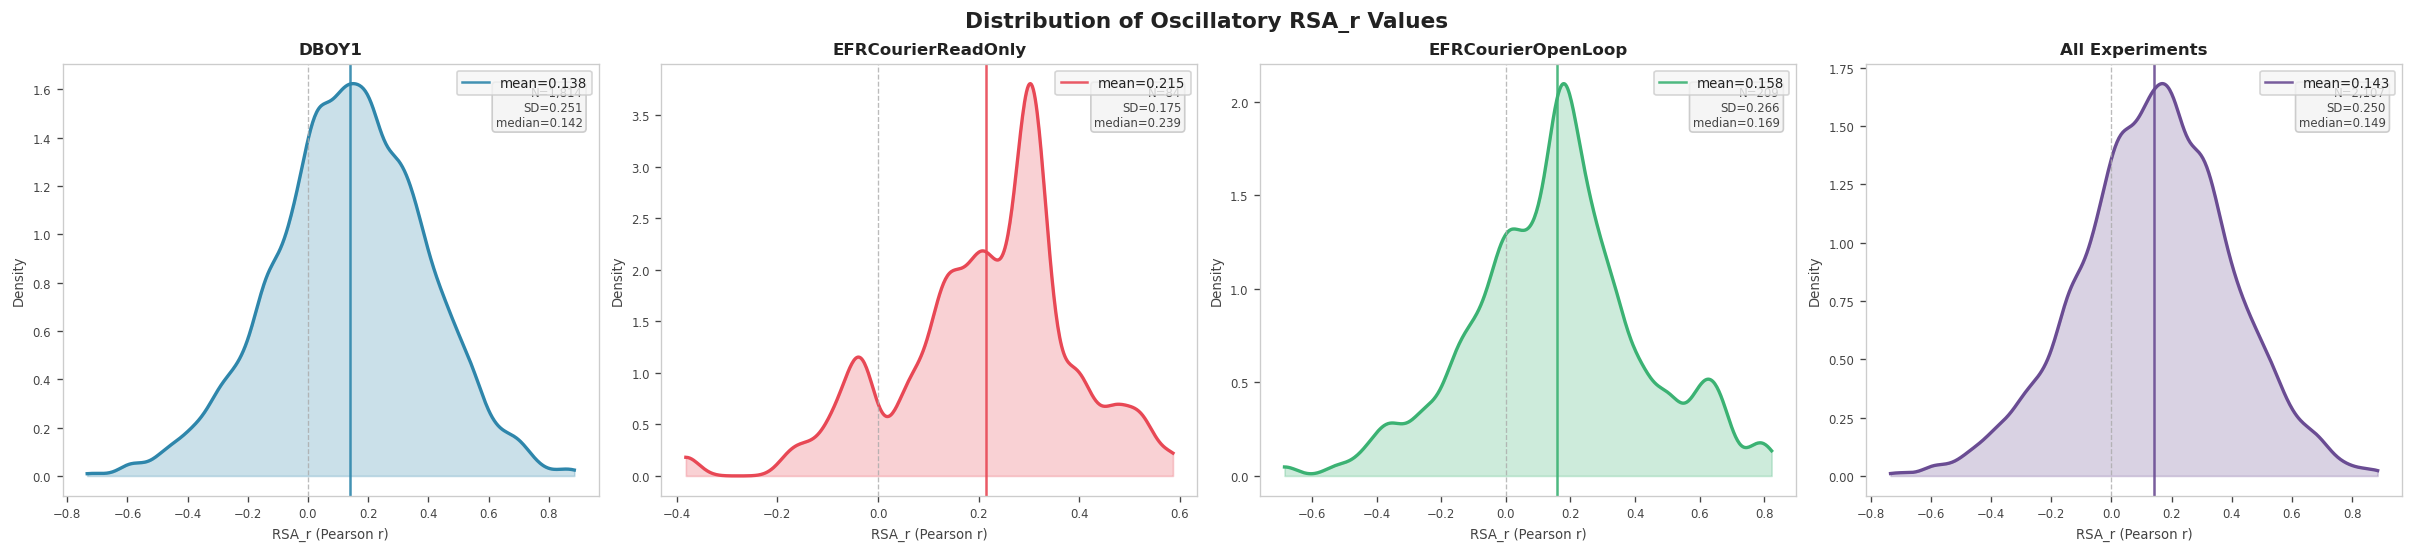


▶ Plot 2: Pairs per trial


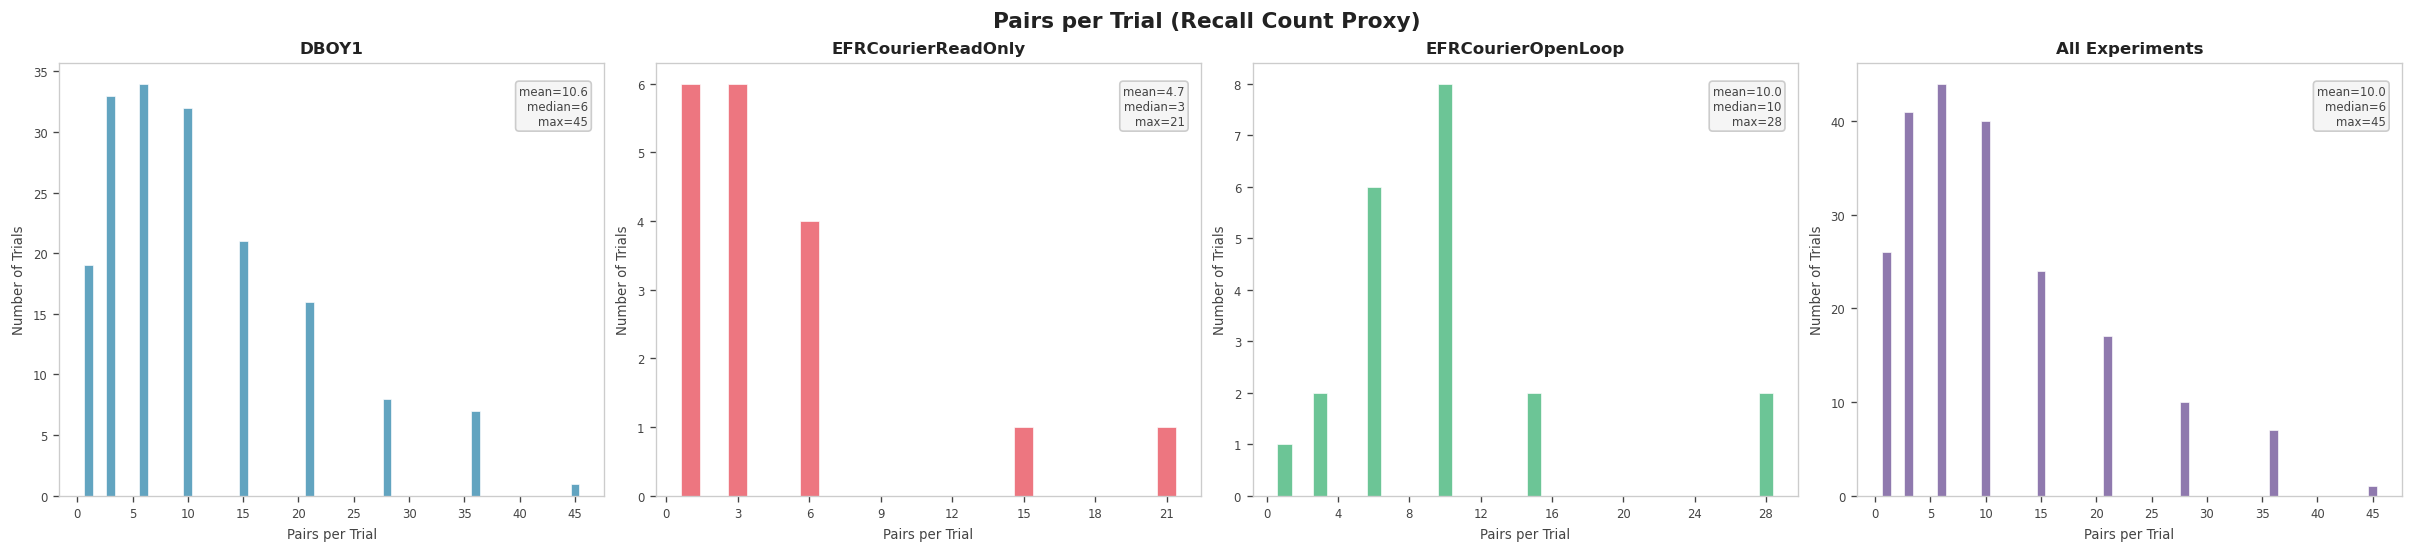


▶ Plot 3: Predictor distributions


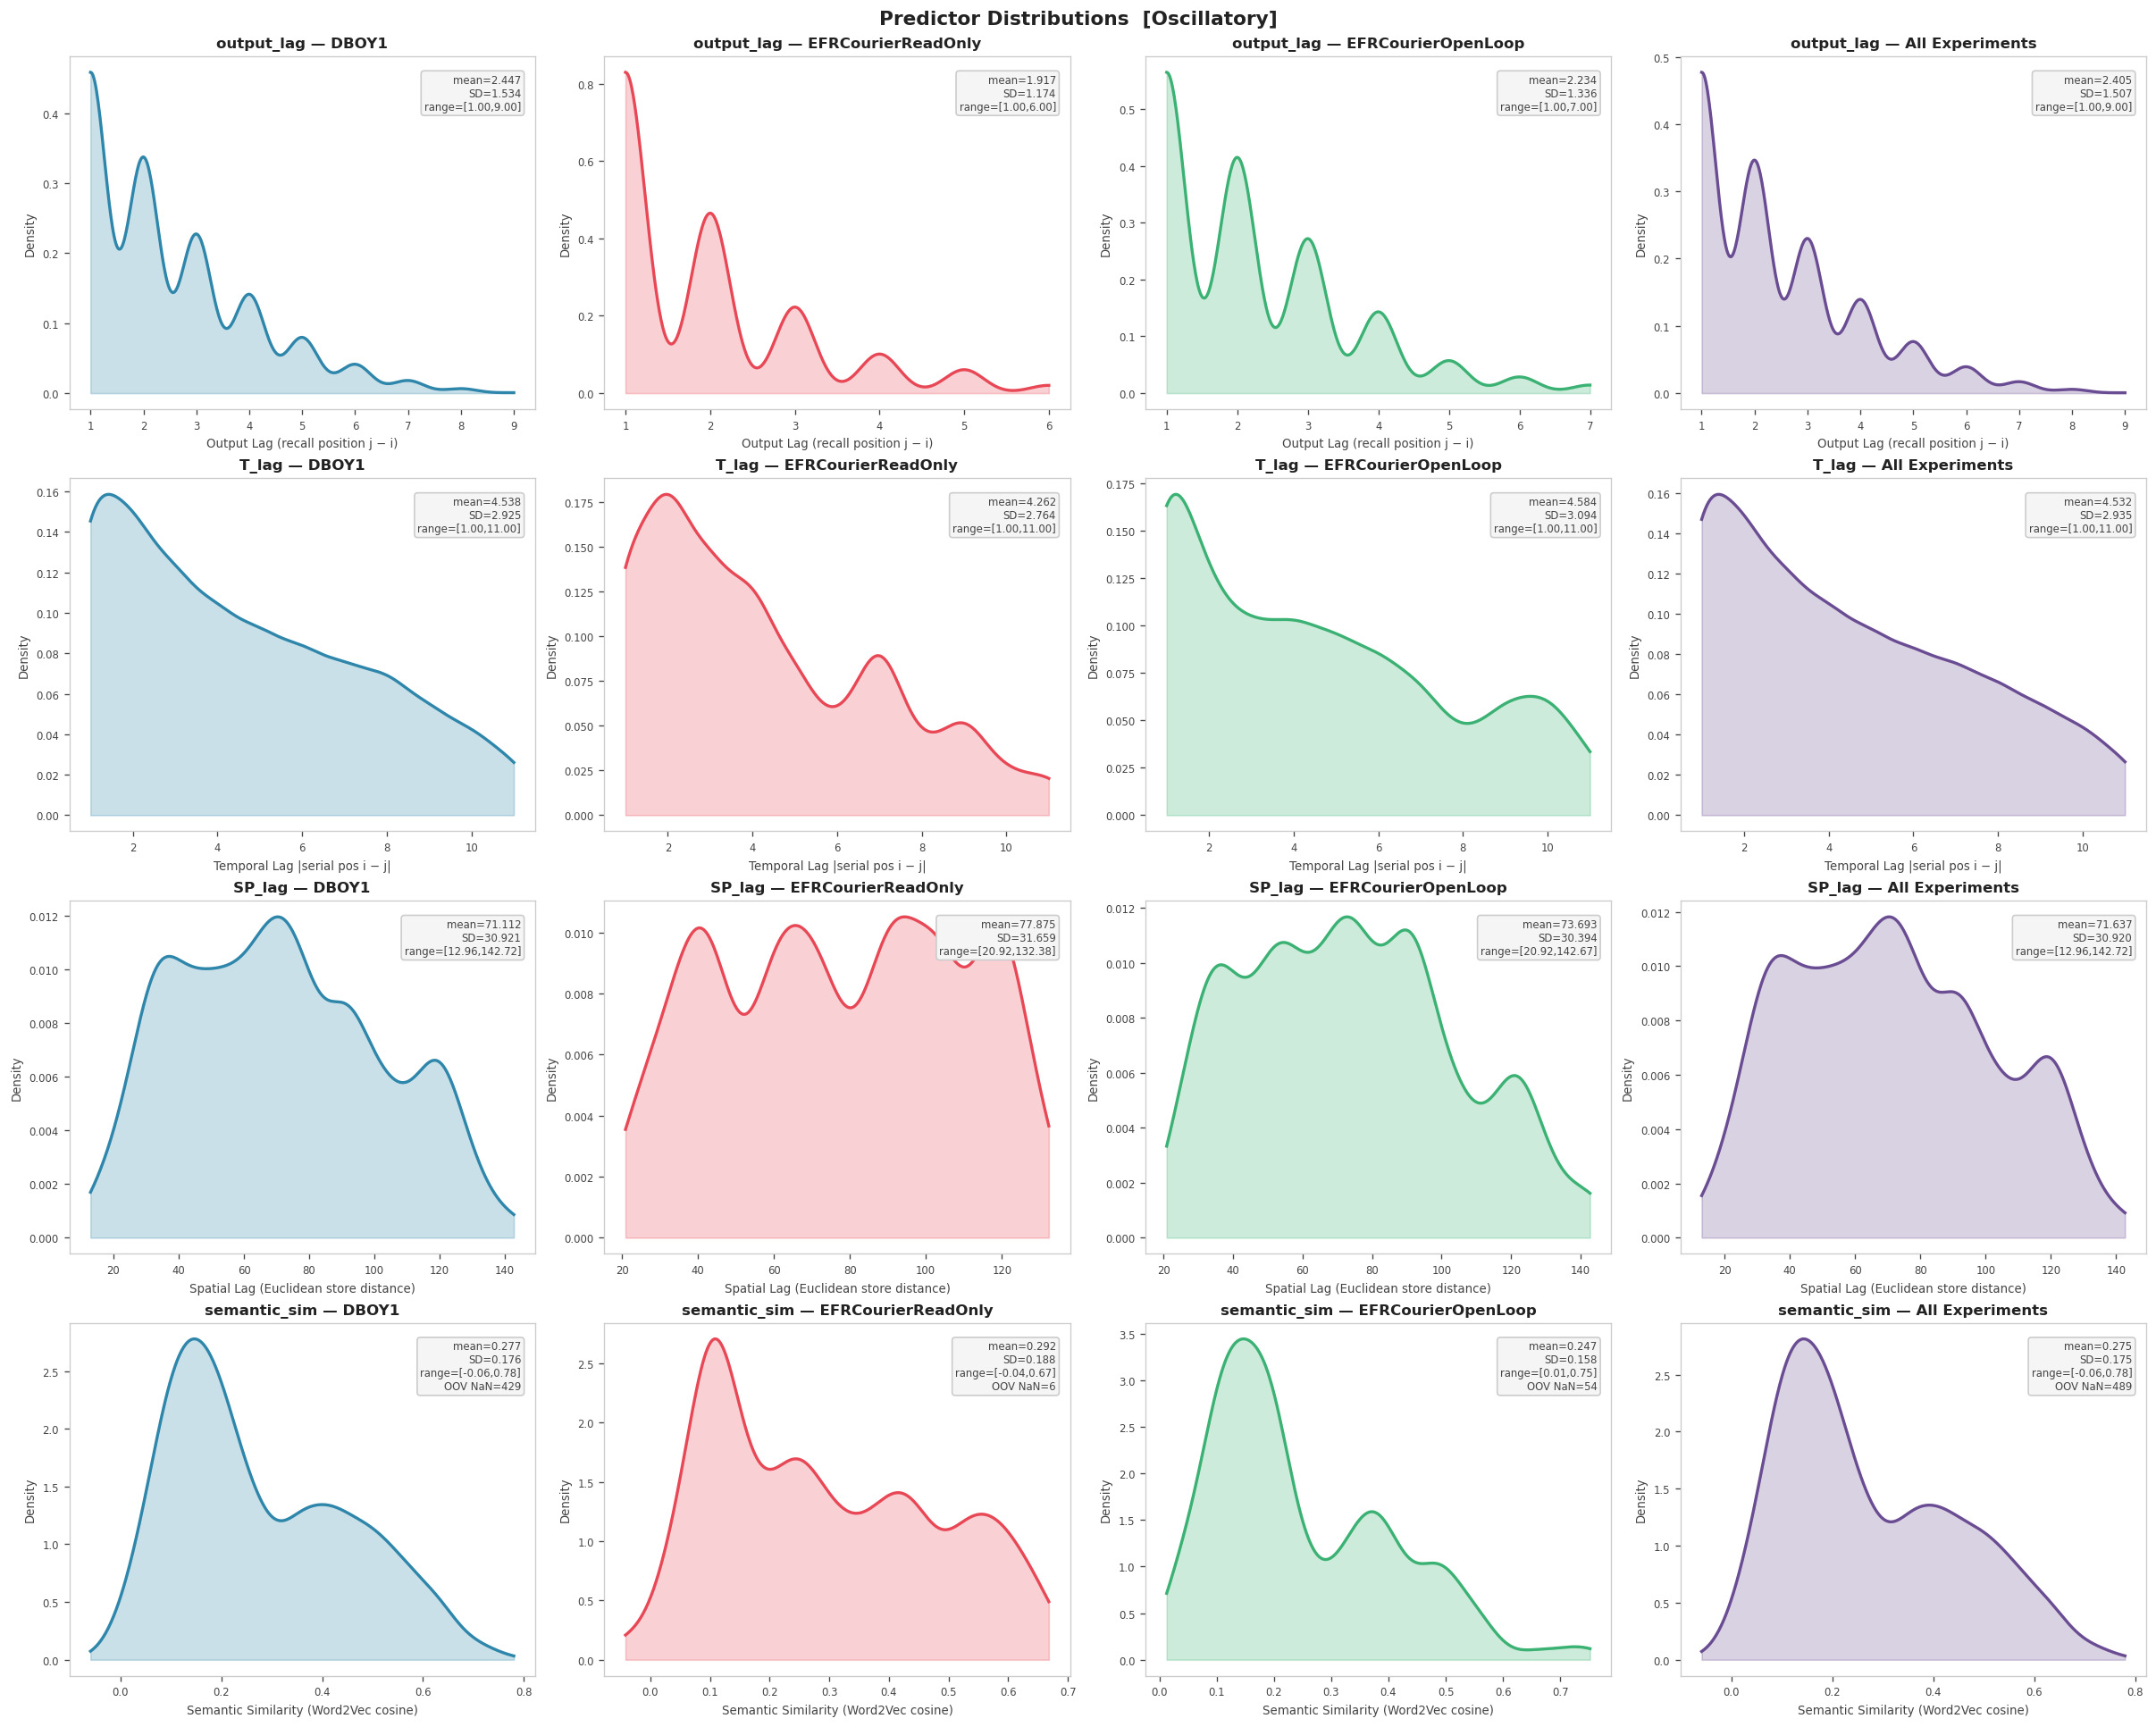


▶ Plot 4: RSA_r vs predictors (binned mean ± SEM + LOWESS)


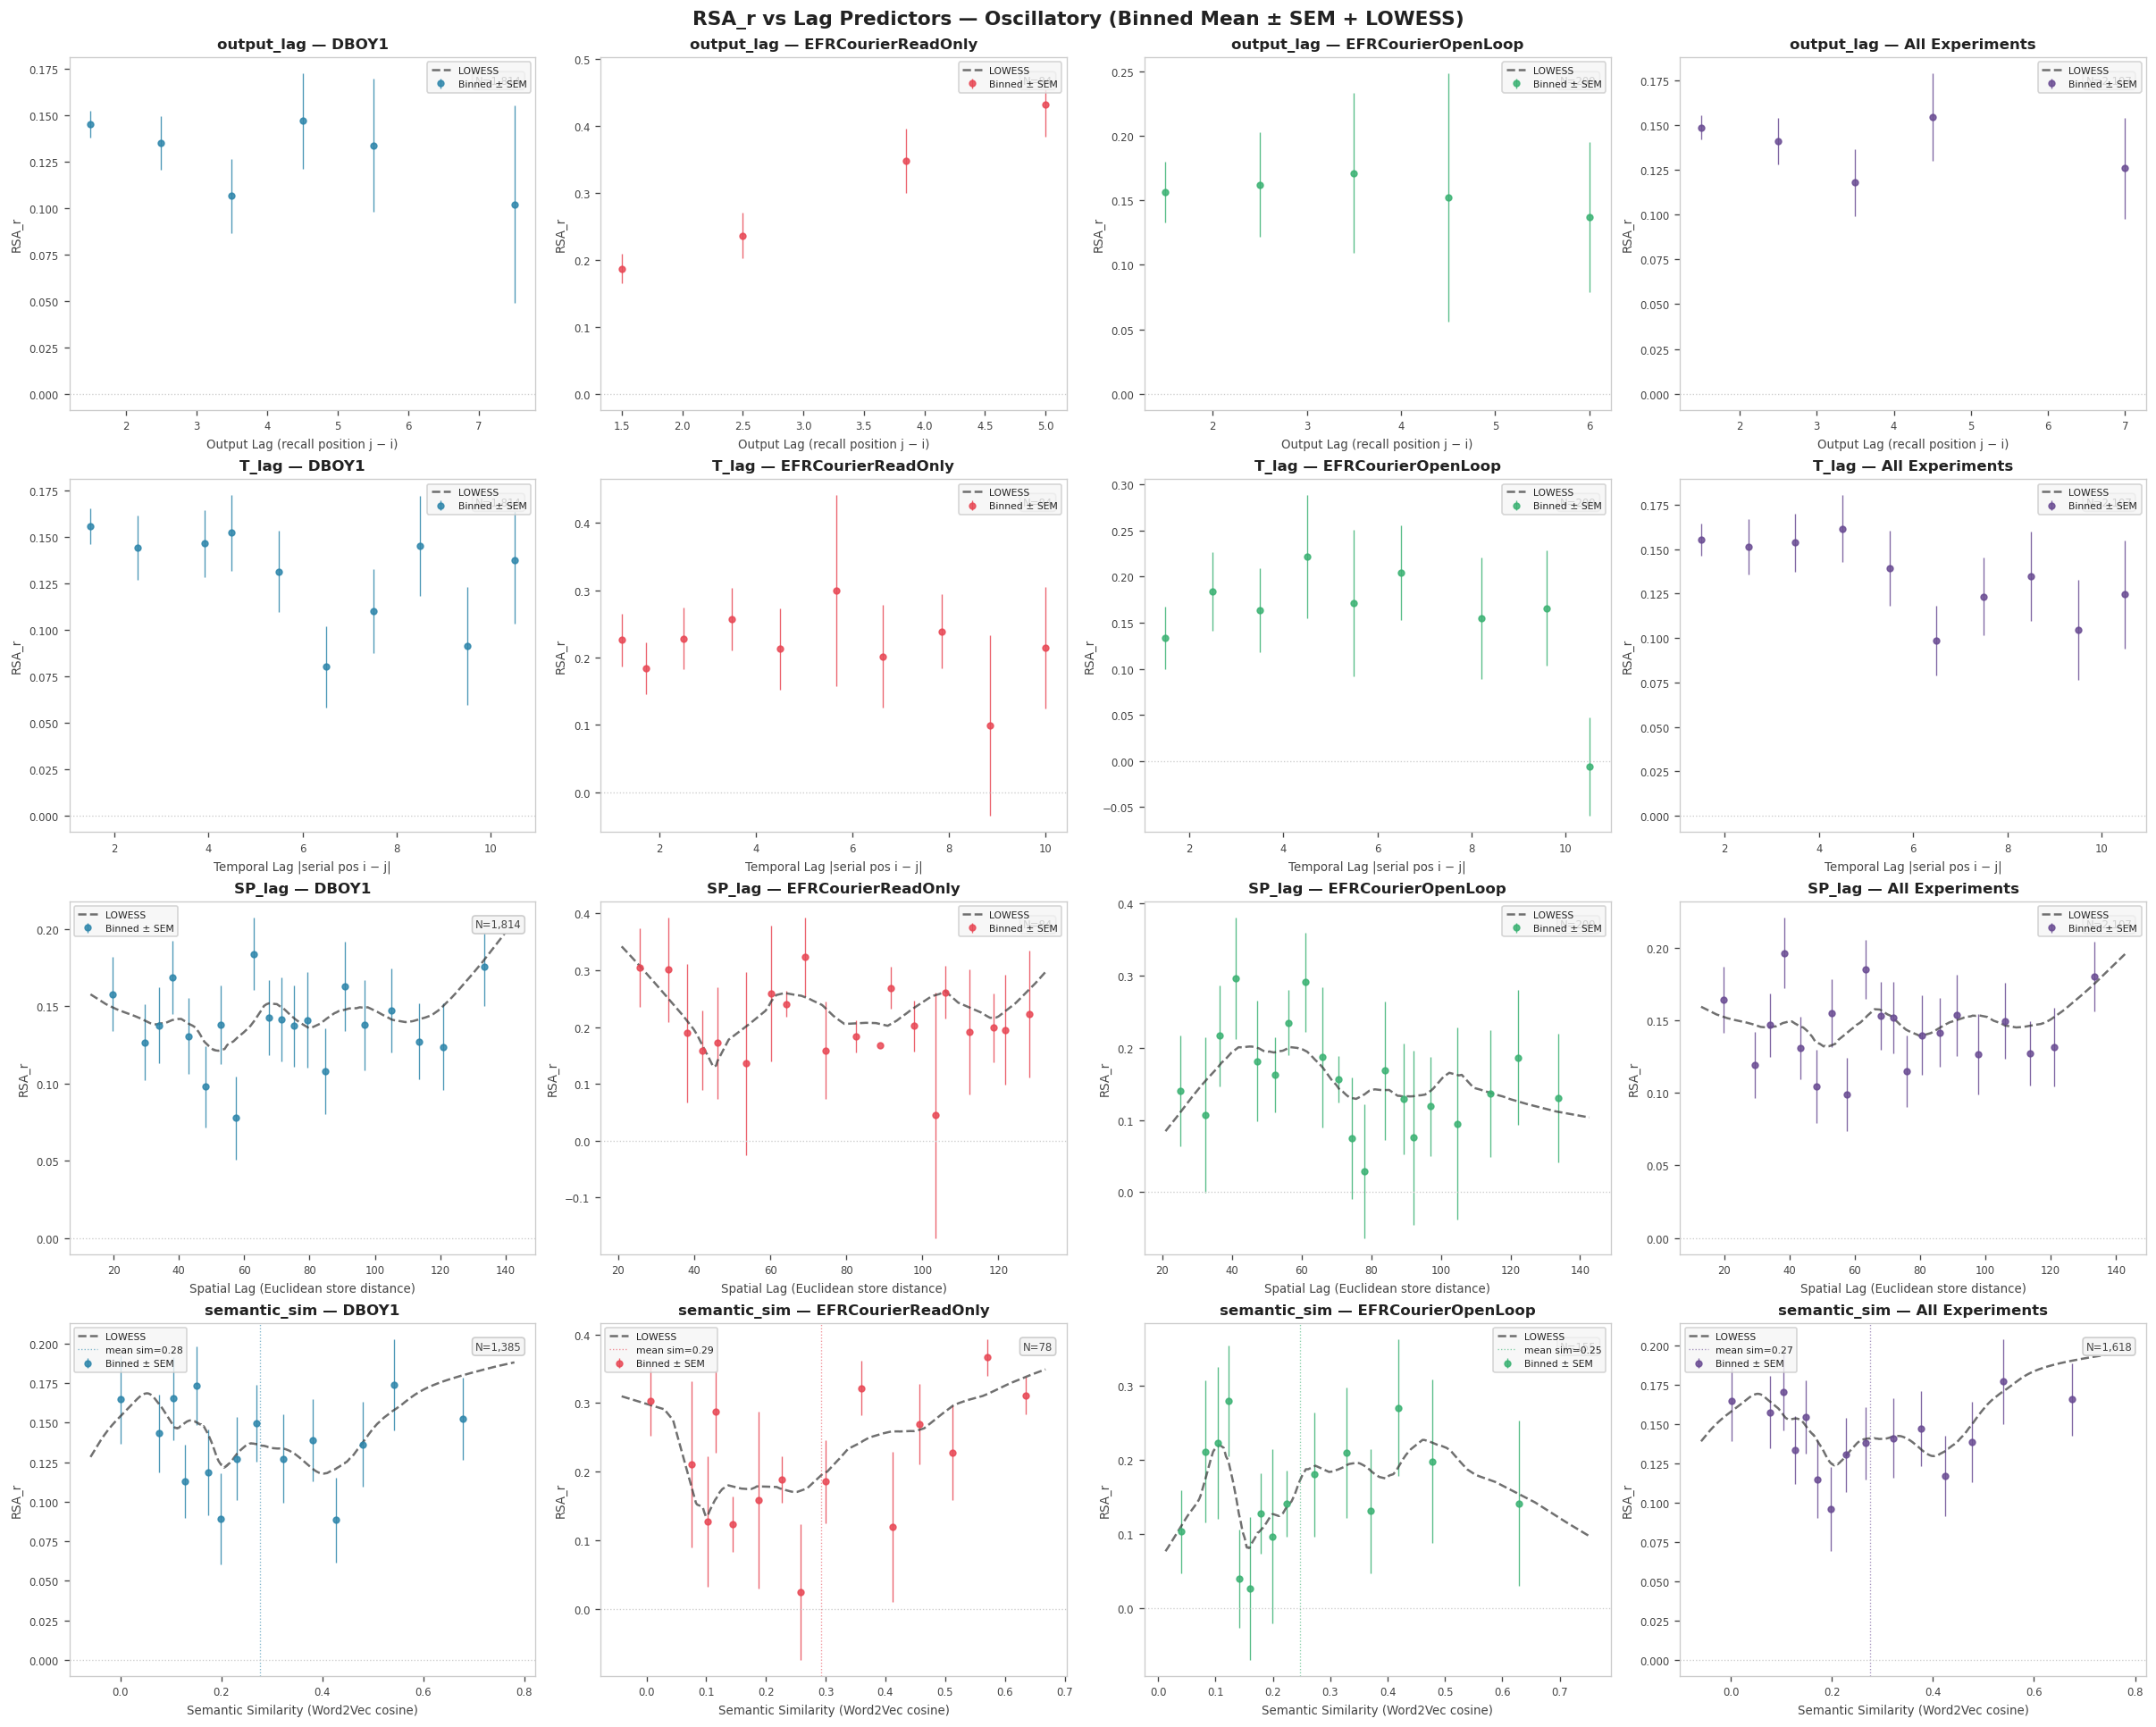


▶ Plot 5: Semantic similarity vs spatial & temporal lag


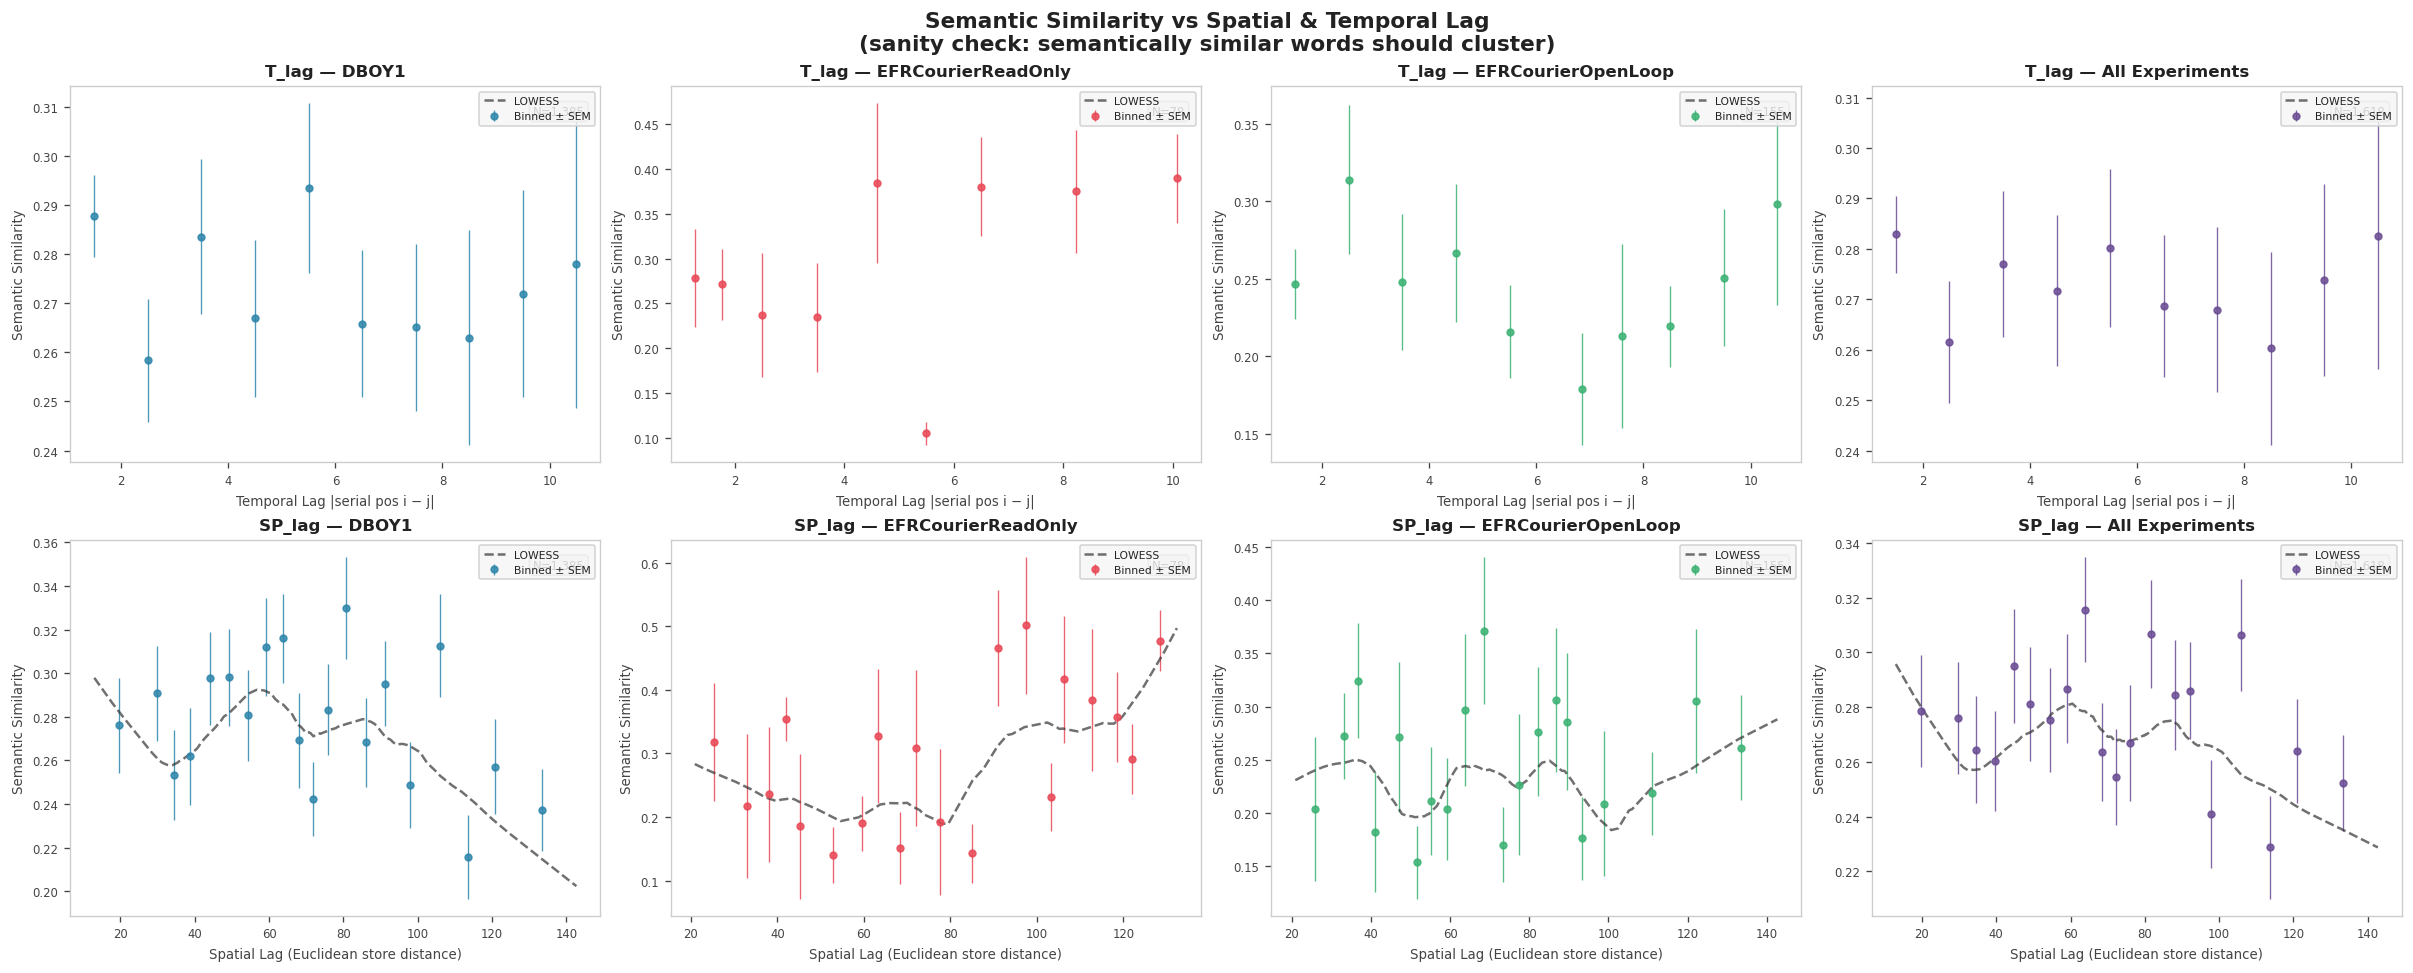


✓ All diagnostic plots complete.  [OSCILLATORY COMPONENT]


In [30]:
#!/usr/bin/env python3
"""
Diagnostic Visualizations for Oscillatory RSA Lag Data — Notebook Version
--------------------------------------------------------------------------
Run in Jupyter — all plots display inline.

Plots:
  1. Distribution of RSA_r values (per experiment + combined)
  2. Pairs per trial distribution
  3. Predictor distributions (T_lag, SP_lag, output_lag, semantic_sim)
  4. RSA_r vs each predictor (binned mean ± SEM + LOWESS)

Input  : ./rsa_lag_results/ALL_SUBJECTS_{exp}_rsa_lag_with_semsim.csv
         (output of add_semantic_similarity.py — includes semantic_sim column)

NOTE   : semantic_sim is silently skipped for any experiment whose CSV
         does not contain the column (e.g. if semsim script hasn't been run yet).
"""

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import MaxNLocator
from scipy.stats import gaussian_kde
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---- make plots show inline in Jupyter ----
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

EXPERIMENTS = ['DBOY1', 'EFRCourierReadOnly', 'EFRCourierOpenLoop']
INPUT_DIR   = Path('./rsa_lag_results')

COLORS = {
    'DBOY1':               '#2E86AB',
    'EFRCourierReadOnly':  '#E84855',
    'EFRCourierOpenLoop':  '#3BB273',
    'combined':            '#6A4C93',
}

# Base predictors always present; semantic_sim added dynamically if column exists
BASE_PREDICTORS = ['output_lag', 'T_lag', 'SP_lag']

PRED_LABELS = {
    'output_lag':    'Output Lag (recall position j − i)',
    'T_lag':         'Temporal Lag |serial pos i − j|',
    'SP_lag':        'Spatial Lag (Euclidean store distance)',
    'semantic_sim':  'Semantic Similarity (Word2Vec cosine)',
}

# ============================================================================
# LOAD DATA
# ============================================================================

dfs = []
for exp in EXPERIMENTS:
    # Prefer the enriched file (with semsim); fall back to base file
    for suffix in ['_rsa_lag_with_semsim.csv', '_rsa_lag.csv']:
        fpath = INPUT_DIR / f"ALL_SUBJECTS_{exp}{suffix}"
        if fpath.exists():
            df = pd.read_csv(fpath)
            df['experiment'] = exp
            dfs.append(df)
            has_sem = 'semantic_sim' in df.columns
            print(f"✓ Loaded {exp}: {len(df):,} pairs | "
                  f"{df['subject'].nunique()} subjects | "
                  f"semantic_sim={'YES' if has_sem else 'NO (run add_semantic_similarity.py)'}")
            break
    else:
        print(f"✗ Not found: {exp}")

df_all = pd.concat(dfs, ignore_index=True)
present_exps = [e for e in EXPERIMENTS if e in df_all['experiment'].unique()]

# Build final predictor list — include semantic_sim only if present in data
HAS_SEMSIM = 'semantic_sim' in df_all.columns
PREDICTORS  = BASE_PREDICTORS + (['semantic_sim'] if HAS_SEMSIM else [])

print(f"\nTotal rows : {len(df_all):,}")
print(f"Predictors : {PREDICTORS}")

# ============================================================================
# SUMMARY STATS
# ============================================================================

print("\n" + "="*65)
print("DIAGNOSTIC SUMMARY STATISTICS  [OSCILLATORY COMPONENT]")
print("="*65)

for exp in present_exps + ['ALL']:
    sub = df_all if exp == 'ALL' else df_all[df_all['experiment'] == exp]
    if sub.empty:
        continue
    print(f"\n--- {exp} ---")
    print(f"  Total pairs  : {len(sub):,}")
    print(f"  Subjects     : {sub['subject'].nunique()}")
    print(f"  Sessions     : {sub['session'].nunique()}")

    pairs_per_trial = sub.groupby(['subject', 'session', 'trial']).size()
    print(f"  Pairs/trial  : mean={pairs_per_trial.mean():.1f}  "
          f"median={pairs_per_trial.median():.0f}  "
          f"max={pairs_per_trial.max():.0f}")

    rsa = sub['RSA_r'].dropna()
    print(f"  RSA_r        : mean={rsa.mean():.4f}  SD={rsa.std():.4f}  "
          f"median={rsa.median():.4f}  NaN%={sub['RSA_r'].isna().mean()*100:.1f}%")

    for pred in PREDICTORS:
        if pred not in sub.columns:
            continue
        col = sub[pred].dropna()
        print(f"  {pred:<14}: mean={col.mean():.3f}  SD={col.std():.3f}  "
              f"range=[{col.min():.2f}, {col.max():.2f}]")

print("\n" + "="*65)

# ============================================================================
# HELPERS
# ============================================================================

def style_ax(ax, title, xlabel, ylabel):
    ax.set_facecolor('white')
    ax.set_title(title, color='#222222', fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel(xlabel, color='#444444', fontsize=8)
    ax.set_ylabel(ylabel, color='#444444', fontsize=8)
    ax.tick_params(colors='#444444', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')

def annotate(ax, text):
    ax.text(0.97, 0.95, text, transform=ax.transAxes,
            ha='right', va='top', color='#444444', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#F5F5F5', edgecolor='#CCCCCC'))

# ============================================================================
# PLOT 1 — RSA_r distribution
# ============================================================================

print("\n▶ Plot 1: RSA_r distribution")

n_cols = len(present_exps) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4.5),
                         constrained_layout=True)
fig.patch.set_facecolor('white')

plot_data = [(exp, df_all[df_all['experiment'] == exp]['RSA_r'], COLORS[exp])
             for exp in present_exps]
plot_data.append(('All Experiments', df_all['RSA_r'], COLORS['combined']))

for ax, (title, data, color) in zip(axes, plot_data):
    data = data.dropna()
    style_ax(ax, title, 'RSA_r (Pearson r)', 'Density')
    if len(data) > 1:
        kde_x = np.linspace(data.min(), data.max(), 500)
        kde   = gaussian_kde(data, bw_method=0.15)
        ax.fill_between(kde_x, kde(kde_x), alpha=0.25, color=color)
        ax.plot(kde_x, kde(kde_x), color=color, lw=2)
    ax.axvline(0, color='#AAAAAA', lw=0.8, ls='--', alpha=0.8)
    ax.axvline(data.mean(), color=color, lw=1.5, alpha=0.9,
               label=f'mean={data.mean():.3f}')
    ax.legend(fontsize=8, labelcolor='#222222',
              facecolor='#F5F5F5', edgecolor='#CCCCCC')
    annotate(ax, f'N={len(data):,}\nSD={data.std():.3f}\nmedian={data.median():.3f}')

fig.suptitle('Distribution of Oscillatory RSA_r Values',
             color='#222222', fontsize=13, fontweight='bold')
plt.show()

# ============================================================================
# PLOT 2 — Pairs per trial
# ============================================================================

print("\n▶ Plot 2: Pairs per trial")

fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4.5),
                         constrained_layout=True)
fig.patch.set_facecolor('white')

pair_data = [(exp, df_all[df_all['experiment'] == exp]
              .groupby(['subject', 'session', 'trial']).size(), COLORS[exp])
             for exp in present_exps]
pair_data.append(('All Experiments',
                  df_all.groupby(['subject', 'session', 'trial', 'experiment']).size(),
                  COLORS['combined']))

for ax, (title, counts, color) in zip(axes, pair_data):
    style_ax(ax, title, 'Pairs per Trial', 'Number of Trials')
    vc = counts.value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=color, alpha=0.75,
           edgecolor='white', linewidth=0.5)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    annotate(ax, f'mean={counts.mean():.1f}\nmedian={counts.median():.0f}\nmax={counts.max():.0f}')

fig.suptitle('Pairs per Trial (Recall Count Proxy)',
             color='#222222', fontsize=13, fontweight='bold')
plt.show()

# ============================================================================
# PLOT 3 — Predictor distributions (including semantic_sim if available)
# ============================================================================

print("\n▶ Plot 3: Predictor distributions")

fig, axes = plt.subplots(len(PREDICTORS), n_cols,
                         figsize=(5 * n_cols, 4 * len(PREDICTORS)),
                         constrained_layout=True)
# Ensure axes is always 2-D
if len(PREDICTORS) == 1:
    axes = axes[np.newaxis, :]
fig.patch.set_facecolor('white')

for row, pred in enumerate(PREDICTORS):
    cols_data = [(exp, df_all[df_all['experiment'] == exp][pred], COLORS[exp])
                 for exp in present_exps]
    cols_data.append(('All Experiments', df_all[pred], COLORS['combined']))

    for col_idx, (title, data, color) in enumerate(cols_data):
        ax = axes[row, col_idx]
        data = data.dropna()

        # semantic_sim: note self-pairs (sim=1) and NaN-OOV separately
        if pred == 'semantic_sim':
            n_nan  = df_all['semantic_sim'].isna().sum() if col_idx == n_cols - 1 \
                     else df_all[df_all['experiment'] == present_exps[col_idx]]['semantic_sim'].isna().sum()
            extra  = f'\nOOV NaN={n_nan:,}'
        else:
            extra = ''

        style_ax(ax, f'{pred} — {title}', PRED_LABELS.get(pred, pred), 'Density')
        if len(data) > 1:
            kde_x = np.linspace(data.min(), data.max(), 500)
            kde   = gaussian_kde(data, bw_method=0.2)
            ax.fill_between(kde_x, kde(kde_x), alpha=0.25, color=color)
            ax.plot(kde_x, kde(kde_x), color=color, lw=2)
        annotate(ax, f'mean={data.mean():.3f}\nSD={data.std():.3f}\n'
                     f'range=[{data.min():.2f},{data.max():.2f}]{extra}')

fig.suptitle('Predictor Distributions  [Oscillatory]',
             color='#222222', fontsize=13, fontweight='bold')
plt.show()

# ============================================================================
# PLOT 4 — RSA_r vs each predictor  (including semantic_sim if available)
# ============================================================================

print("\n▶ Plot 4: RSA_r vs predictors (binned mean ± SEM + LOWESS)")

fig, axes = plt.subplots(len(PREDICTORS), n_cols,
                         figsize=(5 * n_cols, 4 * len(PREDICTORS)),
                         constrained_layout=True)
if len(PREDICTORS) == 1:
    axes = axes[np.newaxis, :]
fig.patch.set_facecolor('white')

for row, pred in enumerate(PREDICTORS):
    cols_data = [(exp, df_all[df_all['experiment'] == exp], COLORS[exp])
                 for exp in present_exps]
    cols_data.append(('All Experiments', df_all, COLORS['combined']))

    for col_idx, (title, sub, color) in enumerate(cols_data):
        ax = axes[row, col_idx]
        style_ax(ax, f'{pred} — {title}', PRED_LABELS.get(pred, pred), 'RSA_r')

        sub = sub[[pred, 'RSA_r']].dropna()
        if len(sub) < 10:
            ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                    transform=ax.transAxes, color='#AAAAAA')
            continue

        # Binned mean ± SEM
        # semantic_sim: use 15 quantile bins (values compressed near 0–1)
        n_bins = 15 if pred == 'semantic_sim' else 20
        try:
            sub = sub.copy()
            sub['bin'] = pd.qcut(sub[pred], q=n_bins, duplicates='drop')
            binned  = (sub.groupby('bin', observed=True)['RSA_r']
                       .agg(['mean', 'sem', 'count']).reset_index())
            centers = binned['bin'].apply(lambda x: x.mid).astype(float)
            ax.errorbar(centers, binned['mean'], yerr=binned['sem'],
                        fmt='o', color=color, ms=4, lw=1.2,
                        elinewidth=0.8, alpha=0.85, label='Binned ± SEM')
        except Exception:
            pass

        # LOWESS
        try:
            sm = lowess(sub['RSA_r'].values, sub[pred].values,
                        frac=0.3, return_sorted=True)
            ax.plot(sm[:, 0], sm[:, 1], color='#333333', lw=1.5,
                    alpha=0.7, ls='--', label='LOWESS')
        except Exception:
            pass

        # For semantic_sim: add a vertical reference at the grand mean
        if pred == 'semantic_sim':
            ax.axvline(sub[pred].mean(), color=color, lw=0.8,
                       ls=':', alpha=0.6, label=f'mean sim={sub[pred].mean():.2f}')

        ax.axhline(0, color='#CCCCCC', lw=0.8, ls=':')
        ax.legend(fontsize=6.5, labelcolor='#222222',
                  facecolor='#F5F5F5', edgecolor='#CCCCCC')

        annotate(ax, f'N={len(sub):,}')

fig.suptitle('RSA_r vs Lag Predictors — Oscillatory (Binned Mean ± SEM + LOWESS)',
             color='#222222', fontsize=13, fontweight='bold')
plt.show()

# ============================================================================
# PLOT 5 — semantic_sim vs T_lag and SP_lag  (only if semsim present)
# ============================================================================

if HAS_SEMSIM:
    print("\n▶ Plot 5: Semantic similarity vs spatial & temporal lag")

    fig, axes = plt.subplots(2, n_cols,
                             figsize=(5 * n_cols, 8),
                             constrained_layout=True)
    fig.patch.set_facecolor('white')

    for row, lag_pred in enumerate(['T_lag', 'SP_lag']):
        cols_data = [(exp, df_all[df_all['experiment'] == exp], COLORS[exp])
                     for exp in present_exps]
        cols_data.append(('All Experiments', df_all, COLORS['combined']))

        for col_idx, (title, sub, color) in enumerate(cols_data):
            ax = axes[row, col_idx]
            style_ax(ax, f'{lag_pred} — {title}',
                     PRED_LABELS[lag_pred], 'Semantic Similarity')

            sub = sub[[lag_pred, 'semantic_sim']].dropna()
            if len(sub) < 10:
                ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                        transform=ax.transAxes, color='#AAAAAA')
                continue

            # Binned mean ± SEM
            try:
                sub = sub.copy()
                sub['bin'] = pd.qcut(sub[lag_pred], q=20, duplicates='drop')
                binned  = (sub.groupby('bin', observed=True)['semantic_sim']
                           .agg(['mean', 'sem']).reset_index())
                centers = binned['bin'].apply(lambda x: x.mid).astype(float)
                ax.errorbar(centers, binned['mean'], yerr=binned['sem'],
                            fmt='o', color=color, ms=4, lw=1.2,
                            elinewidth=0.8, alpha=0.85, label='Binned ± SEM')
            except Exception:
                pass

            # LOWESS
            try:
                sm = lowess(sub['semantic_sim'].values, sub[lag_pred].values,
                            frac=0.3, return_sorted=True)
                ax.plot(sm[:, 0], sm[:, 1], color='#333333', lw=1.5,
                        alpha=0.7, ls='--', label='LOWESS')
            except Exception:
                pass

            ax.legend(fontsize=6.5, labelcolor='#222222',
                      facecolor='#F5F5F5', edgecolor='#CCCCCC')
            annotate(ax, f'N={len(sub):,}')

    fig.suptitle('Semantic Similarity vs Spatial & Temporal Lag\n'
                 '(sanity check: semantically similar words should cluster)',
                 color='#222222', fontsize=13, fontweight='bold')
    plt.show()

print("\n✓ All diagnostic plots complete.  [OSCILLATORY COMPONENT]")

In [31]:
#!/usr/bin/env python3
"""
LMM Analysis: RSA_r ~ SP_near + output_lag_z + T_lag_z + semantic_sim_z
--------------------------------------------------------------------------------
SP_lag is binarized into near vs far using a median split (per experiment).
semantic_sim (Word2Vec cosine) is z-scored and included as a continuous predictor.

Models per experiment:
  Model A  : RSA_r ~ SP_near                                        + (1|subj/sess)
  Model B  : RSA_r ~ SP_near + output_lag_z + T_lag_z               + (1|subj/sess)
  Model C  : RSA_r ~ semantic_sim_z                                  + (1|subj/sess)
  Model D  : RSA_r ~ SP_near + output_lag_z + T_lag_z + sem_sim_z   + (1|subj/sess)

Models A & B run on the full dataset (semantic_sim not required).
Models C & D run only on rows where semantic_sim is non-NaN.

SP_near = 1 if SP_lag <= median(SP_lag), else 0

Input  : ./rsa_lag_results/ALL_SUBJECTS_{exp}_rsa_lag_with_semsim.csv
         (falls back to ALL_SUBJECTS_{exp}_rsa_lag.csv for Models A & B)
Output : ./rsa_lag_results/LMM_{exp}_rsa_lag_semsim_results.csv
         ./rsa_lag_results/LMM_{exp}_rsa_lag_semsim_results.txt
"""

import warnings
import traceback
from pathlib import Path
from typing import List, Optional

import numpy as np
import pandas as pd
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import fdrcorrection

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENTS = ['DBOY1', 'EFRCourierReadOnly', 'EFRCourierOpenLoop']
INPUT_DIR   = Path('./rsa_lag_results')
OUTPUT_DIR  = Path('./rsa_lag_results')

OUTCOME      = 'RSA_r'
SP_THRESHOLD = None   # None = median split; float = fixed cutoff

# ============================================================================
# HELPERS
# ============================================================================

def zscore_global(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            continue
        m, s = df[col].mean(), df[col].std(ddof=1)
        df[col + '_z'] = (df[col] - m) / s if s > 0 else 0.0
    return df


def add_sp_near(df: pd.DataFrame, threshold=None):
    df = df.copy()
    if threshold is None:
        cutoff = df['SP_lag'].median()
        print(f"  SP_lag median split threshold : {cutoff:.2f}")
    else:
        cutoff = float(threshold)
        print(f"  SP_lag fixed threshold        : {cutoff:.2f}")
    df['SP_near'] = (df['SP_lag'] <= cutoff).astype(int)
    print(f"  SP_near=1 (near) proportion   : {df['SP_near'].mean()*100:.1f}%")
    return df, cutoff


def fit_lmm(
    df: pd.DataFrame,
    outcome: str,
    pred_cols: List[str],
    label: str,
):
    df = df.copy()
    df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)
    keep = [outcome] + pred_cols + ['subject', 'subj_sess']
    df   = df[keep].dropna()

    if len(df) < 20:
        print(f"    [{label}] Too few rows ({len(df)}) — skipping")
        return None, 0

    formula = f"{outcome} ~ {' + '.join(pred_cols)}"
    print(f"    [{label}] Formula : {formula}  |  N = {len(df):,}")

    model = MixedLM.from_formula(
        formula,
        data       = df,
        groups     = df['subject'],
        vc_formula = {'subj_sess': '0 + C(subj_sess)'}
    )

    # Random effects structure:
    #   groups=subject          → random intercept per subject  (1 | subject)
    #   vc_formula subj_sess    → additional variance component per
    #                             subject×session combination   (1 | subject:session)
    # Together this implements (1 | subject/session) nesting.

    # Optimizer cascade: lbfgs → nm → powell
    # lbfgs can produce NaN log-likelihood when variance components hit
    # a boundary; nm and powell are more robust in those cases.
    result = None
    for method in ['lbfgs', 'nm', 'powell']:
        try:
            result = model.fit(reml=True, method=method)
            converged = getattr(result, 'converged', None)
            llf_ok    = np.isfinite(result.llf)
            llf_str = '{:.4f}'.format(result.llf) if llf_ok else 'NaN'
            aic_str = '{:.4f}'.format(result.aic) if llf_ok else 'NaN'
            print('    [{}] optimizer={}  converged={}  llf={}  AIC={}'.format(
                label, method, converged, llf_str, aic_str))
            if llf_ok:
                break   # accept first optimizer that gives finite llf
            else:
                print('    [{}] llf=NaN with {}, trying next ...'.format(label, method))
        except Exception as e:
            print('    [{}] optimizer={} failed: {}'.format(label, method, e))
            result = None
            continue

    if result is None:
        print(f"    [{label}] All optimizers failed — skipping")
        return None, 0

    if not np.isfinite(result.llf):
        print(f"    [{label}] WARNING: llf still NaN after all optimizers. "
              f"Results saved but AIC/LRT unreliable. "
              f"Consider simplifying random effects.")

    return result, len(df)


def extract_rows(result, pred_display: dict) -> pd.DataFrame:
    """pred_display : {col_in_model: display_name}"""
    print(f"    Params: {list(result.params.index)}")
    rows = []
    for col, name in pred_display.items():
        matched = col if col in result.params.index else None
        if matched is None:
            hits = [k for k in result.params.index
                    if col.lower().replace('_z', '') in k.lower()]
            matched = hits[0] if hits else None
        if matched is None:
            print(f"    WARNING: '{col}' not found in params — skipping")
            continue
        rows.append({
            'predictor': name,
            'col':       col,
            'beta':      result.params[matched],
            'se':        result.bse[matched],
            'z':         result.tvalues[matched],
            'p':         result.pvalues[matched],
            'llf':       result.llf,
            'aic':       result.aic,
            'nobs':      int(result.nobs),
        })
    return pd.DataFrame(rows)


def apply_fdr(rows_df: pd.DataFrame) -> pd.DataFrame:
    if rows_df.empty:
        return rows_df
    _, rows_df['p_fdr'] = fdrcorrection(rows_df['p'].values)
    return rows_df


def format_block(title: str, rows_df: pd.DataFrame) -> str:
    sep  = '=' * 76
    sep2 = '-' * 76
    lines = [sep, title, sep2,
             f"{'Predictor':<26} {'β':>8} {'SE':>8} {'z':>8} "
             f"{'p_raw':>10} {'p_fdr':>10} {'AIC':>10} {'N':>8} {'sig':>5}",
             sep2]
    for _, row in rows_df.iterrows():
        sig = ('***' if row['p_fdr'] < 0.001 else
               '**'  if row['p_fdr'] < 0.01  else
               '*'   if row['p_fdr'] < 0.05  else
               '†'   if row['p_fdr'] < 0.10  else '')
        aic_disp = '{:>10.2f}'.format(row['aic']) if pd.notna(row['aic']) else '       NaN'
        lines.append(
            '{:<26} {:>8.4f} {:>8.4f} {:>8.3f} {:>10.4f} {:>10.4f} {} {:>8,} {:>5}'.format(
                row['predictor'], row['beta'], row['se'], row['z'],
                row['p'], row['p_fdr'], aic_disp, int(row['nobs']), sig)
        )
    lines += [sep2,
              'FDR: BH correction within each model across predictors',
              '† p<.10  * p<.05  ** p<.01  *** p<.001',
              sep]
    return '\n'.join(lines)


# ============================================================================
# MAIN
# ============================================================================

def run_experiment(exp: str):
    print(f"\n{'='*76}")
    print(f"EXPERIMENT: {exp}")
    print(f"{'='*76}")

    # Prefer enriched file (with semsim); fall back to base file
    for suffix in ['_rsa_lag_with_semsim.csv', '_rsa_lag.csv']:
        fpath = INPUT_DIR / f"ALL_SUBJECTS_{exp}{suffix}"
        if fpath.exists():
            df = pd.read_csv(fpath)
            has_semsim = 'semantic_sim' in df.columns
            print(f"  Loaded {fpath.name}")
            print(f"  Rows: {len(df):,} | Subjects: {df['subject'].nunique()} | "
                  f"semantic_sim: {'YES' if has_semsim else 'NO — Models C/D skipped'}")
            break
    else:
        print(f"  ✗ No input CSV found for {exp}")
        return

    df = df.dropna(subset=[OUTCOME, 'SP_lag', 'output_lag', 'T_lag'])
    print(f"  After base dropna: {len(df):,} rows")

    # SP_near binary + z-scores for continuous predictors
    df, cutoff = add_sp_near(df, SP_THRESHOLD)
    z_cols = ['output_lag', 'T_lag']
    if has_semsim:
        z_cols.append('semantic_sim')
    df = zscore_global(df, z_cols)

    n_subj = df['subject'].nunique()
    n_sess = df['session'].nunique()

    all_text     = [
        f"EXPERIMENT: {exp}",
        f"SP_lag threshold : {cutoff:.2f}  (SP_near=1 if SP_lag <= threshold)",
        f"N subjects       : {n_subj}  |  N sessions: {n_sess}",
        f"semantic_sim     : {'present' if has_semsim else 'absent — Models C/D not run'}\n",
    ]
    all_csv_rows = []
    fitted       = {}

    # ── Model A: SP_near alone ────────────────────────────────────────────────
    print("\n  --- Model A: RSA_r ~ SP_near ---")
    res_a, _ = fit_lmm(df, OUTCOME, ['SP_near'], 'Model A')
    if res_a:
        fe_a = apply_fdr(extract_rows(res_a, {
            'SP_near': 'SP_near (0=far, 1=near)',
        }))
        fe_a['model'] = 'A_SP_alone'
        fe_a['experiment'] = exp
        all_csv_rows.append(fe_a)
        block = format_block(
            f'Model A — RSA_r ~ SP_near  (SP_lag ≤ {cutoff:.1f} = near)', fe_a)
        print('\n' + block)
        all_text.append(block)
        fitted['Model A'] = res_a

    # ── Model B: SP_near + output_lag_z + T_lag_z ────────────────────────────
    print("\n  --- Model B: RSA_r ~ SP_near + output_lag_z + T_lag_z ---")
    res_b, _ = fit_lmm(df, OUTCOME,
                        ['SP_near', 'output_lag_z', 'T_lag_z'], 'Model B')
    if res_b:
        fe_b = apply_fdr(extract_rows(res_b, {
            'SP_near':      'SP_near (0=far, 1=near)',
            'output_lag_z': 'output_lag (z)',
            'T_lag_z':      'T_lag (z)',
        }))
        fe_b['model'] = 'B_SP_covariates'
        fe_b['experiment'] = exp
        all_csv_rows.append(fe_b)
        block = format_block(
            f'Model B — RSA_r ~ SP_near + output_lag_z + T_lag_z'
            f'  (SP_lag ≤ {cutoff:.1f} = near)', fe_b)
        print('\n' + block)
        all_text.append(block)
        fitted['Model B'] = res_b

    # ── Models C & D: only if semantic_sim is present ────────────────────────
    if has_semsim:
        df_sem = df.dropna(subset=['semantic_sim_z'])
        n_oov  = len(df) - len(df_sem)
        print(f"\n  semantic_sim available rows: {len(df_sem):,} "
              f"(dropped {n_oov:,} OOV NaN rows)")

        # ── Model C: semantic_sim alone ──────────────────────────────────────
        print("\n  --- Model C: RSA_r ~ semantic_sim_z ---")
        res_c, _ = fit_lmm(df_sem, OUTCOME, ['semantic_sim_z'], 'Model C')
        if res_c:
            fe_c = apply_fdr(extract_rows(res_c, {
                'semantic_sim_z': 'semantic_sim (z)',
            }))
            fe_c['model'] = 'C_semsim_alone'
            fe_c['experiment'] = exp
            all_csv_rows.append(fe_c)
            block = format_block(
                'Model C — RSA_r ~ semantic_sim_z', fe_c)
            print('\n' + block)
            all_text.append(block)
            fitted['Model C'] = res_c

        # ── Model D: full model ──────────────────────────────────────────────
        print("\n  --- Model D: RSA_r ~ SP_near + output_lag_z + T_lag_z"
              " + semantic_sim_z ---")
        res_d, _ = fit_lmm(
            df_sem, OUTCOME,
            ['SP_near', 'output_lag_z', 'T_lag_z', 'semantic_sim_z'],
            'Model D',
        )
        if res_d:
            fe_d = apply_fdr(extract_rows(res_d, {
                'SP_near':          'SP_near (0=far, 1=near)',
                'output_lag_z':     'output_lag (z)',
                'T_lag_z':          'T_lag (z)',
                'semantic_sim_z':   'semantic_sim (z)',
            }))
            fe_d['model'] = 'D_full'
            fe_d['experiment'] = exp
            all_csv_rows.append(fe_d)
            block = format_block(
                f'Model D — RSA_r ~ SP_near + output_lag_z + T_lag_z'
                f' + semantic_sim_z  (SP_lag ≤ {cutoff:.1f} = near)', fe_d)
            print('\n' + block)
            all_text.append(block)
            fitted['Model D'] = res_d

        # ── AIC comparison across models ─────────────────────────────────────
        aic_rows = []
        for label, res in fitted.items():
            aic_rows.append({
                'model': label,
                'AIC':   res.aic,
                'N':     int(res.nobs),
            })

        aic_block = ['', '--- AIC comparison (lower = better fit) ---']
        if aic_rows:
            aic_df = pd.DataFrame(aic_rows)
            # Sort by AIC; put NaN rows at the bottom
            aic_df = aic_df.sort_values('AIC', na_position='last')
            for _, r in aic_df.iterrows():
                aic_val = f"{r['AIC']:.2f}" if pd.notna(r['AIC']) else 'NaN (llf failed)'
                aic_block.append(
                    f"  {r['model']:<12} AIC={aic_val:<22}  N={int(r['N']):,}"
                )
        else:
            aic_block.append("  (no models fitted)")

        aic_str = '\n'.join(aic_block)
        print(aic_str)
        all_text.append(aic_str)

    # ── Save ─────────────────────────────────────────────────────────────────
    if not all_csv_rows:
        print("  No results to save.")
        return

    result_df = pd.concat(all_csv_rows, ignore_index=True)
    csv_path  = OUTPUT_DIR / f"LMM_{exp}_rsa_lag_semsim_results.csv"
    txt_path  = OUTPUT_DIR / f"LMM_{exp}_rsa_lag_semsim_results.txt"

    result_df.to_csv(csv_path, index=False)
    with open(txt_path, 'w') as f:
        f.write('\n\n'.join(all_text))
        for label, res in fitted.items():
            f.write(f'\n\n{"="*76}\n')
            f.write(f'Full statsmodels summary — {label}\n')
            f.write(f'{"="*76}\n')
            f.write(res.summary().as_text())

    print(f"\n  ✓ Saved: {csv_path}")
    print(f"  ✓ Saved: {txt_path}")


if __name__ == '__main__':
    for exp in EXPERIMENTS:
        run_experiment(exp)

    print(f"\n{'='*76}")
    print("ALL EXPERIMENTS COMPLETE")
    print(f"{'='*76}")


EXPERIMENT: DBOY1
  Loaded ALL_SUBJECTS_DBOY1_rsa_lag_with_semsim.csv
  Rows: 1,814 | Subjects: 27 | semantic_sim: YES
  After base dropna: 1,814 rows
  SP_lag median split threshold : 69.97
  SP_near=1 (near) proportion   : 50.7%

  --- Model A: RSA_r ~ SP_near ---
    [Model A] Formula : RSA_r ~ SP_near  |  N = 1,814
    [Model A] optimizer=lbfgs  converged=True  llf=-12.6684  AIC=nan
    Params: ['Intercept', 'SP_near', 'subj_sess Var']

Model A — RSA_r ~ SP_near  (SP_lag ≤ 70.0 = near)
----------------------------------------------------------------------------
Predictor                         β       SE        z      p_raw      p_fdr        AIC        N   sig
----------------------------------------------------------------------------
SP_near (0=far, 1=near)      0.0010   0.0113    0.085     0.9323     0.9323        NaN    1,814      
----------------------------------------------------------------------------
FDR: BH correction within each model across predictors
† p<.10  * p<.

In [26]:
#!/usr/bin/env python3
"""
LMM Analysis: RSA_r ~ SP_lag + output_lag + T_lag + semantic_sim
--------------------------------------------------------------------------------
SP_lag is used as a continuous spatial distance predictor (no median split).
semantic_sim (Word2Vec cosine) is included as a continuous predictor.

Models per experiment:
  Model A  : RSA_r ~ SP_lag                                       + (1|subj/sess)
  Model B  : RSA_r ~ SP_lag + output_lag + T_lag                  + (1|subj/sess)
  Model C  : RSA_r ~ semantic_sim                                  + (1|subj/sess)
  Model D  : RSA_r ~ SP_lag + output_lag + T_lag + semantic_sim   + (1|subj/sess)

Models A & B run on the full dataset (semantic_sim not required).
Models C & D run only on rows where semantic_sim is non-NaN.

All continuous predictors are on their original (raw) scale.

Input  : ./rsa_lag_results/ALL_SUBJECTS_{exp}_rsa_lag_with_semsim.csv
         (falls back to ALL_SUBJECTS_{exp}_rsa_lag.csv for Models A & B)
Output : ./rsa_lag_results/LMM_{exp}_rsa_lag_continuous_results.csv
         ./rsa_lag_results/LMM_{exp}_rsa_lag_continuous_results.txt
"""

import warnings
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import fdrcorrection

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENTS = ['DBOY1', 'EFRCourierReadOnly', 'EFRCourierOpenLoop']
INPUT_DIR   = Path('./rsa_lag_results')
OUTPUT_DIR  = Path('./rsa_lag_results')

OUTCOME = 'RSA_r'

# ============================================================================
# HELPERS
# ============================================================================

def fit_lmm(
    df: pd.DataFrame,
    outcome: str,
    pred_cols: List[str],
    label: str,
):
    df = df.copy()
    df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)
    keep = [outcome] + pred_cols + ['subject', 'subj_sess']
    df   = df[keep].dropna()

    if len(df) < 20:
        print(f"    [{label}] Too few rows ({len(df)}) — skipping")
        return None, 0

    formula = f"{outcome} ~ {' + '.join(pred_cols)}"
    print(f"    [{label}] Formula : {formula}  |  N = {len(df):,}")

    model = MixedLM.from_formula(
        formula,
        data       = df,
        groups     = df['subject'],
        vc_formula = {'subj_sess': '0 + C(subj_sess)'}
    )

    result = None
    for method in ['lbfgs', 'nm', 'powell']:
        try:
            result = model.fit(reml=True, method=method)
            converged = getattr(result, 'converged', None)
            llf_ok    = np.isfinite(result.llf)
            llf_str   = '{:.4f}'.format(result.llf) if llf_ok else 'NaN'
            aic_str   = '{:.4f}'.format(result.aic) if llf_ok else 'NaN'
            print('    [{}] optimizer={}  converged={}  llf={}  AIC={}'.format(
                label, method, converged, llf_str, aic_str))
            if llf_ok:
                break
            else:
                print('    [{}] llf=NaN with {}, trying next ...'.format(label, method))
        except Exception as e:
            print('    [{}] optimizer={} failed: {}'.format(label, method, e))
            result = None
            continue

    if result is None:
        print(f"    [{label}] All optimizers failed — skipping")
        return None, 0

    if not np.isfinite(result.llf):
        print(f"    [{label}] WARNING: llf still NaN after all optimizers. "
              f"Results saved but AIC/LRT unreliable.")

    return result, len(df)


def extract_rows(result, pred_display: dict) -> pd.DataFrame:
    """pred_display : {col_in_model: display_name}"""
    print(f"    Params: {list(result.params.index)}")
    rows = []
    for col, name in pred_display.items():
        matched = col if col in result.params.index else None
        if matched is None:
            hits = [k for k in result.params.index if col.lower() in k.lower()]
            matched = hits[0] if hits else None
        if matched is None:
            print(f"    WARNING: '{col}' not found in params — skipping")
            continue
        rows.append({
            'predictor': name,
            'col':       col,
            'beta':      result.params[matched],
            'se':        result.bse[matched],
            'z':         result.tvalues[matched],
            'p':         result.pvalues[matched],
            'llf':       result.llf,
            'aic':       result.aic,
            'nobs':      int(result.nobs),
        })
    return pd.DataFrame(rows)


def apply_fdr(rows_df: pd.DataFrame) -> pd.DataFrame:
    if rows_df.empty:
        return rows_df
    _, rows_df['p_fdr'] = fdrcorrection(rows_df['p'].values)
    return rows_df


def format_block(title: str, rows_df: pd.DataFrame) -> str:
    sep  = '=' * 76
    sep2 = '-' * 76
    lines = [sep, title, sep2,
             f"{'Predictor':<26} {'β':>8} {'SE':>8} {'z':>8} "
             f"{'p_raw':>10} {'p_fdr':>10} {'AIC':>10} {'N':>8} {'sig':>5}",
             sep2]
    for _, row in rows_df.iterrows():
        sig = ('***' if row['p_fdr'] < 0.001 else
               '**'  if row['p_fdr'] < 0.01  else
               '*'   if row['p_fdr'] < 0.05  else
               '†'   if row['p_fdr'] < 0.10  else '')
        aic_disp = '{:>10.2f}'.format(row['aic']) if pd.notna(row['aic']) else '       NaN'
        lines.append(
            '{:<26} {:>8.4f} {:>8.4f} {:>8.3f} {:>10.4f} {:>10.4f} {} {:>8,} {:>5}'.format(
                row['predictor'], row['beta'], row['se'], row['z'],
                row['p'], row['p_fdr'], aic_disp, int(row['nobs']), sig)
        )
    lines += [sep2,
              'FDR: BH correction within each model across predictors',
              '† p<.10  * p<.05  ** p<.01  *** p<.001',
              'NOTE: All predictors are on their original (raw) scale.',
              sep]
    return '\n'.join(lines)


# ============================================================================
# MAIN
# ============================================================================

def run_experiment(exp: str):
    print(f"\n{'='*76}")
    print(f"EXPERIMENT: {exp}")
    print(f"{'='*76}")

    # Prefer enriched file (with semsim); fall back to base file
    for suffix in ['_rsa_lag_with_semsim.csv', '_rsa_lag.csv']:
        fpath = INPUT_DIR / f"ALL_SUBJECTS_{exp}{suffix}"
        if fpath.exists():
            df = pd.read_csv(fpath)
            has_semsim = 'semantic_sim' in df.columns
            print(f"  Loaded {fpath.name}")
            print(f"  Rows: {len(df):,} | Subjects: {df['subject'].nunique()} | "
                  f"semantic_sim: {'YES' if has_semsim else 'NO — Models C/D skipped'}")
            break
    else:
        print(f"  ✗ No input CSV found for {exp}")
        return

    df = df.dropna(subset=[OUTCOME, 'SP_lag', 'output_lag', 'T_lag'])
    print(f"  After base dropna: {len(df):,} rows")

    # Descriptive summary of SP_lag
    print(f"  SP_lag  mean={df['SP_lag'].mean():.2f}  "
          f"median={df['SP_lag'].median():.2f}  "
          f"sd={df['SP_lag'].std():.2f}  "
          f"range=[{df['SP_lag'].min():.2f}, {df['SP_lag'].max():.2f}]")

    n_subj = df['subject'].nunique()
    n_sess = df['session'].nunique()

    all_text = [
        f"EXPERIMENT: {exp}",
        f"N subjects       : {n_subj}  |  N sessions: {n_sess}",
        f"SP_lag           : continuous spatial distance (raw)",
        f"semantic_sim     : {'present' if has_semsim else 'absent — Models C/D not run'}",
        f"All predictors   : RAW scale (no z-scoring, no binarization)\n",
    ]
    all_csv_rows = []
    fitted       = {}

    # ── Model A: SP_lag alone ─────────────────────────────────────────────────
    print("\n  --- Model A: RSA_r ~ SP_lag ---")
    res_a, _ = fit_lmm(df, OUTCOME, ['SP_lag'], 'Model A')
    if res_a:
        fe_a = apply_fdr(extract_rows(res_a, {
            'SP_lag': 'SP_lag (continuous)',
        }))
        fe_a['model']      = 'A_SP_alone'
        fe_a['experiment'] = exp
        all_csv_rows.append(fe_a)
        block = format_block('Model A — RSA_r ~ SP_lag', fe_a)
        print('\n' + block)
        all_text.append(block)
        fitted['Model A'] = res_a

    # ── Model B: SP_lag + output_lag + T_lag ──────────────────────────────────
    print("\n  --- Model B: RSA_r ~ SP_lag + output_lag + T_lag ---")
    res_b, _ = fit_lmm(df, OUTCOME, ['SP_lag', 'output_lag', 'T_lag'], 'Model B')
    if res_b:
        fe_b = apply_fdr(extract_rows(res_b, {
            'SP_lag':     'SP_lag (continuous)',
            'output_lag': 'output_lag (raw)',
            'T_lag':      'T_lag (raw)',
        }))
        fe_b['model']      = 'B_SP_covariates'
        fe_b['experiment'] = exp
        all_csv_rows.append(fe_b)
        block = format_block(
            'Model B — RSA_r ~ SP_lag + output_lag + T_lag', fe_b)
        print('\n' + block)
        all_text.append(block)
        fitted['Model B'] = res_b

    # ── Models C & D: only if semantic_sim is present ────────────────────────
    if has_semsim:
        df_sem = df.dropna(subset=['semantic_sim'])
        n_oov  = len(df) - len(df_sem)
        print(f"\n  semantic_sim available rows: {len(df_sem):,} "
              f"(dropped {n_oov:,} OOV NaN rows)")

        # ── Model C: semantic_sim alone ───────────────────────────────────────
        print("\n  --- Model C: RSA_r ~ semantic_sim ---")
        res_c, _ = fit_lmm(df_sem, OUTCOME, ['semantic_sim'], 'Model C')
        if res_c:
            fe_c = apply_fdr(extract_rows(res_c, {
                'semantic_sim': 'semantic_sim (raw)',
            }))
            fe_c['model']      = 'C_semsim_alone'
            fe_c['experiment'] = exp
            all_csv_rows.append(fe_c)
            block = format_block('Model C — RSA_r ~ semantic_sim', fe_c)
            print('\n' + block)
            all_text.append(block)
            fitted['Model C'] = res_c

        # ── Model D: full model ───────────────────────────────────────────────
        print("\n  --- Model D: RSA_r ~ SP_lag + output_lag + T_lag + semantic_sim ---")
        res_d, _ = fit_lmm(
            df_sem, OUTCOME,
            ['SP_lag', 'output_lag', 'T_lag', 'semantic_sim'],
            'Model D',
        )
        if res_d:
            fe_d = apply_fdr(extract_rows(res_d, {
                'SP_lag':       'SP_lag (continuous)',
                'output_lag':   'output_lag (raw)',
                'T_lag':        'T_lag (raw)',
                'semantic_sim': 'semantic_sim (raw)',
            }))
            fe_d['model']      = 'D_full'
            fe_d['experiment'] = exp
            all_csv_rows.append(fe_d)
            block = format_block(
                'Model D — RSA_r ~ SP_lag + output_lag + T_lag + semantic_sim', fe_d)
            print('\n' + block)
            all_text.append(block)
            fitted['Model D'] = res_d

        # ── AIC comparison ────────────────────────────────────────────────────
        aic_rows = []
        for label, res in fitted.items():
            aic_rows.append({'model': label, 'AIC': res.aic, 'N': int(res.nobs)})

        aic_block = ['', '--- AIC comparison (lower = better fit) ---']
        if aic_rows:
            aic_df = pd.DataFrame(aic_rows).sort_values('AIC', na_position='last')
            for _, r in aic_df.iterrows():
                aic_val = f"{r['AIC']:.2f}" if pd.notna(r['AIC']) else 'NaN (llf failed)'
                aic_block.append(
                    f"  {r['model']:<12} AIC={aic_val:<22}  N={int(r['N']):,}"
                )
        else:
            aic_block.append("  (no models fitted)")

        aic_str = '\n'.join(aic_block)
        print(aic_str)
        all_text.append(aic_str)

    # ── Save ─────────────────────────────────────────────────────────────────
    if not all_csv_rows:
        print("  No results to save.")
        return

    result_df = pd.concat(all_csv_rows, ignore_index=True)
    csv_path  = OUTPUT_DIR / f"LMM_{exp}_rsa_lag_continuous_results.csv"
    txt_path  = OUTPUT_DIR / f"LMM_{exp}_rsa_lag_continuous_results.txt"

    result_df.to_csv(csv_path, index=False)
    with open(txt_path, 'w') as f:
        f.write('\n\n'.join(all_text))
        for label, res in fitted.items():
            f.write(f'\n\n{"="*76}\n')
            f.write(f'Full statsmodels summary — {label}\n')
            f.write(f'{"="*76}\n')
            f.write(res.summary().as_text())

    print(f"\n  ✓ Saved: {csv_path}")
    print(f"  ✓ Saved: {txt_path}")


if __name__ == '__main__':
    for exp in EXPERIMENTS:
        run_experiment(exp)

    print(f"\n{'='*76}")
    print("ALL EXPERIMENTS COMPLETE")
    print(f"{'='*76}")


EXPERIMENT: DBOY1
  Loaded ALL_SUBJECTS_DBOY1_rsa_lag_with_semsim.csv
  Rows: 2,244 | Subjects: 34 | semantic_sim: YES
  After base dropna: 2,244 rows
  SP_lag  mean=70.64  median=68.57  sd=30.90  range=[12.96, 142.72]

  --- Model A: RSA_r ~ SP_lag ---
    [Model A] Formula : RSA_r ~ SP_lag  |  N = 2,244
    [Model A] optimizer=lbfgs  converged=True  llf=304.4412  AIC=nan
    Params: ['Intercept', 'SP_lag', 'subj_sess Var']

Model A — RSA_r ~ SP_lag
----------------------------------------------------------------------------
Predictor                         β       SE        z      p_raw      p_fdr        AIC        N   sig
----------------------------------------------------------------------------
SP_lag (continuous)          0.0000   0.0001    0.182     0.8552     0.8552        NaN    2,244      
----------------------------------------------------------------------------
FDR: BH correction within each model across predictors
† p<.10  * p<.05  ** p<.01  *** p<.001
NOTE: All predi

In [35]:
#!/usr/bin/env python3
"""
LMM Analysis: Combined DBOY1 + EFRCourierReadOnly
--------------------------------------------------------------------------------
Combines both experiments into a single dataset with 'experiment' as a
covariate to account for between-experiment differences.

Model 1 : RSA_r ~ T_lag                                              + (1|subj/sess)
Model 2 : RSA_r ~ T_lag + output_lag + SP_lag + semantic_sim         + (1|subj/sess)

Model 1 runs on all rows (semantic_sim not required).
Model 2 runs only on rows where semantic_sim is non-NaN.

All continuous predictors are on their original (raw) scale.
'experiment' is dummy-coded (DBOY1 = reference).

Input  : ./rsa_lag_results/ALL_SUBJECTS_DBOY1_rsa_lag_with_semsim.csv
         ./rsa_lag_results/ALL_SUBJECTS_EFRCourierReadOnly_rsa_lag_with_semsim.csv
Output : ./rsa_lag_results/LMM_combined_DBOY1_EFRReadOnly_results.csv
         ./rsa_lag_results/LMM_combined_DBOY1_EFRReadOnly_results.txt
"""

import warnings
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import fdrcorrection

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENTS = ['DBOY1', 'EFRCourierReadOnly']
INPUT_DIR   = Path('./rsa_lag_results')
OUTPUT_DIR  = Path('./rsa_lag_results')
OUTCOME     = 'RSA_r'

# ============================================================================
# HELPERS
# ============================================================================

def fit_lmm(
    df: pd.DataFrame,
    outcome: str,
    pred_cols: List[str],
    label: str,
):
    df = df.copy()
    df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)
    keep = [outcome] + pred_cols + ['subject', 'subj_sess']
    df   = df[keep].dropna()

    if len(df) < 20:
        print(f"    [{label}] Too few rows ({len(df)}) — skipping")
        return None, 0

    formula = f"{outcome} ~ {' + '.join(pred_cols)}"
    print(f"    [{label}] Formula : {formula}  |  N = {len(df):,}")

    model = MixedLM.from_formula(
        formula,
        data       = df,
        groups     = df['subject'],
        vc_formula = {'subj_sess': '0 + C(subj_sess)'}
    )

    result = None
    for method in ['lbfgs', 'nm', 'powell']:
        try:
            result = model.fit(reml=True, method=method)
            converged = getattr(result, 'converged', None)
            llf_ok    = np.isfinite(result.llf)
            llf_str   = '{:.4f}'.format(result.llf) if llf_ok else 'NaN'
            aic_str   = '{:.4f}'.format(result.aic) if llf_ok else 'NaN'
            print('    [{}] optimizer={}  converged={}  llf={}  AIC={}'.format(
                label, method, converged, llf_str, aic_str))
            if llf_ok:
                break
            else:
                print('    [{}] llf=NaN with {}, trying next ...'.format(label, method))
        except Exception as e:
            print('    [{}] optimizer={} failed: {}'.format(label, method, e))
            result = None
            continue

    if result is None:
        print(f"    [{label}] All optimizers failed — skipping")
        return None, 0

    if not np.isfinite(result.llf):
        print(f"    [{label}] WARNING: llf still NaN after all optimizers.")

    return result, len(df)


def extract_rows(result, pred_display: dict) -> pd.DataFrame:
    print(f"    Params: {list(result.params.index)}")
    rows = []
    for col, name in pred_display.items():
        matched = col if col in result.params.index else None
        if matched is None:
            hits = [k for k in result.params.index if col.lower() in k.lower()]
            matched = hits[0] if hits else None
        if matched is None:
            print(f"    WARNING: '{col}' not found in params — skipping")
            continue
        rows.append({
            'predictor': name,
            'col':       col,
            'beta':      result.params[matched],
            'se':        result.bse[matched],
            'z':         result.tvalues[matched],
            'p':         result.pvalues[matched],
            'llf':       result.llf,
            'aic':       result.aic,
            'nobs':      int(result.nobs),
        })
    return pd.DataFrame(rows)


def apply_fdr(rows_df: pd.DataFrame) -> pd.DataFrame:
    if rows_df.empty:
        return rows_df
    _, rows_df['p_fdr'] = fdrcorrection(rows_df['p'].values)
    return rows_df


def format_block(title: str, rows_df: pd.DataFrame) -> str:
    sep  = '=' * 80
    sep2 = '-' * 80
    lines = [sep, title, sep2,
             f"{'Predictor':<30} {'β':>8} {'SE':>8} {'z':>8} "
             f"{'p_raw':>10} {'p_fdr':>10} {'AIC':>10} {'N':>8} {'sig':>5}",
             sep2]
    for _, row in rows_df.iterrows():
        sig = ('***' if row['p_fdr'] < 0.001 else
               '**'  if row['p_fdr'] < 0.01  else
               '*'   if row['p_fdr'] < 0.05  else
               '†'   if row['p_fdr'] < 0.10  else '')
        aic_disp = '{:>10.2f}'.format(row['aic']) if pd.notna(row['aic']) else '       NaN'
        lines.append(
            '{:<30} {:>8.4f} {:>8.4f} {:>8.3f} {:>10.4f} {:>10.4f} {} {:>8,} {:>5}'.format(
                row['predictor'], row['beta'], row['se'], row['z'],
                row['p'], row['p_fdr'], aic_disp, int(row['nobs']), sig)
        )
    lines += [sep2,
              'FDR: BH correction within each model across predictors',
              '† p<.10  * p<.05  ** p<.01  *** p<.001',
              'NOTE: All continuous predictors on raw scale.',
              'NOTE: experiment dummy-coded, reference = DBOY1.',
              sep]
    return '\n'.join(lines)


def print_descriptives(df: pd.DataFrame):
    print(f"\n  {'─'*60}")
    print(f"  Combined dataset descriptives")
    print(f"  {'─'*60}")
    for exp, grp in df.groupby('experiment'):
        print(f"  {exp:<25}  N={len(grp):>5,}  subjects={grp['subject'].nunique():>3}")
    print(f"  {'TOTAL':<25}  N={len(df):>5,}  subjects={df['subject'].nunique():>3}")
    for col in ['T_lag', 'output_lag', 'SP_lag', 'semantic_sim']:
        if col in df.columns:
            sub = df[col].dropna()
            print(f"  {col:<15} mean={sub.mean():7.3f}  "
                  f"sd={sub.std():7.3f}  "
                  f"range=[{sub.min():.3f}, {sub.max():.3f}]")
    print(f"  {'─'*60}\n")


# ============================================================================
# MAIN
# ============================================================================

def main():
    print(f"\n{'='*80}")
    print("COMBINED ANALYSIS: DBOY1 + EFRCourierReadOnly")
    print(f"{'='*80}")

    # ── Load and concatenate ─────────────────────────────────────────────────
    dfs = []
    for exp in EXPERIMENTS:
        for suffix in ['_rsa_lag_with_semsim.csv', '_rsa_lag.csv']:
            fpath = INPUT_DIR / f"ALL_SUBJECTS_{exp}{suffix}"
            if fpath.exists():
                tmp = pd.read_csv(fpath)
                tmp['experiment'] = exp
                dfs.append(tmp)
                print(f"  Loaded {fpath.name}  ({len(tmp):,} rows)")
                break
        else:
            print(f"  ✗ No input CSV found for {exp} — skipping")

    if not dfs:
        print("  No data loaded. Exiting.")
        return

    df = pd.concat(dfs, ignore_index=True)

    # Ensure subjects are unique across experiments by prefixing experiment name
    # (prevents DBOY1 subject '001' from being conflated with EFRCourierReadOnly '001')
    df['subject'] = df['experiment'].astype(str) + '_' + df['subject'].astype(str)

    # Dummy-code experiment: DBOY1 = 0 (reference), EFRCourierReadOnly = 1
    df['experiment_dummy'] = (df['experiment'] == 'EFRCourierReadOnly').astype(int)

    df = df.dropna(subset=[OUTCOME, 'T_lag', 'output_lag', 'SP_lag'])
    has_semsim = 'semantic_sim' in df.columns

    print_descriptives(df)

    n_subj = df['subject'].nunique()
    n_sess = df['session'].nunique() if 'session' in df.columns else 'N/A'

    all_text = [
        "COMBINED ANALYSIS: DBOY1 + EFRCourierReadOnly",
        f"N subjects (combined) : {n_subj}  |  N sessions: {n_sess}",
        f"semantic_sim          : {'present' if has_semsim else 'absent — Model 2 not run'}",
        "Continuous predictors : RAW scale (no z-scoring)",
        "experiment            : dummy-coded (DBOY1=0, EFRCourierReadOnly=1)\n",
        "Subject IDs prefixed by experiment name to ensure uniqueness across datasets.\n",
    ]
    all_csv_rows = []
    fitted       = {}

    # ── Model 1: RSA_r ~ T_lag + experiment ──────────────────────────────────
    print("  --- Model 1: RSA_r ~ T_lag + experiment_dummy ---")
    res_1, _ = fit_lmm(
        df, OUTCOME,
        ['T_lag', 'experiment_dummy'],
        'Model 1',
    )
    if res_1:
        fe_1 = apply_fdr(extract_rows(res_1, {
            'T_lag':             'T_lag (raw)',
            'experiment_dummy':  'experiment (EFRReadOnly vs DBOY1)',
        }))
        fe_1['model']      = 'Model1_T_lag'
        fe_1['experiment'] = 'combined'
        all_csv_rows.append(fe_1)
        block = format_block('Model 1 — RSA_r ~ T_lag + experiment', fe_1)
        print('\n' + block)
        all_text.append(block)
        fitted['Model 1'] = res_1

    # ── Model 2: full model ───────────────────────────────────────────────────
    if has_semsim:
        df_sem = df.dropna(subset=['semantic_sim'])
        n_oov  = len(df) - len(df_sem)
        print(f"\n  semantic_sim available rows: {len(df_sem):,} "
              f"(dropped {n_oov:,} OOV NaN rows)")

        print("\n  --- Model 2: RSA_r ~ T_lag + output_lag + SP_lag"
              " + semantic_sim + experiment_dummy ---")
        res_2, _ = fit_lmm(
            df_sem, OUTCOME,
            ['T_lag', 'output_lag', 'SP_lag', 'semantic_sim', 'experiment_dummy'],
            'Model 2',
        )
        if res_2:
            fe_2 = apply_fdr(extract_rows(res_2, {
                'T_lag':             'T_lag (raw)',
                'output_lag':        'output_lag (raw)',
                'SP_lag':            'SP_lag (raw)',
                'semantic_sim':      'semantic_sim (raw)',
                'experiment_dummy':  'experiment (EFRReadOnly vs DBOY1)',
            }))
            fe_2['model']      = 'Model2_full'
            fe_2['experiment'] = 'combined'
            all_csv_rows.append(fe_2)
            block = format_block(
                'Model 2 — RSA_r ~ T_lag + output_lag + SP_lag'
                ' + semantic_sim + experiment', fe_2)
            print('\n' + block)
            all_text.append(block)
            fitted['Model 2'] = res_2
    else:
        print("\n  semantic_sim not found — Model 2 skipped.")

    # ── AIC comparison ────────────────────────────────────────────────────────
    aic_block = ['', '--- AIC comparison (lower = better fit) ---']
    for label, res in fitted.items():
        aic_val = f"{res.aic:.2f}" if pd.notna(res.aic) else 'NaN (llf failed)'
        aic_block.append(f"  {label:<12} AIC={aic_val:<22}  N={int(res.nobs):,}")
    aic_str = '\n'.join(aic_block)
    print(aic_str)
    all_text.append(aic_str)

    # ── Save ──────────────────────────────────────────────────────────────────
    if not all_csv_rows:
        print("  No results to save.")
        return

    result_df = pd.concat(all_csv_rows, ignore_index=True)
    csv_path  = OUTPUT_DIR / "LMM_combined_DBOY1_EFRReadOnly_results.csv"
    txt_path  = OUTPUT_DIR / "LMM_combined_DBOY1_EFRReadOnly_results.txt"

    result_df.to_csv(csv_path, index=False)
    with open(txt_path, 'w') as f:
        f.write('\n\n'.join(all_text))
        for label, res in fitted.items():
            f.write(f'\n\n{"="*80}\n')
            f.write(f'Full statsmodels summary — {label}\n')
            f.write(f'{"="*80}\n')
            f.write(res.summary().as_text())

    print(f"\n  ✓ Saved: {csv_path}")
    print(f"  ✓ Saved: {txt_path}")
    print(f"\n{'='*80}")
    print("COMPLETE")
    print(f"{'='*80}")


if __name__ == '__main__':
    main()


COMBINED ANALYSIS: DBOY1 + EFRCourierReadOnly
  Loaded ALL_SUBJECTS_DBOY1_rsa_lag_with_semsim.csv  (1,443 rows)
  Loaded ALL_SUBJECTS_EFRCourierReadOnly_rsa_lag_with_semsim.csv  (344 rows)

  ────────────────────────────────────────────────────────────
  Combined dataset descriptives
  ────────────────────────────────────────────────────────────
  DBOY1                      N=1,443  subjects= 24
  EFRCourierReadOnly         N=  344  subjects=  5
  TOTAL                      N=1,787  subjects= 29
  T_lag           mean=  4.450  sd=  2.869  range=[1.000, 11.000]
  output_lag      mean=  2.408  sd=  1.547  range=[1.000, 10.000]
  SP_lag          mean= 70.028  sd= 30.429  range=[12.951, 142.722]
  semantic_sim    mean=  0.278  sd=  0.176  range=[-0.042, 0.821]
  ────────────────────────────────────────────────────────────

  --- Model 1: RSA_r ~ T_lag + experiment_dummy ---
    [Model 1] Formula : RSA_r ~ T_lag + experiment_dummy  |  N = 1,787
    [Model 1] optimizer=lbfgs  converged=True

In [36]:
#!/usr/bin/env python3
"""
LMM Analysis: Combined DBOY1 + EFRCourierReadOnly
--------------------------------------------------------------------------------
Combines both experiments into a single dataset with 'experiment' as a
covariate to account for between-experiment differences.

Model 1 : RSA_r ~ SP_lag + experiment                                + (1|subj/sess)
Model 2 : RSA_r ~ SP_lag + T_lag + output_lag + semantic_sim + experiment
                                                                     + (1|subj/sess)
          SP_lag = primary predictor of interest
          T_lag, output_lag, semantic_sim = covariates

Model 1 runs on all rows (semantic_sim not required).
Model 2 runs only on rows where semantic_sim is non-NaN.

All continuous predictors are on their original (raw) scale.
'experiment' is dummy-coded (DBOY1 = reference).

Input  : ./rsa_lag_results/ALL_SUBJECTS_DBOY1_rsa_lag_with_semsim.csv
         ./rsa_lag_results/ALL_SUBJECTS_EFRCourierReadOnly_rsa_lag_with_semsim.csv
Output : ./rsa_lag_results/LMM_combined_SP_lag_primary_results.csv
         ./rsa_lag_results/LMM_combined_SP_lag_primary_results.txt
"""

import warnings
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
from statsmodels.regression.mixed_linear_model import MixedLM

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENTS = ['DBOY1', 'EFRCourierReadOnly']
INPUT_DIR   = Path('./rsa_lag_results')
OUTPUT_DIR  = Path('./rsa_lag_results')
OUTCOME     = 'RSA_r'

# Predictor roles — drives formatting only, not the model itself
PRIMARY_PRED  = 'SP_lag'
COVARIATES    = ['T_lag', 'output_lag', 'semantic_sim', 'experiment_dummy']

# ============================================================================
# HELPERS
# ============================================================================

def fit_lmm(
    df: pd.DataFrame,
    outcome: str,
    pred_cols: List[str],
    label: str,
):
    df = df.copy()
    df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)
    keep = [outcome] + pred_cols + ['subject', 'subj_sess']
    df   = df[keep].dropna()

    if len(df) < 20:
        print(f"    [{label}] Too few rows ({len(df)}) — skipping")
        return None, 0

    formula = f"{outcome} ~ {' + '.join(pred_cols)}"
    print(f"    [{label}] Formula : {formula}  |  N = {len(df):,}")

    model = MixedLM.from_formula(
        formula,
        data       = df,
        groups     = df['subject'],
        vc_formula = {'subj_sess': '0 + C(subj_sess)'}
    )

    result = None
    for method in ['lbfgs', 'nm', 'powell']:
        try:
            result = model.fit(reml=True, method=method)
            converged = getattr(result, 'converged', None)
            llf_ok    = np.isfinite(result.llf)
            llf_str   = '{:.4f}'.format(result.llf) if llf_ok else 'NaN'
            aic_str   = '{:.4f}'.format(result.aic) if llf_ok else 'NaN'
            print('    [{}] optimizer={}  converged={}  llf={}  AIC={}'.format(
                label, method, converged, llf_str, aic_str))
            if llf_ok:
                break
            else:
                print('    [{}] llf=NaN with {}, trying next ...'.format(label, method))
        except Exception as e:
            print('    [{}] optimizer={} failed: {}'.format(label, method, e))
            result = None
            continue

    if result is None:
        print(f"    [{label}] All optimizers failed — skipping")
        return None, 0

    if not np.isfinite(result.llf):
        print(f"    [{label}] WARNING: llf still NaN after all optimizers.")

    return result, len(df)


def extract_rows(result, pred_display: dict, primary: str) -> pd.DataFrame:
    """
    pred_display : {col_in_model: display_name}
    primary      : col name of the primary predictor of interest
    """
    print(f"    Params: {list(result.params.index)}")
    rows = []
    for col, name in pred_display.items():
        matched = col if col in result.params.index else None
        if matched is None:
            hits = [k for k in result.params.index if col.lower() in k.lower()]
            matched = hits[0] if hits else None
        if matched is None:
            print(f"    WARNING: '{col}' not found in params — skipping")
            continue
        rows.append({
            'predictor':  name,
            'col':        col,
            'role':       'primary' if col == primary else 'covariate',
            'beta':       result.params[matched],
            'se':         result.bse[matched],
            'z':          result.tvalues[matched],
            'p':          result.pvalues[matched],
            'llf':        result.llf,
            'aic':        result.aic,
            'nobs':       int(result.nobs),
        })
    return pd.DataFrame(rows)


def format_block(title: str, rows_df: pd.DataFrame) -> str:
    """
    Primary predictor printed first and marked with [*].
    Covariates printed below a separator line.
    No FDR applied — single confirmatory test on SP_lag.
    """
    sep  = '=' * 82
    sep2 = '-' * 82
    lines = [sep, title, sep2,
             f"{'Predictor':<35} {'role':<10} {'β':>8} {'SE':>8} {'z':>8} "
             f"{'p':>10} {'AIC':>10} {'N':>8} {'sig':>5}",
             sep2]

    primary_rows   = rows_df[rows_df['role'] == 'primary']
    covariate_rows = rows_df[rows_df['role'] == 'covariate']

    def sig_star(p):
        return ('***' if p < 0.001 else
                '**'  if p < 0.01  else
                '*'   if p < 0.05  else
                '†'   if p < 0.10  else '')

    def fmt_row(row, marker=''):
        aic_disp = '{:>10.2f}'.format(row['aic']) if pd.notna(row['aic']) else '       NaN'
        label = f"{row['predictor']}{marker}"
        return (
            '{:<35} {:<10} {:>8.4f} {:>8.4f} {:>8.3f} {:>10.4f} {} {:>8,} {:>5}'.format(
                label, row['role'],
                row['beta'], row['se'], row['z'], row['p'],
                aic_disp, int(row['nobs']), sig_star(row['p']))
        )

    # Primary predictor first
    for _, row in primary_rows.iterrows():
        lines.append(fmt_row(row, marker=' [PRIMARY]'))

    # Separator before covariates
    if not covariate_rows.empty:
        lines.append('  ' + '· ' * 38)
        for _, row in covariate_rows.iterrows():
            lines.append(fmt_row(row))

    lines += [sep2,
              'Primary predictor: SP_lag (spatial distance) — uncorrected p reported.',
              'Covariates: T_lag, output_lag, semantic_sim, experiment — nuisance controls.',
              '† p<.10  * p<.05  ** p<.01  *** p<.001',
              'NOTE: All continuous predictors on raw scale.',
              'NOTE: experiment dummy-coded, reference = DBOY1.',
              sep]
    return '\n'.join(lines)


def print_descriptives(df: pd.DataFrame):
    print(f"\n  {'─'*62}")
    print(f"  Combined dataset descriptives")
    print(f"  {'─'*62}")
    for exp, grp in df.groupby('experiment'):
        print(f"  {exp:<25}  N={len(grp):>5,}  subjects={grp['subject'].nunique():>3}")
    print(f"  {'TOTAL':<25}  N={len(df):>5,}  subjects={df['subject'].nunique():>3}")
    for col in ['SP_lag', 'T_lag', 'output_lag', 'semantic_sim']:
        if col in df.columns:
            sub = df[col].dropna()
            print(f"  {col:<15} mean={sub.mean():7.3f}  "
                  f"sd={sub.std():7.3f}  "
                  f"range=[{sub.min():.3f}, {sub.max():.3f}]")
    print(f"  {'─'*62}\n")


# ============================================================================
# MAIN
# ============================================================================

def main():
    print(f"\n{'='*82}")
    print("COMBINED ANALYSIS: DBOY1 + EFRCourierReadOnly")
    print(f"PRIMARY PREDICTOR: SP_lag (spatial distance)")
    print(f"COVARIATES: T_lag, output_lag, semantic_sim, experiment")
    print(f"{'='*82}")

    # ── Load and concatenate ─────────────────────────────────────────────────
    dfs = []
    for exp in EXPERIMENTS:
        for suffix in ['_rsa_lag_with_semsim.csv', '_rsa_lag.csv']:
            fpath = INPUT_DIR / f"ALL_SUBJECTS_{exp}{suffix}"
            if fpath.exists():
                tmp = pd.read_csv(fpath)
                tmp['experiment'] = exp
                dfs.append(tmp)
                print(f"  Loaded {fpath.name}  ({len(tmp):,} rows)")
                break
        else:
            print(f"  ✗ No input CSV found for {exp} — skipping")

    if not dfs:
        print("  No data loaded. Exiting.")
        return

    df = pd.concat(dfs, ignore_index=True)

    # Prefix subject IDs to avoid cross-experiment collisions
    df['subject'] = df['experiment'].astype(str) + '_' + df['subject'].astype(str)

    # Dummy-code experiment: DBOY1=0 (reference), EFRCourierReadOnly=1
    df['experiment_dummy'] = (df['experiment'] == 'EFRCourierReadOnly').astype(int)

    df = df.dropna(subset=[OUTCOME, 'SP_lag', 'T_lag', 'output_lag'])
    has_semsim = 'semantic_sim' in df.columns

    print_descriptives(df)

    n_subj = df['subject'].nunique()
    n_sess = df['session'].nunique() if 'session' in df.columns else 'N/A'

    all_text = [
        "COMBINED ANALYSIS: DBOY1 + EFRCourierReadOnly",
        f"N subjects (combined) : {n_subj}  |  N sessions: {n_sess}",
        f"PRIMARY PREDICTOR     : SP_lag (spatial distance, raw)",
        f"COVARIATES            : T_lag, output_lag, semantic_sim, experiment",
        f"semantic_sim          : {'present' if has_semsim else 'absent — Model 2 not run'}",
        "All continuous predictors : RAW scale (no z-scoring)",
        "experiment            : dummy-coded (DBOY1=0, EFRCourierReadOnly=1)",
        "No FDR applied — SP_lag is a single a priori hypothesis.\n",
        "Subject IDs prefixed by experiment name to ensure uniqueness.\n",
    ]
    all_csv_rows = []
    fitted       = {}

    # ── Model 1: RSA_r ~ SP_lag + experiment ─────────────────────────────────
    print("  --- Model 1: RSA_r ~ SP_lag + experiment  (primary test) ---")
    res_1, _ = fit_lmm(
        df, OUTCOME,
        ['SP_lag', 'experiment_dummy'],
        'Model 1',
    )
    if res_1:
        fe_1 = extract_rows(res_1, {
            'SP_lag':            'SP_lag',
            'experiment_dummy':  'experiment (EFRReadOnly vs DBOY1)',
        }, primary='SP_lag')
        fe_1['model']      = 'Model1_SP_alone'
        fe_1['experiment'] = 'combined'
        all_csv_rows.append(fe_1)
        block = format_block(
            'Model 1 — RSA_r ~ SP_lag + experiment  [primary test]', fe_1)
        print('\n' + block)
        all_text.append(block)
        fitted['Model 1'] = res_1

    # ── Model 2: SP_lag + all covariates ──────────────────────────────────────
    if has_semsim:
        df_sem = df.dropna(subset=['semantic_sim'])
        n_oov  = len(df) - len(df_sem)
        print(f"\n  semantic_sim available rows: {len(df_sem):,} "
              f"(dropped {n_oov:,} OOV NaN rows)")

        print("\n  --- Model 2: RSA_r ~ SP_lag + T_lag + output_lag"
              " + semantic_sim + experiment  [robustness check] ---")
        res_2, _ = fit_lmm(
            df_sem, OUTCOME,
            ['SP_lag', 'T_lag', 'output_lag', 'semantic_sim', 'experiment_dummy'],
            'Model 2',
        )
        if res_2:
            fe_2 = extract_rows(res_2, {
                'SP_lag':            'SP_lag',
                'T_lag':             'T_lag (covariate)',
                'output_lag':        'output_lag (covariate)',
                'semantic_sim':      'semantic_sim (covariate)',
                'experiment_dummy':  'experiment (EFRReadOnly vs DBOY1)',
            }, primary='SP_lag')
            fe_2['model']      = 'Model2_SP_covariates'
            fe_2['experiment'] = 'combined'
            all_csv_rows.append(fe_2)
            block = format_block(
                'Model 2 — RSA_r ~ SP_lag + T_lag + output_lag'
                ' + semantic_sim + experiment  [robustness check]', fe_2)
            print('\n' + block)
            all_text.append(block)
            fitted['Model 2'] = res_2
    else:
        print("\n  semantic_sim not found — Model 2 skipped.")

    # ── AIC comparison ────────────────────────────────────────────────────────
    aic_block = ['', '--- AIC comparison (lower = better fit) ---']
    for label, res in fitted.items():
        aic_val = f"{res.aic:.2f}" if pd.notna(res.aic) else 'NaN (llf failed)'
        aic_block.append(f"  {label:<12} AIC={aic_val:<22}  N={int(res.nobs):,}")
    aic_str = '\n'.join(aic_block)
    print(aic_str)
    all_text.append(aic_str)

    # ── Save ──────────────────────────────────────────────────────────────────
    if not all_csv_rows:
        print("  No results to save.")
        return

    result_df = pd.concat(all_csv_rows, ignore_index=True)
    csv_path  = OUTPUT_DIR / "LMM_combined_SP_lag_primary_results.csv"
    txt_path  = OUTPUT_DIR / "LMM_combined_SP_lag_primary_results.txt"

    result_df.to_csv(csv_path, index=False)
    with open(txt_path, 'w') as f:
        f.write('\n\n'.join(all_text))
        for label, res in fitted.items():
            f.write(f'\n\n{"="*82}\n')
            f.write(f'Full statsmodels summary — {label}\n')
            f.write(f'{"="*82}\n')
            f.write(res.summary().as_text())

    print(f"\n  ✓ Saved: {csv_path}")
    print(f"  ✓ Saved: {txt_path}")
    print(f"\n{'='*82}")
    print("COMPLETE")
    print(f"{'='*82}")


if __name__ == '__main__':
    main()


COMBINED ANALYSIS: DBOY1 + EFRCourierReadOnly
PRIMARY PREDICTOR: SP_lag (spatial distance)
COVARIATES: T_lag, output_lag, semantic_sim, experiment
  Loaded ALL_SUBJECTS_DBOY1_rsa_lag_with_semsim.csv  (1,443 rows)
  Loaded ALL_SUBJECTS_EFRCourierReadOnly_rsa_lag_with_semsim.csv  (344 rows)

  ──────────────────────────────────────────────────────────────
  Combined dataset descriptives
  ──────────────────────────────────────────────────────────────
  DBOY1                      N=1,443  subjects= 24
  EFRCourierReadOnly         N=  344  subjects=  5
  TOTAL                      N=1,787  subjects= 29
  SP_lag          mean= 70.028  sd= 30.429  range=[12.951, 142.722]
  T_lag           mean=  4.450  sd=  2.869  range=[1.000, 11.000]
  output_lag      mean=  2.408  sd=  1.547  range=[1.000, 10.000]
  semantic_sim    mean=  0.278  sd=  0.176  range=[-0.042, 0.821]
  ──────────────────────────────────────────────────────────────

  --- Model 1: RSA_r ~ SP_lag + experiment  (primary test) --

In [7]:
#!/usr/bin/env python3
"""
LMM Analysis: RSA_r ~ output_lag + T_lag + SP_lag + (1 | subject/session)
FRACTAL COMPONENT VERSION
--------------------------------------------------------------------------
Input  : ./rsa_lag_results_fractal/ALL_SUBJECTS_{exp}_rsa_lag_fractal.csv
Output : ./rsa_lag_results_fractal/LMM_{exp}_rsa_lag_fractal_results.csv
         ./rsa_lag_results_fractal/LMM_{exp}_rsa_lag_fractal_results.txt

Predictors are z-scored globally before fitting.
Nested random effects: (1 | subject/session)
FDR correction (BH) across the 3 predictors.
"""

import warnings
import traceback
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import fdrcorrection

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENTS = ['DBOY1', 'EFRCourierReadOnly', 'EFRCourierOpenLoop']
INPUT_DIR   = Path('./rsa_lag_results_fractal')
OUTPUT_DIR  = Path('./rsa_lag_results_fractal')

PREDICTORS  = ['output_lag', 'T_lag', 'SP_lag']
OUTCOME     = 'RSA_r'

# ============================================================================
# HELPERS
# ============================================================================

def zscore_global(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """Z-score each column globally (mean=0, sd=1)."""
    df = df.copy()
    for col in cols:
        m, s = df[col].mean(), df[col].std(ddof=1)
        df[col + '_z'] = (df[col] - m) / s if s > 0 else 0.0
    return df


def fit_lmm(df: pd.DataFrame, outcome: str, pred_z_cols: List[str]):
    """
    Fit: outcome ~ pred_z_cols + (1 | subject/session)

    Nested random effects via:
      groups     = subject
      vc_formula = {'subj_sess': '0 + C(subj_sess)'}
    """
    df = df.copy()
    df['subj_sess'] = (df['subject'].astype(str) + '_' +
                       df['session'].astype(str))

    keep = [outcome] + pred_z_cols + ['subject', 'subj_sess']
    df   = df[keep].dropna()

    if len(df) < 20:
        print(f"    Too few rows after dropna ({len(df)}) — skipping")
        return None

    formula = f"{outcome} ~ {' + '.join(pred_z_cols)}"
    print(f"    Formula : {formula}")
    print(f"    N rows  : {len(df):,}")

    try:
        model = MixedLM.from_formula(
            formula,
            data       = df,
            groups     = df['subject'],
            vc_formula = {'subj_sess': '0 + C(subj_sess)'}
        )
        result = model.fit(reml=True, method='lbfgs')
        return result
    except Exception as e:
        print(f"    MixedLM failed: {e}")
        traceback.print_exc()
        return None


def extract_fixed_effects(result, predictors: List[str],
                          pred_z_cols: List[str]) -> pd.DataFrame:
    """
    Extract fixed effects. pred_z_cols are the actual column names in the
    model; predictors are the display names.
    """
    print(f"    Params available: {list(result.params.index)}")
    rows = []
    for pred, col in zip(predictors, pred_z_cols):
        matched = col if col in result.params.index else None
        if matched is None:
            hits = [k for k in result.params.index
                    if pred.lower() in k.lower()]
            matched = hits[0] if hits else None
        if matched is None:
            print(f"    WARNING: '{col}' not found in params — skipping")
            continue
        rows.append({
            'predictor': pred,
            'beta':  result.params[matched],
            'se':    result.bse[matched],
            'z':     result.tvalues[matched],
            'p':     result.pvalues[matched],
        })
    return pd.DataFrame(rows)


def format_summary(exp, result, fe_df, n_obs, n_subj, n_sess):
    sep  = '=' * 65
    sep2 = '-' * 65
    lines = [
        sep,
        f'EXPERIMENT : {exp}  [FRACTAL COMPONENT]',
        f'Model      : {OUTCOME} ~ ' +
        ' + '.join(p + '_z' for p in PREDICTORS),
        f'             + (1 | subject/session)',
        f'N obs      : {n_obs:,}',
        f'N subjects : {n_subj}',
        f'N sessions : {n_sess}',
        f'Log-lik    : {result.llf:.2f}',
        f'AIC        : {result.aic:.2f}',
        sep2,
        f"{'Predictor':<18} {'β':>8} {'SE':>8} {'z':>8} "
        f"{'p_raw':>10} {'p_fdr':>10} {'sig':>5}",
        sep2,
    ]
    for _, row in fe_df.iterrows():
        sig = ('***' if row['p_fdr'] < 0.001 else
               '**'  if row['p_fdr'] < 0.01  else
               '*'   if row['p_fdr'] < 0.05  else
               '†'   if row['p_fdr'] < 0.10  else '')
        lines.append(
            f"{row['predictor']:<18} "
            f"{row['beta']:>8.4f} "
            f"{row['se']:>8.4f} "
            f"{row['z']:>8.3f} "
            f"{row['p']:>10.4f} "
            f"{row['p_fdr']:>10.4f} "
            f"{sig:>5}"
        )
    lines += [sep2,
              'FDR: BH correction across 3 predictors',
              '† p<.10  * p<.05  ** p<.01  *** p<.001',
              sep]
    return '\n'.join(lines)


# ============================================================================
# MAIN
# ============================================================================

def run_experiment(exp: str):
    print(f"\n{'='*65}")
    print(f"EXPERIMENT: {exp}  [FRACTAL COMPONENT]")
    print(f"{'='*65}")

    fpath = INPUT_DIR / f"ALL_SUBJECTS_{exp}_rsa_lag_fractal.csv"
    if not fpath.exists():
        print(f"  File not found: {fpath}")
        return

    df = pd.read_csv(fpath)
    print(f"  Loaded {len(df):,} rows | "
          f"{df['subject'].nunique()} subjects | "
          f"{df['session'].nunique()} sessions")

    # Drop missing
    before = len(df)
    df = df.dropna(subset=[OUTCOME] + PREDICTORS)
    print(f"  After dropna: {len(df):,} rows (dropped {before - len(df):,})")

    if len(df) < 20:
        print("  Too few rows — skipping")
        return

    # Z-score predictors globally
    df = zscore_global(df, PREDICTORS)
    pred_z_cols = [p + '_z' for p in PREDICTORS]

    # Predictor correlations
    print("\n  Predictor correlations (z-scored):")
    print(df[pred_z_cols].corr().round(3).to_string())
    print()

    # Fit
    result = fit_lmm(df, OUTCOME, pred_z_cols)
    if result is None:
        return

    # Extract fixed effects + FDR
    fe_df = extract_fixed_effects(result, PREDICTORS, pred_z_cols)
    if fe_df.empty:
        print("  No fixed effects extracted — check param names above")
        return

    _, p_fdr        = fdrcorrection(fe_df['p'].values)
    fe_df['p_fdr']  = p_fdr
    fe_df['experiment'] = exp

    # Print summary
    n_obs  = int(result.nobs)
    n_subj = df['subject'].nunique()
    n_sess = df['session'].nunique()
    summary = format_summary(exp, result, fe_df, n_obs, n_subj, n_sess)
    print('\n' + summary)

    # Save
    csv_path = OUTPUT_DIR / f"LMM_{exp}_rsa_lag_fractal_results.csv"
    txt_path = OUTPUT_DIR / f"LMM_{exp}_rsa_lag_fractal_results.txt"
    fe_df.to_csv(csv_path, index=False)
    with open(txt_path, 'w') as f:
        f.write(summary + '\n\nFull statsmodels summary:\n')
        f.write(result.summary().as_text())

    print(f"\n  Saved: {csv_path}")
    print(f"  Saved: {txt_path}")


if __name__ == '__main__':
    for exp in EXPERIMENTS:
        run_experiment(exp)

    print(f"\n{'='*65}")
    print("ALL EXPERIMENTS COMPLETE  [FRACTAL COMPONENT]")
    print(f"{'='*65}")


EXPERIMENT: DBOY1  [FRACTAL COMPONENT]
  Loaded 2,244 rows | 34 subjects | 6 sessions
  After dropna: 2,244 rows (dropped 0)

  Predictor correlations (z-scored):
              output_lag_z  T_lag_z  SP_lag_z
output_lag_z         1.000    0.185     0.101
T_lag_z              0.185    1.000    -0.019
SP_lag_z             0.101   -0.019     1.000

    Formula : RSA_r ~ output_lag_z + T_lag_z + SP_lag_z
    N rows  : 2,244
    Params available: ['Intercept', 'output_lag_z', 'T_lag_z', 'SP_lag_z', 'subj_sess Var']

EXPERIMENT : DBOY1  [FRACTAL COMPONENT]
Model      : RSA_r ~ output_lag_z + T_lag_z + SP_lag_z
             + (1 | subject/session)
N obs      : 2,244
N subjects : 34
N sessions : 6
Log-lik    : 4180.98
AIC        : nan
-----------------------------------------------------------------
Predictor                 β       SE        z      p_raw      p_fdr   sig
-----------------------------------------------------------------
output_lag          -0.0014   0.0008   -1.763     0.0780

In [8]:
#!/usr/bin/env python3
"""
LMM Analysis — Separate models for each predictor (Fractal RSA)
----------------------------------------------------------------
Three separate models per experiment:
  Model 1: RSA_r ~ output_lag_z + (1 | subject/session)
  Model 2: RSA_r ~ T_lag_z      + (1 | subject/session)
  Model 3: RSA_r ~ SP_lag_z     + (1 | subject/session)

Input  : ./rsa_lag_results_fractal/ALL_SUBJECTS_{exp}_rsa_lag_fractal.csv
Output : ./rsa_lag_results_fractal/LMM_{exp}_rsa_lag_fractal_separate.csv
         ./rsa_lag_results_fractal/LMM_{exp}_rsa_lag_fractal_separate.txt

Predictors are z-scored globally before fitting.
Nested random effects: (1 | subject/session)
FDR correction (BH) across the 3 models (one p-value per model).
"""

import warnings
import traceback
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import fdrcorrection

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENTS = ['DBOY1', 'EFRCourierReadOnly', 'EFRCourierOpenLoop']
INPUT_DIR   = Path('./rsa_lag_results_fractal')
OUTPUT_DIR  = Path('./rsa_lag_results_fractal')

PREDICTORS  = ['output_lag', 'T_lag', 'SP_lag']
OUTCOME     = 'RSA_r'

# ============================================================================
# HELPERS
# ============================================================================

def zscore_global(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """Z-score each column globally (mean=0, sd=1)."""
    df = df.copy()
    for col in cols:
        m, s = df[col].mean(), df[col].std(ddof=1)
        df[col + '_z'] = (df[col] - m) / s if s > 0 else 0.0
    return df


def fit_single_lmm(df: pd.DataFrame, outcome: str, pred_z: str):
    """
    Fit: outcome ~ pred_z + (1 | subject/session)

    Returns statsmodels MixedLMResults or None on failure.
    """
    df = df.copy()
    df['subj_sess'] = (df['subject'].astype(str) + '_' +
                       df['session'].astype(str))

    keep = [outcome, pred_z, 'subject', 'subj_sess']
    df   = df[keep].dropna()

    if len(df) < 20:
        print(f"    Too few rows after dropna ({len(df)}) — skipping")
        return None, len(df)

    formula = f"{outcome} ~ {pred_z}"
    print(f"    Formula : {formula}  |  N = {len(df):,}")

    try:
        model = MixedLM.from_formula(
            formula,
            data       = df,
            groups     = df['subject'],
            vc_formula = {'subj_sess': '0 + C(subj_sess)'}
        )
        result = model.fit(reml=True, method='lbfgs')
        return result, len(df)
    except Exception as e:
        print(f"    MixedLM failed: {e}")
        traceback.print_exc()
        return None, 0


def extract_predictor_row(result, pred: str, pred_z: str) -> dict:
    """Extract beta / SE / z / p for the single predictor term."""
    print(f"    Params available: {list(result.params.index)}")

    matched = pred_z if pred_z in result.params.index else None
    if matched is None:
        hits = [k for k in result.params.index if pred.lower() in k.lower()]
        matched = hits[0] if hits else None
    if matched is None:
        print(f"    WARNING: '{pred_z}' not found in params")
        return {}

    return {
        'predictor': pred,
        'beta':      result.params[matched],
        'se':        result.bse[matched],
        'z':         result.tvalues[matched],
        'p':         result.pvalues[matched],
        'llf':       result.llf,
        'aic':       result.aic,
        'nobs':      int(result.nobs),
    }


def format_summary(exp, rows_df, n_subj, n_sess):
    sep  = '=' * 70
    sep2 = '-' * 70
    lines = [
        sep,
        f'EXPERIMENT : {exp}  [FRACTAL — SEPARATE MODELS]',
        f'N subjects : {n_subj}   |   N sessions : {n_sess}',
        f'Each model : {OUTCOME} ~ <predictor>_z + (1 | subject/session)',
        sep2,
        f"{'Predictor':<18} {'β':>8} {'SE':>8} {'z':>8} "
        f"{'p_raw':>10} {'p_fdr':>10} {'AIC':>10} {'N':>8} {'sig':>5}",
        sep2,
    ]
    for _, row in rows_df.iterrows():
        sig = ('***' if row['p_fdr'] < 0.001 else
               '**'  if row['p_fdr'] < 0.01  else
               '*'   if row['p_fdr'] < 0.05  else
               '†'   if row['p_fdr'] < 0.10  else '')
        lines.append(
            f"{row['predictor']:<18} "
            f"{row['beta']:>8.4f} "
            f"{row['se']:>8.4f} "
            f"{row['z']:>8.3f} "
            f"{row['p']:>10.4f} "
            f"{row['p_fdr']:>10.4f} "
            f"{row['aic']:>10.2f} "
            f"{int(row['nobs']):>8,} "
            f"{sig:>5}"
        )
    lines += [sep2,
              'FDR: BH correction across the 3 separate models',
              '† p<.10  * p<.05  ** p<.01  *** p<.001',
              sep]
    return '\n'.join(lines)


# ============================================================================
# MAIN
# ============================================================================

def run_experiment(exp: str):
    print(f"\n{'='*70}")
    print(f"EXPERIMENT: {exp}  [FRACTAL — SEPARATE MODELS]")
    print(f"{'='*70}")

    fpath = INPUT_DIR / f"ALL_SUBJECTS_{exp}_rsa_lag_fractal.csv"
    if not fpath.exists():
        print(f"  File not found: {fpath}")
        return

    df = pd.read_csv(fpath)
    print(f"  Loaded {len(df):,} rows | "
          f"{df['subject'].nunique()} subjects | "
          f"{df['session'].nunique()} sessions")

    # Drop rows missing outcome or any predictor
    before = len(df)
    df = df.dropna(subset=[OUTCOME] + PREDICTORS)
    print(f"  After dropna: {len(df):,} rows (dropped {before - len(df):,})")

    if len(df) < 20:
        print("  Too few rows — skipping")
        return

    # Z-score all predictors globally (on the shared clean df)
    df = zscore_global(df, PREDICTORS)
    pred_z_cols = [p + '_z' for p in PREDICTORS]

    n_subj = df['subject'].nunique()
    n_sess = df['session'].nunique()

    # ------------------------------------------------------------------
    # Fit one model per predictor
    # ------------------------------------------------------------------
    result_rows = []
    fitted_results = {}

    for pred, pred_z in zip(PREDICTORS, pred_z_cols):
        print(f"\n  --- Model: {OUTCOME} ~ {pred_z} ---")
        result, n_obs = fit_single_lmm(df, OUTCOME, pred_z)
        if result is None:
            continue
        row = extract_predictor_row(result, pred, pred_z)
        if row:
            result_rows.append(row)
            fitted_results[pred] = result

    if not result_rows:
        print("  No models fitted successfully — exiting")
        return

    # ------------------------------------------------------------------
    # FDR across the 3 model p-values
    # ------------------------------------------------------------------
    rows_df = pd.DataFrame(result_rows)
    _, p_fdr        = fdrcorrection(rows_df['p'].values)
    rows_df['p_fdr']       = p_fdr
    rows_df['experiment']  = exp

    # ------------------------------------------------------------------
    # Print summary
    # ------------------------------------------------------------------
    summary = format_summary(exp, rows_df, n_subj, n_sess)
    print('\n' + summary)

    # ------------------------------------------------------------------
    # Save
    # ------------------------------------------------------------------
    csv_path = OUTPUT_DIR / f"LMM_{exp}_rsa_lag_fractal_separate.csv"
    txt_path = OUTPUT_DIR / f"LMM_{exp}_rsa_lag_fractal_separate.txt"

    rows_df.to_csv(csv_path, index=False)

    with open(txt_path, 'w') as f:
        f.write(summary + '\n')
        for pred, res in fitted_results.items():
            f.write(f'\n\n{"="*70}\n')
            f.write(f'Full statsmodels summary — {pred}\n')
            f.write(f'{"="*70}\n')
            f.write(res.summary().as_text())

    print(f"\n  Saved: {csv_path}")
    print(f"  Saved: {txt_path}")


if __name__ == '__main__':
    for exp in EXPERIMENTS:
        run_experiment(exp)

    print(f"\n{'='*70}")
    print("ALL EXPERIMENTS COMPLETE  [FRACTAL — SEPARATE MODELS]")
    print(f"{'='*70}")


EXPERIMENT: DBOY1  [FRACTAL — SEPARATE MODELS]
  Loaded 2,244 rows | 34 subjects | 6 sessions
  After dropna: 2,244 rows (dropped 0)

  --- Model: RSA_r ~ output_lag_z ---
    Formula : RSA_r ~ output_lag_z  |  N = 2,244
    Params available: ['Intercept', 'output_lag_z', 'subj_sess Var']

  --- Model: RSA_r ~ T_lag_z ---
    Formula : RSA_r ~ T_lag_z  |  N = 2,244
    Params available: ['Intercept', 'T_lag_z', 'subj_sess Var']

  --- Model: RSA_r ~ SP_lag_z ---
    Formula : RSA_r ~ SP_lag_z  |  N = 2,244
    Params available: ['Intercept', 'SP_lag_z', 'subj_sess Var']

EXPERIMENT : DBOY1  [FRACTAL — SEPARATE MODELS]
N subjects : 34   |   N sessions : 6
Each model : RSA_r ~ <predictor>_z + (1 | subject/session)
----------------------------------------------------------------------
Predictor                 β       SE        z      p_raw      p_fdr        AIC        N   sig
----------------------------------------------------------------------
output_lag          -0.0013   0.0008   -1

In [9]:
#!/usr/bin/env python3
"""
Diagnostic Visualizations for Fractal RSA Lag Data
----------------------------------------------------
Plots:
  1. Distribution of RSA_r values (per experiment + combined)
  2. Pairs per trial distribution
  3. T_lag distribution
  4. SP_lag distribution
  5. RSA_r vs each lag predictor (scatter + LOWESS)

Input  : ./rsa_lag_results_fractal/ALL_SUBJECTS_{exp}_rsa_lag_fractal.csv
Output : ./rsa_lag_results_fractal/diagnostics/
"""

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from scipy.stats import gaussian_kde
from statsmodels.nonparametric.smoothers_lowess import lowess

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

EXPERIMENTS = ['DBOY1', 'EFRCourierReadOnly', 'EFRCourierOpenLoop']
INPUT_DIR   = Path('./rsa_lag_results_fractal')
OUTPUT_DIR  = Path('./rsa_lag_results_fractal/diagnostics')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    'DBOY1':               '#2E86AB',
    'EFRCourierReadOnly':  '#E84855',
    'EFRCourierOpenLoop':  '#3BB273',
    'combined':            '#6A4C93',
}

PREDICTORS = ['output_lag', 'T_lag', 'SP_lag']
PRED_LABELS = {
    'output_lag': 'Output Lag (recall position j − i)',
    'T_lag':      'Temporal Lag |serial pos i − serial pos j|',
    'SP_lag':     'Spatial Lag (Euclidean store distance)',
}

# ============================================================================
# LOAD DATA
# ============================================================================

def load_all(experiments):
    dfs = []
    for exp in experiments:
        fpath = INPUT_DIR / f"ALL_SUBJECTS_{exp}_rsa_lag_fractal.csv"
        if not fpath.exists():
            print(f"  ✗ Not found: {fpath}")
            continue
        df = pd.read_csv(fpath)
        df['experiment'] = exp
        dfs.append(df)
        print(f"  Loaded {exp}: {len(df):,} pairs | "
              f"{df['subject'].nunique()} subjects")
    if not dfs:
        raise FileNotFoundError("No input files found.")
    return pd.concat(dfs, ignore_index=True)

# ============================================================================
# PLOT 1 — RSA_r distribution
# ============================================================================

def plot_rsa_distribution(df, experiments):
    fig, axes = plt.subplots(1, len(experiments) + 1,
                             figsize=(5 * (len(experiments) + 1), 4.5),
                             constrained_layout=True)
    fig.patch.set_facecolor('#0F0F14')

    def _draw(ax, data, color, title):
        data = data.dropna()
        ax.set_facecolor('#16161E')
        if len(data) > 1:
            kde_x = np.linspace(data.min(), data.max(), 500)
            kde   = gaussian_kde(data, bw_method=0.15)
            ax.fill_between(kde_x, kde(kde_x), alpha=0.35, color=color)
            ax.plot(kde_x, kde(kde_x), color=color, lw=2)
        ax.axvline(0, color='white', lw=0.8, ls='--', alpha=0.5)
        ax.axvline(data.mean(), color=color, lw=1.5, ls='-',
                   alpha=0.9, label=f'mean={data.mean():.3f}')
        ax.set_xlabel('RSA_r (Pearson r)', color='#CCCCCC', fontsize=10)
        ax.set_ylabel('Density', color='#CCCCCC', fontsize=10)
        ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=8)
        ax.tick_params(colors='#AAAAAA', labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor('#333344')
        ax.legend(fontsize=8, labelcolor='white',
                  facecolor='#1E1E2A', edgecolor='#333344')
        # Stats annotation
        ax.text(0.97, 0.92,
                f'N={len(data):,}\nSD={data.std():.3f}\n'
                f'median={data.median():.3f}',
                transform=ax.transAxes, ha='right', va='top',
                color='#AAAAAA', fontsize=7.5,
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='#1E1E2A', edgecolor='#333344'))

    for i, exp in enumerate(experiments):
        sub = df[df['experiment'] == exp]['RSA_r']
        _draw(axes[i], sub, COLORS[exp], exp)

    _draw(axes[-1], df['RSA_r'], COLORS['combined'], 'All Experiments')

    fig.suptitle('Distribution of Fractal RSA_r Values', color='white',
                 fontsize=14, fontweight='bold', y=1.01)

    out = OUTPUT_DIR / 'diag_01_rsa_distribution.png'
    fig.savefig(out, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  Saved: {out}")

# ============================================================================
# PLOT 2 — Pairs per trial
# ============================================================================

def plot_pairs_per_trial(df, experiments):
    fig, axes = plt.subplots(1, len(experiments) + 1,
                             figsize=(5 * (len(experiments) + 1), 4.5),
                             constrained_layout=True)
    fig.patch.set_facecolor('#0F0F14')

    def _draw(ax, data, color, title):
        ax.set_facecolor('#16161E')
        counts = data.value_counts().sort_index()
        ax.bar(counts.index, counts.values, color=color, alpha=0.75,
               edgecolor='#0F0F14', linewidth=0.5)
        ax.set_xlabel('Pairs per Trial', color='#CCCCCC', fontsize=10)
        ax.set_ylabel('Number of Trials', color='#CCCCCC', fontsize=10)
        ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=8)
        ax.tick_params(colors='#AAAAAA', labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor('#333344')
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        mn, md = data.mean(), data.median()
        ax.text(0.97, 0.92,
                f'mean={mn:.1f}\nmedian={md:.0f}\nmax={data.max():.0f}',
                transform=ax.transAxes, ha='right', va='top',
                color='#AAAAAA', fontsize=7.5,
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='#1E1E2A', edgecolor='#333344'))

    for i, exp in enumerate(experiments):
        sub = (df[df['experiment'] == exp]
               .groupby(['subject', 'session', 'trial'])
               .size())
        _draw(axes[i], sub, COLORS[exp], exp)

    all_counts = df.groupby(['subject', 'session', 'trial', 'experiment']).size()
    _draw(axes[-1], all_counts, COLORS['combined'], 'All Experiments')

    fig.suptitle('Pairs per Trial (Recall Count Proxy)', color='white',
                 fontsize=14, fontweight='bold', y=1.01)

    out = OUTPUT_DIR / 'diag_02_pairs_per_trial.png'
    fig.savefig(out, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  Saved: {out}")

# ============================================================================
# PLOT 3 — Predictor distributions
# ============================================================================

def plot_predictor_distributions(df, experiments):
    n_pred = len(PREDICTORS)
    n_cols = len(experiments) + 1
    fig, axes = plt.subplots(n_pred, n_cols,
                             figsize=(5 * n_cols, 4 * n_pred),
                             constrained_layout=True)
    fig.patch.set_facecolor('#0F0F14')

    def _draw(ax, data, color, title, xlabel):
        data = data.dropna()
        ax.set_facecolor('#16161E')
        if len(data) > 1:
            kde_x = np.linspace(data.min(), data.max(), 500)
            kde   = gaussian_kde(data, bw_method=0.2)
            ax.fill_between(kde_x, kde(kde_x), alpha=0.35, color=color)
            ax.plot(kde_x, kde(kde_x), color=color, lw=2)
        ax.set_xlabel(xlabel, color='#CCCCCC', fontsize=8)
        ax.set_ylabel('Density', color='#CCCCCC', fontsize=8)
        ax.set_title(title, color='white', fontsize=9, fontweight='bold', pad=6)
        ax.tick_params(colors='#AAAAAA', labelsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor('#333344')
        ax.text(0.97, 0.92,
                f'mean={data.mean():.2f}\nSD={data.std():.2f}\n'
                f'range=[{data.min():.1f}, {data.max():.1f}]',
                transform=ax.transAxes, ha='right', va='top',
                color='#AAAAAA', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='#1E1E2A', edgecolor='#333344'))

    for row, pred in enumerate(PREDICTORS):
        xlabel = PRED_LABELS[pred]
        for col, exp in enumerate(experiments):
            sub = df[df['experiment'] == exp][pred]
            title = f'{pred}\n{exp}' if row == 0 else pred
            _draw(axes[row, col], sub, COLORS[exp],
                  exp if row == 0 else pred, xlabel)
        _draw(axes[row, -1], df[pred], COLORS['combined'],
              'All Experiments' if row == 0 else pred, xlabel)

    fig.suptitle('Predictor Distributions (T_lag, SP_lag, output_lag)',
                 color='white', fontsize=14, fontweight='bold', y=1.01)

    out = OUTPUT_DIR / 'diag_03_predictor_distributions.png'
    fig.savefig(out, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  Saved: {out}")

# ============================================================================
# PLOT 4 — RSA_r vs each predictor (binned mean ± SEM + LOWESS)
# ============================================================================

def plot_rsa_vs_predictors(df, experiments):
    n_pred = len(PREDICTORS)
    n_cols = len(experiments) + 1
    fig, axes = plt.subplots(n_pred, n_cols,
                             figsize=(5 * n_cols, 4 * n_pred),
                             constrained_layout=True)
    fig.patch.set_facecolor('#0F0F14')

    def _draw(ax, sub, color, pred, title):
        sub = sub[[pred, 'RSA_r']].dropna()
        if len(sub) < 10:
            ax.text(0.5, 0.5, 'insufficient data',
                    ha='center', va='center', transform=ax.transAxes,
                    color='#666666')
            return

        ax.set_facecolor('#16161E')

        # Bin by percentile (20 bins)
        try:
            sub['bin'] = pd.qcut(sub[pred], q=20, duplicates='drop')
            binned = sub.groupby('bin', observed=True)['RSA_r'].agg(
                ['mean', 'sem', 'count']).reset_index()
            bin_centers = binned['bin'].apply(lambda x: x.mid).astype(float)
            ax.errorbar(bin_centers, binned['mean'],
                        yerr=binned['sem'],
                        fmt='o', color=color, ms=4, lw=1.2,
                        elinewidth=0.8, alpha=0.85, label='Binned mean ± SEM')
        except Exception:
            pass

        # LOWESS smooth
        try:
            smoothed = lowess(sub['RSA_r'].values, sub[pred].values,
                              frac=0.3, return_sorted=True)
            ax.plot(smoothed[:, 0], smoothed[:, 1],
                    color='white', lw=1.5, alpha=0.6,
                    ls='--', label='LOWESS')
        except Exception:
            pass

        ax.axhline(0, color='#555566', lw=0.8, ls=':')
        ax.set_xlabel(PRED_LABELS[pred], color='#CCCCCC', fontsize=8)
        ax.set_ylabel('RSA_r', color='#CCCCCC', fontsize=8)
        ax.set_title(title, color='white', fontsize=9, fontweight='bold', pad=6)
        ax.tick_params(colors='#AAAAAA', labelsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor('#333344')
        ax.legend(fontsize=6.5, labelcolor='white',
                  facecolor='#1E1E2A', edgecolor='#333344')

    for row, pred in enumerate(PREDICTORS):
        for col, exp in enumerate(experiments):
            sub = df[df['experiment'] == exp][[pred, 'RSA_r']]
            _draw(axes[row, col], sub, COLORS[exp], pred,
                  f'{pred} vs RSA_r\n{exp}')
        _draw(axes[row, -1], df[[pred, 'RSA_r']], COLORS['combined'],
              pred, f'{pred} vs RSA_r\nAll Experiments')

    fig.suptitle('RSA_r vs Lag Predictors (Binned Mean ± SEM + LOWESS)',
                 color='white', fontsize=14, fontweight='bold', y=1.01)

    out = OUTPUT_DIR / 'diag_04_rsa_vs_predictors.png'
    fig.savefig(out, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  Saved: {out}")

# ============================================================================
# PRINT SUMMARY STATS
# ============================================================================

def print_summary_stats(df, experiments):
    sep = '=' * 65
    print(f'\n{sep}')
    print('DIAGNOSTIC SUMMARY STATISTICS')
    print(sep)

    for exp in experiments + ['ALL']:
        sub = df if exp == 'ALL' else df[df['experiment'] == exp]
        if sub.empty:
            continue
        print(f'\n--- {exp} ---')
        print(f'  Total pairs     : {len(sub):,}')
        print(f'  Subjects        : {sub["subject"].nunique()}')
        print(f'  Sessions        : {sub["session"].nunique()}')

        pairs_per_trial = sub.groupby(
            ['subject', 'session', 'trial']).size()
        print(f'  Pairs/trial     : mean={pairs_per_trial.mean():.1f}  '
              f'median={pairs_per_trial.median():.0f}  '
              f'max={pairs_per_trial.max():.0f}')

        rsa = sub['RSA_r'].dropna()
        print(f'  RSA_r           : mean={rsa.mean():.4f}  '
              f'SD={rsa.std():.4f}  '
              f'median={rsa.median():.4f}  '
              f'NaN%={sub["RSA_r"].isna().mean()*100:.1f}%')

        for pred in PREDICTORS:
            col = sub[pred].dropna()
            print(f'  {pred:<12}: mean={col.mean():.2f}  '
                  f'SD={col.std():.2f}  '
                  f'range=[{col.min():.1f}, {col.max():.1f}]')
    print(f'\n{sep}')


# ============================================================================
# MAIN
# ============================================================================

if __name__ == '__main__':
    print("Loading data …")
    df = load_all(EXPERIMENTS)

    present_exps = [e for e in EXPERIMENTS
                    if e in df['experiment'].unique()]

    print_summary_stats(df, present_exps)

    print("\nPlot 1: RSA_r distribution …")
    plot_rsa_distribution(df, present_exps)

    print("Plot 2: Pairs per trial …")
    plot_pairs_per_trial(df, present_exps)

    print("Plot 3: Predictor distributions …")
    plot_predictor_distributions(df, present_exps)

    print("Plot 4: RSA_r vs predictors …")
    plot_rsa_vs_predictors(df, present_exps)

    print(f"\n✓ All diagnostics saved to {OUTPUT_DIR}")

Loading data …
  Loaded DBOY1: 2,244 pairs | 34 subjects
  Loaded EFRCourierReadOnly: 344 pairs | 5 subjects
  Loaded EFRCourierOpenLoop: 276 pairs | 5 subjects

DIAGNOSTIC SUMMARY STATISTICS

--- DBOY1 ---
  Total pairs     : 2,244
  Subjects        : 34
  Sessions        : 6
  Pairs/trial     : mean=10.8  median=6  max=55
  RSA_r           : mean=0.9574  SD=0.0390  median=0.9674  NaN%=0.0%
  output_lag  : mean=2.51  SD=1.62  range=[1.0, 10.0]
  T_lag       : mean=4.52  SD=2.91  range=[1.0, 11.0]
  SP_lag      : mean=70.64  SD=30.90  range=[13.0, 142.7]

--- EFRCourierReadOnly ---
  Total pairs     : 344
  Subjects        : 5
  Sessions        : 5
  Pairs/trial     : mean=8.4  median=6  max=28
  RSA_r           : mean=0.9047  SD=0.1488  median=0.9606  NaN%=0.0%
  output_lag  : mean=2.22  SD=1.32  range=[1.0, 7.0]
  T_lag       : mean=4.22  SD=2.71  range=[1.0, 11.0]
  SP_lag      : mean=74.59  SD=30.23  range=[13.0, 133.0]

--- EFRCourierOpenLoop ---
  Total pairs     : 276
  Subjects

✓ Loaded DBOY1: 2,244 pairs | 34 subjects
✓ Loaded EFRCourierReadOnly: 344 pairs | 5 subjects
✓ Loaded EFRCourierOpenLoop: 276 pairs | 5 subjects

Total rows: 2,864

DIAGNOSTIC SUMMARY STATISTICS

--- DBOY1 ---
  Total pairs  : 2,244
  Subjects     : 34
  Sessions     : 6
  Pairs/trial  : mean=10.8  median=6  max=55
  RSA_r        : mean=0.9574  SD=0.0390  median=0.9674  NaN%=0.0%
  output_lag  : mean=2.51  SD=1.62  range=[1.0, 10.0]
  T_lag       : mean=4.52  SD=2.91  range=[1.0, 11.0]
  SP_lag      : mean=70.64  SD=30.90  range=[13.0, 142.7]

--- EFRCourierReadOnly ---
  Total pairs  : 344
  Subjects     : 5
  Sessions     : 5
  Pairs/trial  : mean=8.4  median=6  max=28
  RSA_r        : mean=0.9047  SD=0.1488  median=0.9606  NaN%=0.0%
  output_lag  : mean=2.22  SD=1.32  range=[1.0, 7.0]
  T_lag       : mean=4.22  SD=2.71  range=[1.0, 11.0]
  SP_lag      : mean=74.59  SD=30.23  range=[13.0, 133.0]

--- EFRCourierOpenLoop ---
  Total pairs  : 276
  Subjects     : 5
  Sessions     : 5
 

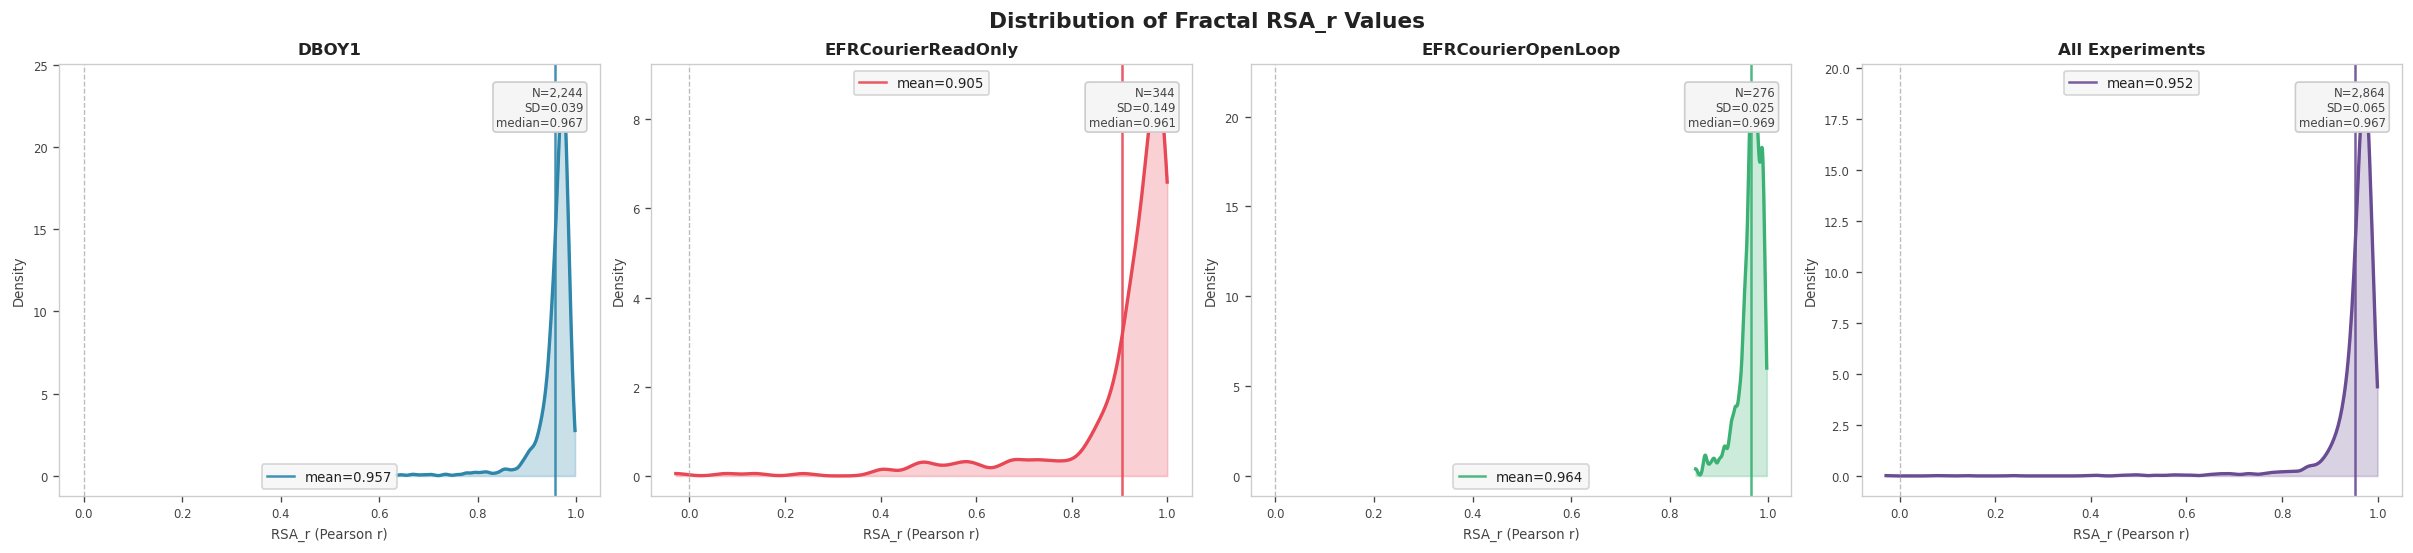


▶ Plot 2: Pairs per trial


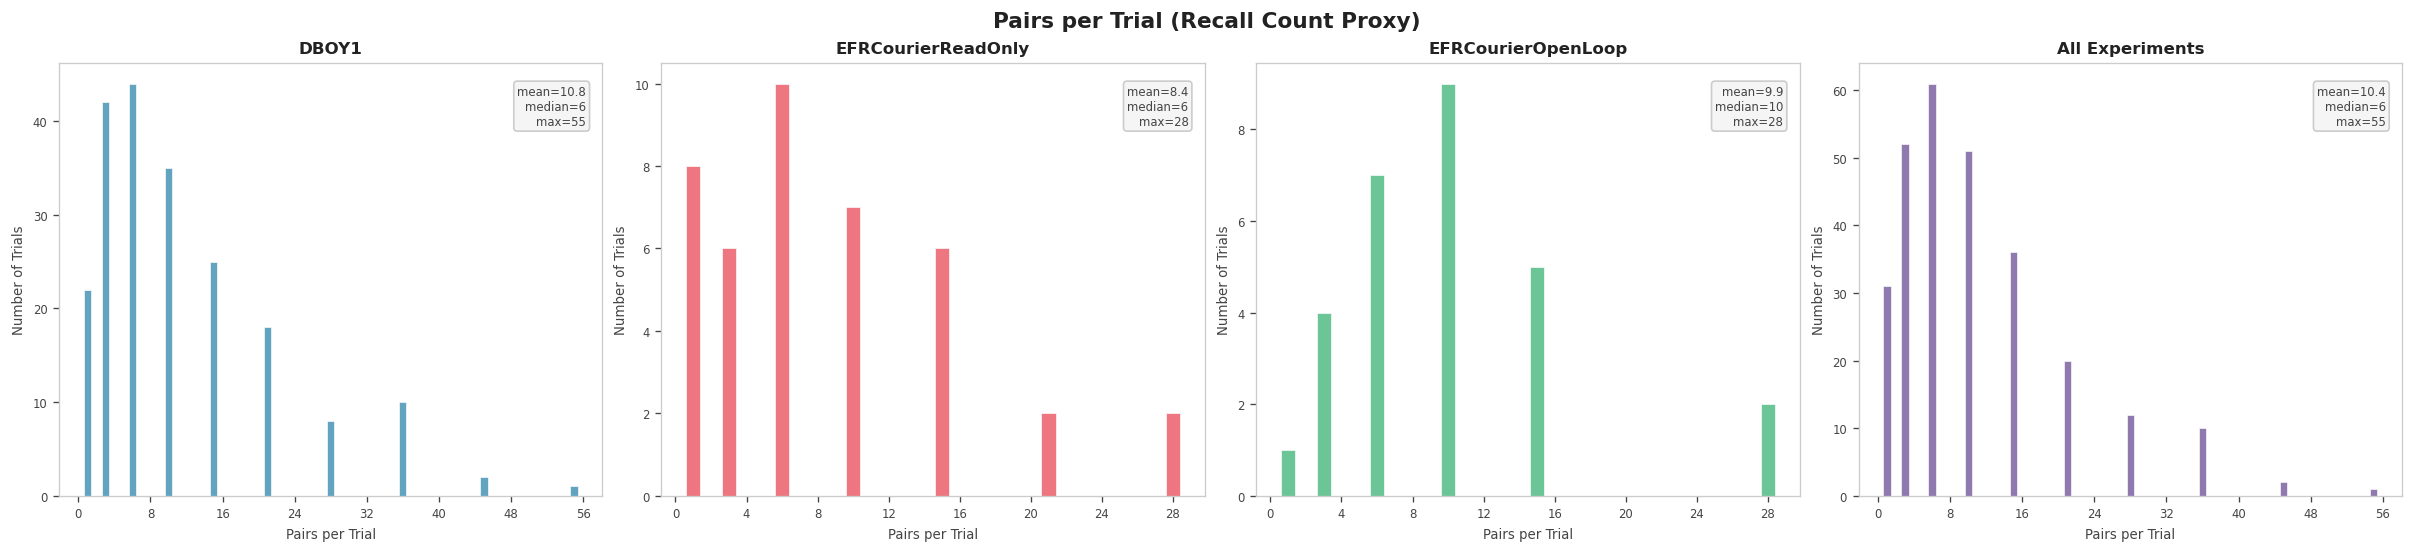


▶ Plot 3: Predictor distributions


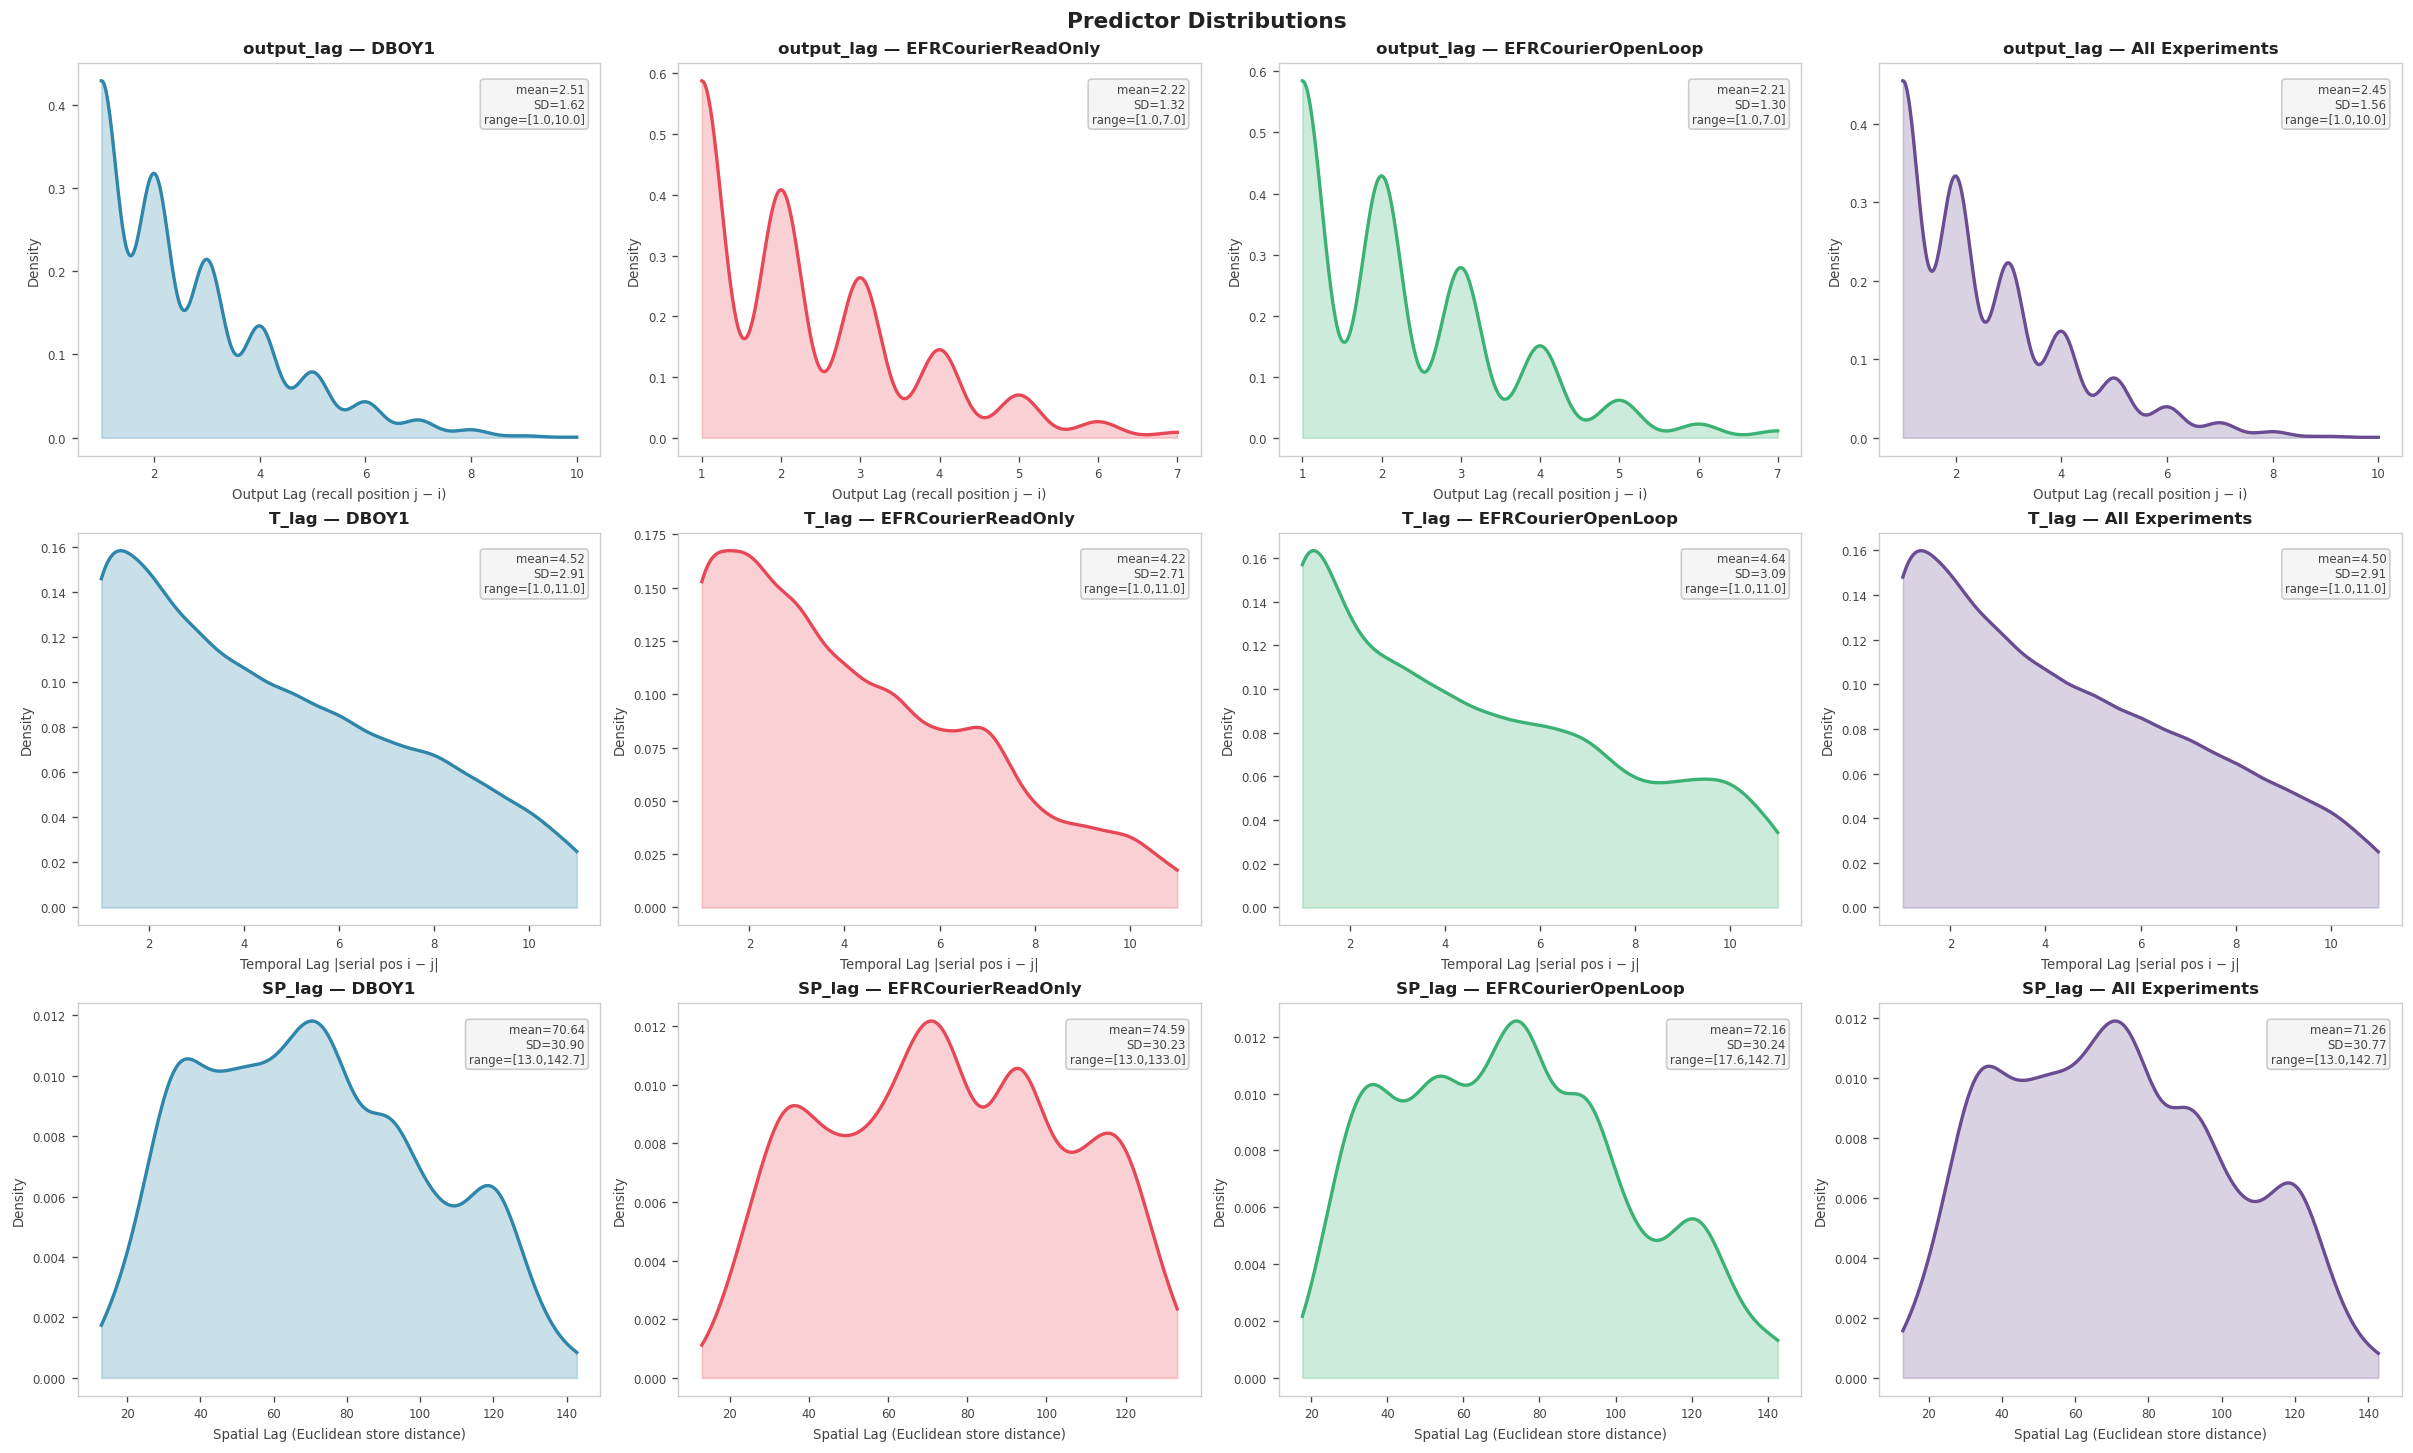


▶ Plot 4: RSA_r vs predictors (binned mean ± SEM + LOWESS)


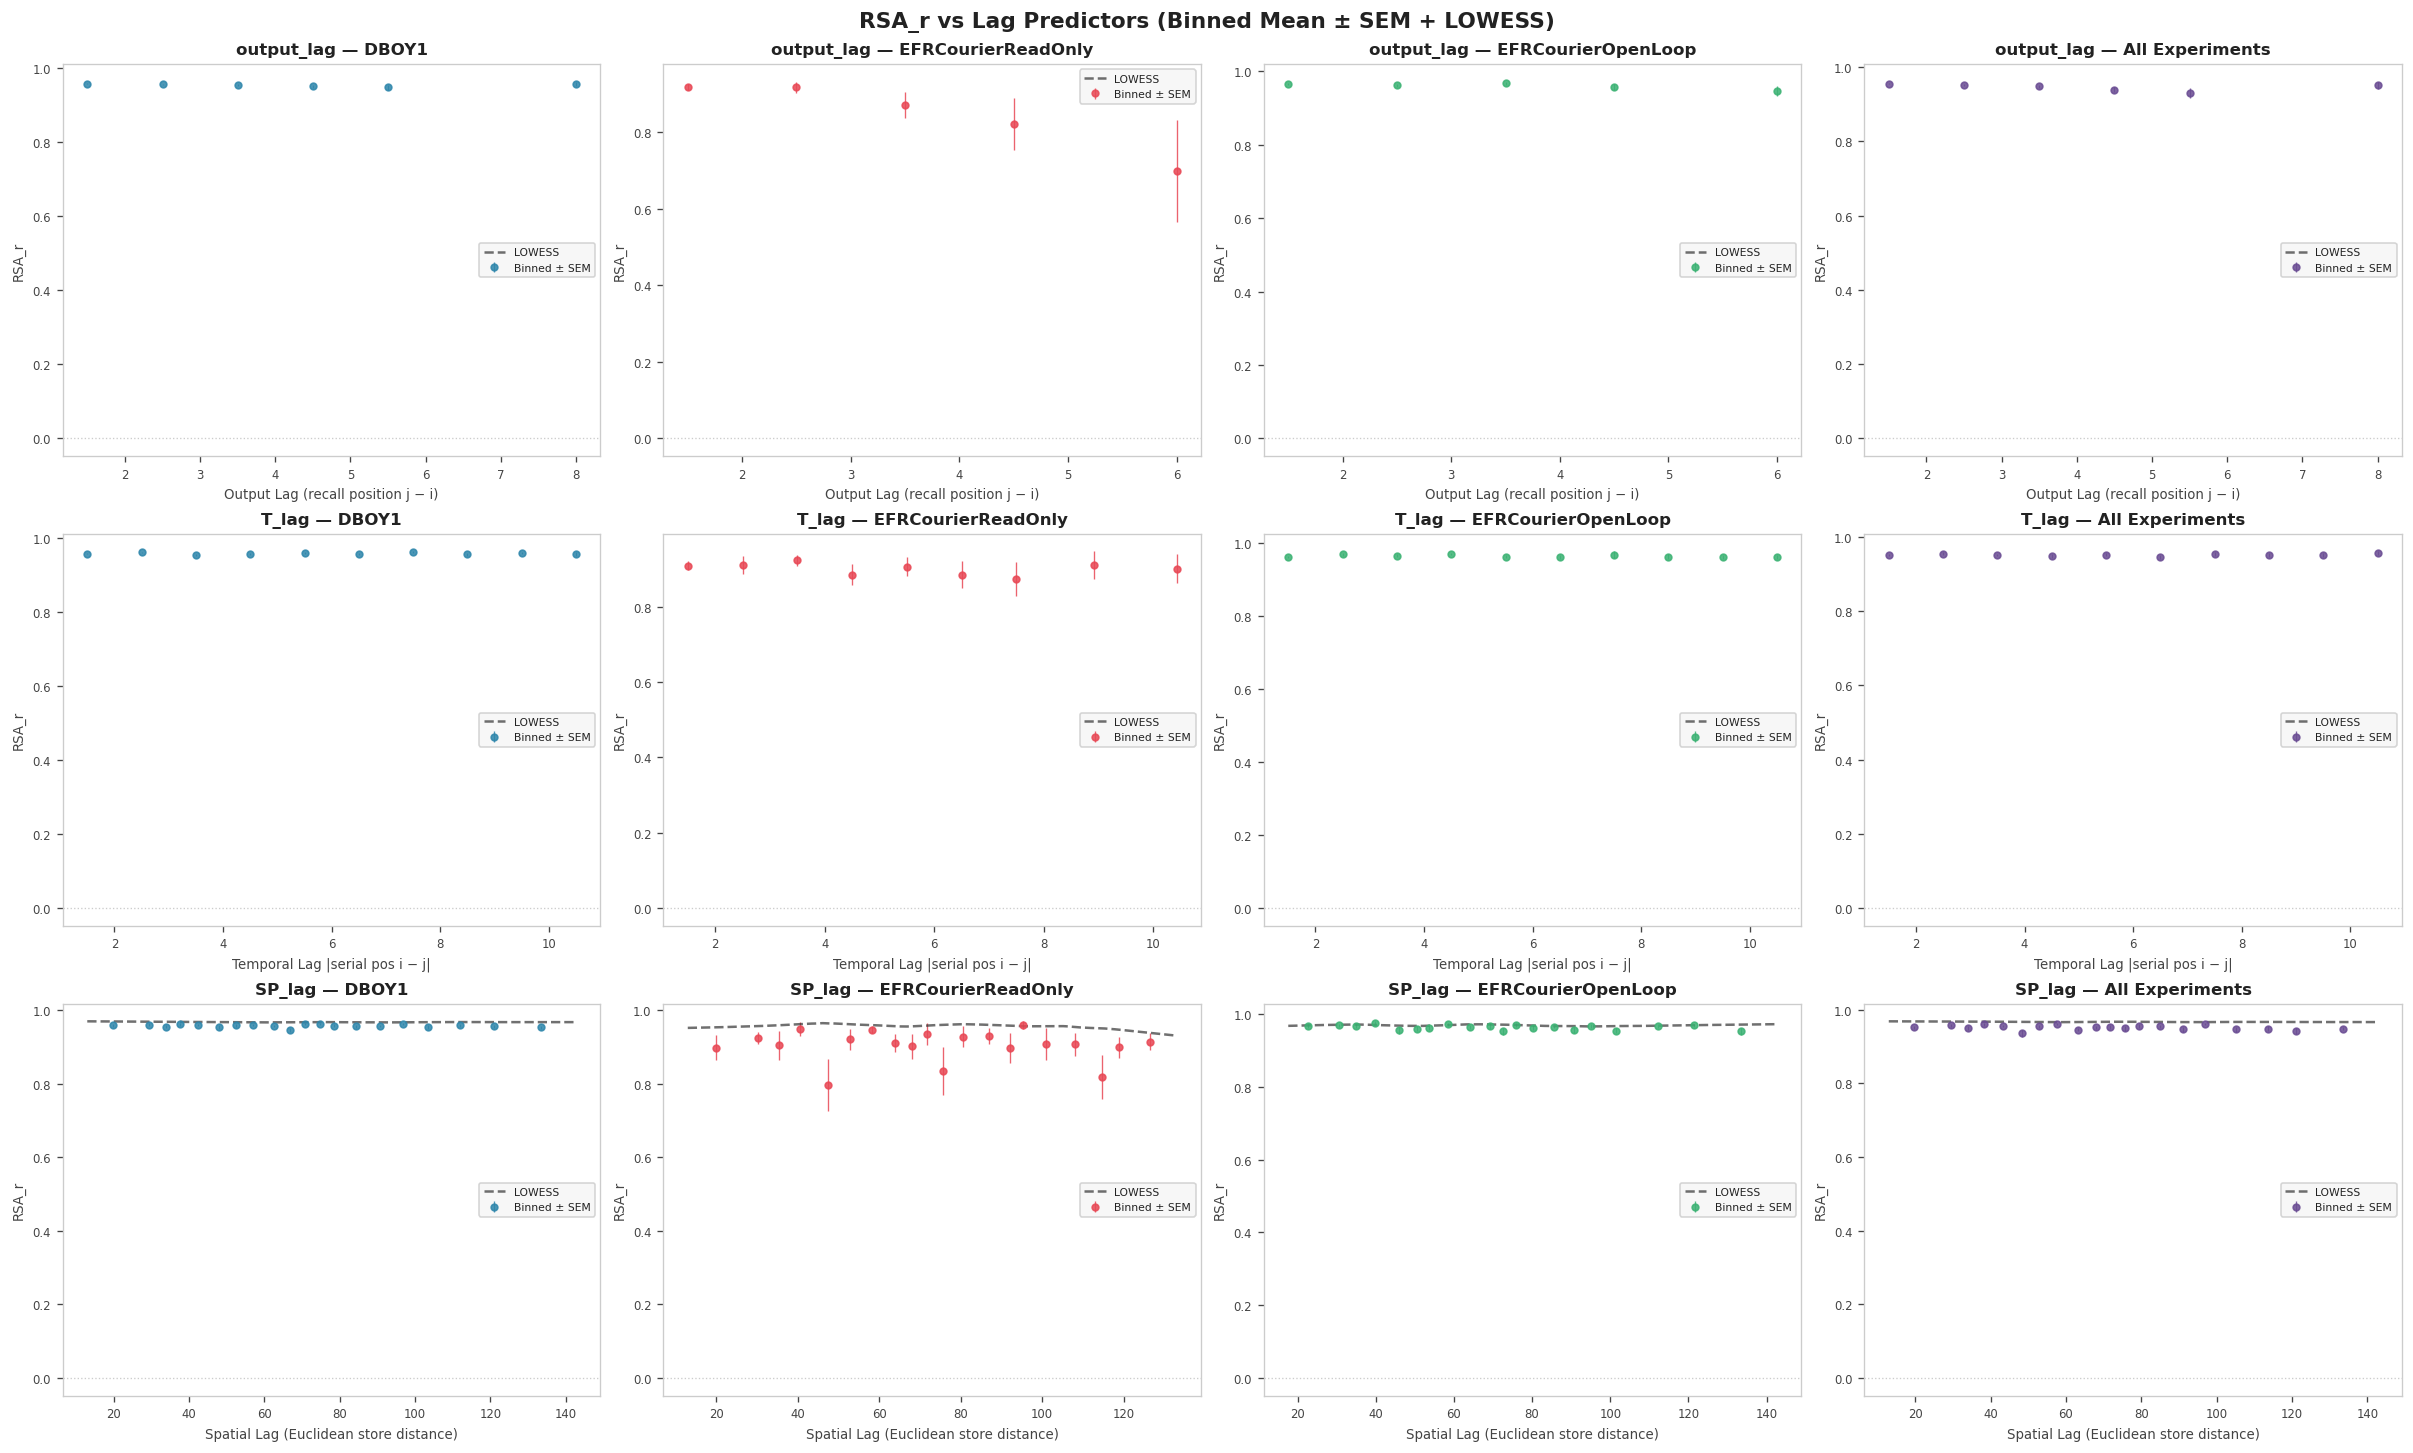


✓ All diagnostic plots complete.


In [11]:
#!/usr/bin/env python3
"""
Diagnostic Visualizations for Fractal RSA Lag Data — Notebook Version
----------------------------------------------------------------------
Run in Jupyter — all plots display inline.

Plots:
  1. Distribution of RSA_r values (per experiment + combined)
  2. Pairs per trial distribution
  3. Predictor distributions (T_lag, SP_lag, output_lag)
  4. RSA_r vs each predictor (binned mean ± SEM + LOWESS)

Input  : ./rsa_lag_results_fractal/ALL_SUBJECTS_{exp}_rsa_lag_fractal.csv
"""

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import MaxNLocator
from scipy.stats import gaussian_kde
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---- make plots show inline in Jupyter ----
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

EXPERIMENTS = ['DBOY1', 'EFRCourierReadOnly', 'EFRCourierOpenLoop']
INPUT_DIR   = Path('./rsa_lag_results_fractal')

COLORS = {
    'DBOY1':               '#2E86AB',
    'EFRCourierReadOnly':  '#E84855',
    'EFRCourierOpenLoop':  '#3BB273',
    'combined':            '#6A4C93',
}

PREDICTORS  = ['output_lag', 'T_lag', 'SP_lag']
PRED_LABELS = {
    'output_lag': 'Output Lag (recall position j − i)',
    'T_lag':      'Temporal Lag |serial pos i − j|',
    'SP_lag':     'Spatial Lag (Euclidean store distance)',
}

# ============================================================================
# LOAD DATA
# ============================================================================

dfs = []
for exp in EXPERIMENTS:
    fpath = INPUT_DIR / f"ALL_SUBJECTS_{exp}_rsa_lag_fractal.csv"
    if not fpath.exists():
        print(f"✗ Not found: {fpath}")
        continue
    df = pd.read_csv(fpath)
    df['experiment'] = exp
    dfs.append(df)
    print(f"✓ Loaded {exp}: {len(df):,} pairs | {df['subject'].nunique()} subjects")

df_all = pd.concat(dfs, ignore_index=True)
present_exps = [e for e in EXPERIMENTS if e in df_all['experiment'].unique()]
print(f"\nTotal rows: {len(df_all):,}")

# ============================================================================
# SUMMARY STATS (printed)
# ============================================================================

print("\n" + "="*65)
print("DIAGNOSTIC SUMMARY STATISTICS")
print("="*65)

for exp in present_exps + ['ALL']:
    sub = df_all if exp == 'ALL' else df_all[df_all['experiment'] == exp]
    if sub.empty:
        continue
    print(f"\n--- {exp} ---")
    print(f"  Total pairs  : {len(sub):,}")
    print(f"  Subjects     : {sub['subject'].nunique()}")
    print(f"  Sessions     : {sub['session'].nunique()}")

    pairs_per_trial = sub.groupby(['subject', 'session', 'trial']).size()
    print(f"  Pairs/trial  : mean={pairs_per_trial.mean():.1f}  "
          f"median={pairs_per_trial.median():.0f}  "
          f"max={pairs_per_trial.max():.0f}")

    rsa = sub['RSA_r'].dropna()
    print(f"  RSA_r        : mean={rsa.mean():.4f}  SD={rsa.std():.4f}  "
          f"median={rsa.median():.4f}  NaN%={sub['RSA_r'].isna().mean()*100:.1f}%")

    for pred in PREDICTORS:
        col = sub[pred].dropna()
        print(f"  {pred:<12}: mean={col.mean():.2f}  SD={col.std():.2f}  "
              f"range=[{col.min():.1f}, {col.max():.1f}]")

print("\n" + "="*65)

# ============================================================================
# HELPER — shared axis styling
# ============================================================================

def style_ax(ax, title, xlabel, ylabel):
    ax.set_facecolor('white')
    ax.set_title(title, color='#222222', fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel(xlabel, color='#444444', fontsize=8)
    ax.set_ylabel(ylabel, color='#444444', fontsize=8)
    ax.tick_params(colors='#444444', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')

def annotate(ax, text):
    ax.text(0.97, 0.95, text, transform=ax.transAxes,
            ha='right', va='top', color='#444444', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#F5F5F5', edgecolor='#CCCCCC'))

# ============================================================================
# PLOT 1 — RSA_r distribution
# ============================================================================

print("\n▶ Plot 1: RSA_r distribution")

n_cols = len(present_exps) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4.5),
                         constrained_layout=True)
fig.patch.set_facecolor('white')

plot_data = [(exp, df_all[df_all['experiment'] == exp]['RSA_r'], COLORS[exp])
             for exp in present_exps]
plot_data.append(('All Experiments', df_all['RSA_r'], COLORS['combined']))

for ax, (title, data, color) in zip(axes, plot_data):
    data = data.dropna()
    style_ax(ax, title, 'RSA_r (Pearson r)', 'Density')
    if len(data) > 1:
        kde_x = np.linspace(data.min(), data.max(), 500)
        kde   = gaussian_kde(data, bw_method=0.15)
        ax.fill_between(kde_x, kde(kde_x), alpha=0.25, color=color)
        ax.plot(kde_x, kde(kde_x), color=color, lw=2)
    ax.axvline(0, color='#AAAAAA', lw=0.8, ls='--', alpha=0.8)
    ax.axvline(data.mean(), color=color, lw=1.5, alpha=0.9,
               label=f'mean={data.mean():.3f}')
    ax.legend(fontsize=8, labelcolor='#222222',
              facecolor='#F5F5F5', edgecolor='#CCCCCC')
    annotate(ax, f'N={len(data):,}\nSD={data.std():.3f}\nmedian={data.median():.3f}')

fig.suptitle('Distribution of Fractal RSA_r Values',
             color='#222222', fontsize=13, fontweight='bold')
plt.show()

# ============================================================================
# PLOT 2 — Pairs per trial
# ============================================================================

print("\n▶ Plot 2: Pairs per trial")

fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4.5),
                         constrained_layout=True)
fig.patch.set_facecolor('white')

pair_data = [(exp, df_all[df_all['experiment'] == exp]
              .groupby(['subject', 'session', 'trial']).size(), COLORS[exp])
             for exp in present_exps]
pair_data.append(('All Experiments',
                  df_all.groupby(['subject', 'session', 'trial', 'experiment']).size(),
                  COLORS['combined']))

for ax, (title, counts, color) in zip(axes, pair_data):
    style_ax(ax, title, 'Pairs per Trial', 'Number of Trials')
    vc = counts.value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=color, alpha=0.75,
           edgecolor='white', linewidth=0.5)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    annotate(ax, f'mean={counts.mean():.1f}\nmedian={counts.median():.0f}\nmax={counts.max():.0f}')

fig.suptitle('Pairs per Trial (Recall Count Proxy)',
             color='#222222', fontsize=13, fontweight='bold')
plt.show()

# ============================================================================
# PLOT 3 — Predictor distributions
# ============================================================================

print("\n▶ Plot 3: Predictor distributions")

fig, axes = plt.subplots(len(PREDICTORS), n_cols,
                         figsize=(5 * n_cols, 4 * len(PREDICTORS)),
                         constrained_layout=True)
fig.patch.set_facecolor('white')

for row, pred in enumerate(PREDICTORS):
    cols_data = [(exp, df_all[df_all['experiment'] == exp][pred], COLORS[exp])
                 for exp in present_exps]
    cols_data.append(('All Experiments', df_all[pred], COLORS['combined']))

    for col, (title, data, color) in enumerate(cols_data):
        ax = axes[row, col]
        data = data.dropna()
        style_ax(ax, f'{pred} — {title}', PRED_LABELS[pred], 'Density')
        if len(data) > 1:
            kde_x = np.linspace(data.min(), data.max(), 500)
            kde   = gaussian_kde(data, bw_method=0.2)
            ax.fill_between(kde_x, kde(kde_x), alpha=0.25, color=color)
            ax.plot(kde_x, kde(kde_x), color=color, lw=2)
        annotate(ax, f'mean={data.mean():.2f}\nSD={data.std():.2f}\n'
                     f'range=[{data.min():.1f},{data.max():.1f}]')

fig.suptitle('Predictor Distributions',
             color='#222222', fontsize=13, fontweight='bold')
plt.show()

# ============================================================================
# PLOT 4 — RSA_r vs each predictor
# ============================================================================

print("\n▶ Plot 4: RSA_r vs predictors (binned mean ± SEM + LOWESS)")

fig, axes = plt.subplots(len(PREDICTORS), n_cols,
                         figsize=(5 * n_cols, 4 * len(PREDICTORS)),
                         constrained_layout=True)
fig.patch.set_facecolor('white')

for row, pred in enumerate(PREDICTORS):
    cols_data = [(exp, df_all[df_all['experiment'] == exp], COLORS[exp])
                 for exp in present_exps]
    cols_data.append(('All Experiments', df_all, COLORS['combined']))

    for col, (title, sub, color) in enumerate(cols_data):
        ax = axes[row, col]
        style_ax(ax, f'{pred} — {title}', PRED_LABELS[pred], 'RSA_r')
        sub = sub[[pred, 'RSA_r']].dropna()
        if len(sub) < 10:
            ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                    transform=ax.transAxes, color='#AAAAAA')
            continue
        # Binned mean ± SEM
        try:
            sub = sub.copy()
            sub['bin'] = pd.qcut(sub[pred], q=20, duplicates='drop')
            binned = (sub.groupby('bin', observed=True)['RSA_r']
                      .agg(['mean', 'sem']).reset_index())
            centers = binned['bin'].apply(lambda x: x.mid).astype(float)
            ax.errorbar(centers, binned['mean'], yerr=binned['sem'],
                        fmt='o', color=color, ms=4, lw=1.2,
                        elinewidth=0.8, alpha=0.85, label='Binned ± SEM')
        except Exception:
            pass
        # LOWESS
        try:
            sm = lowess(sub['RSA_r'].values, sub[pred].values,
                        frac=0.3, return_sorted=True)
            ax.plot(sm[:, 0], sm[:, 1], color='#333333', lw=1.5,
                    alpha=0.7, ls='--', label='LOWESS')
        except Exception:
            pass
        ax.axhline(0, color='#CCCCCC', lw=0.8, ls=':')
        ax.legend(fontsize=6.5, labelcolor='#222222',
                  facecolor='#F5F5F5', edgecolor='#CCCCCC')

fig.suptitle('RSA_r vs Lag Predictors (Binned Mean ± SEM + LOWESS)',
             color='#222222', fontsize=13, fontweight='bold')
plt.show()

print("\n✓ All diagnostic plots complete.")